# Financial Market Analytics - Dynamic Asset Allocation

**Project name:** Dynamic Asset Allocation with Markowitz, Michaud Resampling, and Black-Litterman

**Course:** Financial Market Analytics

**Academic year:** 2025/2026

**Assignment:** Final Project - Variant B, Flexible Asset Allocation

**Authors:**
- Tommaso Arone, matricola 896282
- Lorenzo Triolo, matricola 895541

**Data provider:** Yahoo Finance through `yfinance`

**Notebook objective:** This notebook builds and evaluates dynamic multi-asset allocation strategies using a broad ETF universe. The workflow starts with data inspection and exploratory analysis, then implements classical Markowitz portfolios, Michaud-style resampled efficiency, naive benchmarks, rolling out-of-sample evaluation, and an optional Black-Litterman extension based on the Hormuz geopolitical stress scenario.


## 1. Setup, Universe, and Data

This section defines the project environment, the ETF universe, and the data download procedure. The chosen universe covers developed and emerging equities, government bonds, credit, commodities, real assets, REITs, and a cash proxy, as required for a flexible multi-asset allocation problem.


This cell imports the scientific Python stack used in the project. The workflow combines data retrieval, numerical linear algebra, constrained optimization, statistical diagnostics, and visualization. In portfolio notation, most models work with a return vector $r_t \in \mathbb{R}^N$, an expected-return estimate $\hat{\mu}$, and a covariance estimate $\hat{\Sigma}$.


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

from scipy.stats import norm


This cell defines the ETF universe and the asset-class descriptions used in tables. A broad multi-asset universe is appropriate because dynamic asset allocation is about allocating risk across heterogeneous sources of return, not only selecting stocks. The universe contains equities, bonds, credit, commodities, real assets, REITs, and a cash proxy.


In [2]:
tickers = [
    # Equity - Developed Markets
    "SPY",   # S&P 500
    "QQQ",   # Nasdaq-100
    "VGK",   # Europe
    "EWJ",   # Japan
    "VPL",   # Asia-Pacific

    # Equity - Emerging Markets
    "EEM",   # MSCI EM
    "VWO",   # FTSE EM

    # Government Bonds
    "SHY",   # 1-3Y Treasury
    "IEF",   # 7-10Y Treasury
    "TLT",   # 20+Y Treasury
    "IGOV",  # Intl Treasury
    "EMB",   # EM Bond USD

    # Credit
    "LQD",   # IG Corporate
    "HYG",   # High Yield
    #"BKLN",  # Senior Loans

    # Commodities & Inflation
    "GLD",   # Gold
    "SLV",   # Silver
    "DBC",   # Broad Commodity
    "XLE",   # Energy Equity
    "TIP",   # TIPS
    "USO",

    # REIT
    "VNQ",   # US REIT
    #"VNQI",  # Global REIT

    # Cash & Alternatives
    "BIL",   # T-Bill (risk-free proxy)
    #"PDBC",  # Optimum Yield Commodity
    #"DBMF",  # Managed Futures
]


etf_universe = {
    "SPY": "S&P 500", "QQQ": "Nasdaq-100", "VGK": "Europe", "EWJ": "Japan", "VPL": "Asia-Pacific",
    "EEM": "MSCI Emerging Markets", "VWO": "FTSE Emerging Markets",
    "SHY": "1-3Y U.S. Treasury", "IEF": "7-10Y U.S. Treasury", "TLT": "20+Y U.S. Treasury",
    "IGOV": "International Treasury", "EMB": "Emerging Market Bonds",
    "LQD": "Investment Grade Corporate Bonds", "HYG": "High Yield Corporate Bonds",
    "GLD": "Gold", "SLV": "Silver", "DBC": "Broad Commodities", "XLE": "Energy Equity",
    "TIP": "Treasury Inflation-Protected Securities", "USO": "Oil", "VNQ": "U.S. REIT", "BIL": "T-Bill / Cash Proxy",
}

# Keep the list aligned with the description dictionary used in the EDA tables.
tickers = list(etf_universe.keys())


This cell downloads adjusted close prices and creates the first monthly objects. Daily prices are retained as `prices_daily` for rolling-correlation diagnostics, while monthly prices are used for portfolio optimization. Monthly log returns are later computed as

$$r_{t,i}=\log\left(\frac{P_{t,i}}{P_{t-1,i}}\right),$$

which makes cumulative performance additive in log space and is standard for historical return modelling.


In [3]:
prices = yf.download(tickers, start="2010-01-01", auto_adjust=True)["Close"]
print(prices.isna().sum())
prices = prices.dropna(how="all")  # drop dates without observations
prices_daily = prices.copy()
monthly_prices = prices.resample('ME').last()
monthly_returns = monthly_prices.pct_change().dropna()


[*********************100%***********************]  22 of 22 completed


Ticker
BIL     0
DBC     0
EEM     0
EMB     0
EWJ     0
GLD     0
HYG     0
IEF     0
IGOV    0
LQD     0
QQQ     0
SHY     0
SLV     0
SPY     0
TIP     0
TLT     0
USO     0
VGK     0
VNQ     0
VPL     0
VWO     0
XLE     0
dtype: int64


This cell plots normalized daily prices by asset class so that long-run cross-asset performance can be compared on a common base.


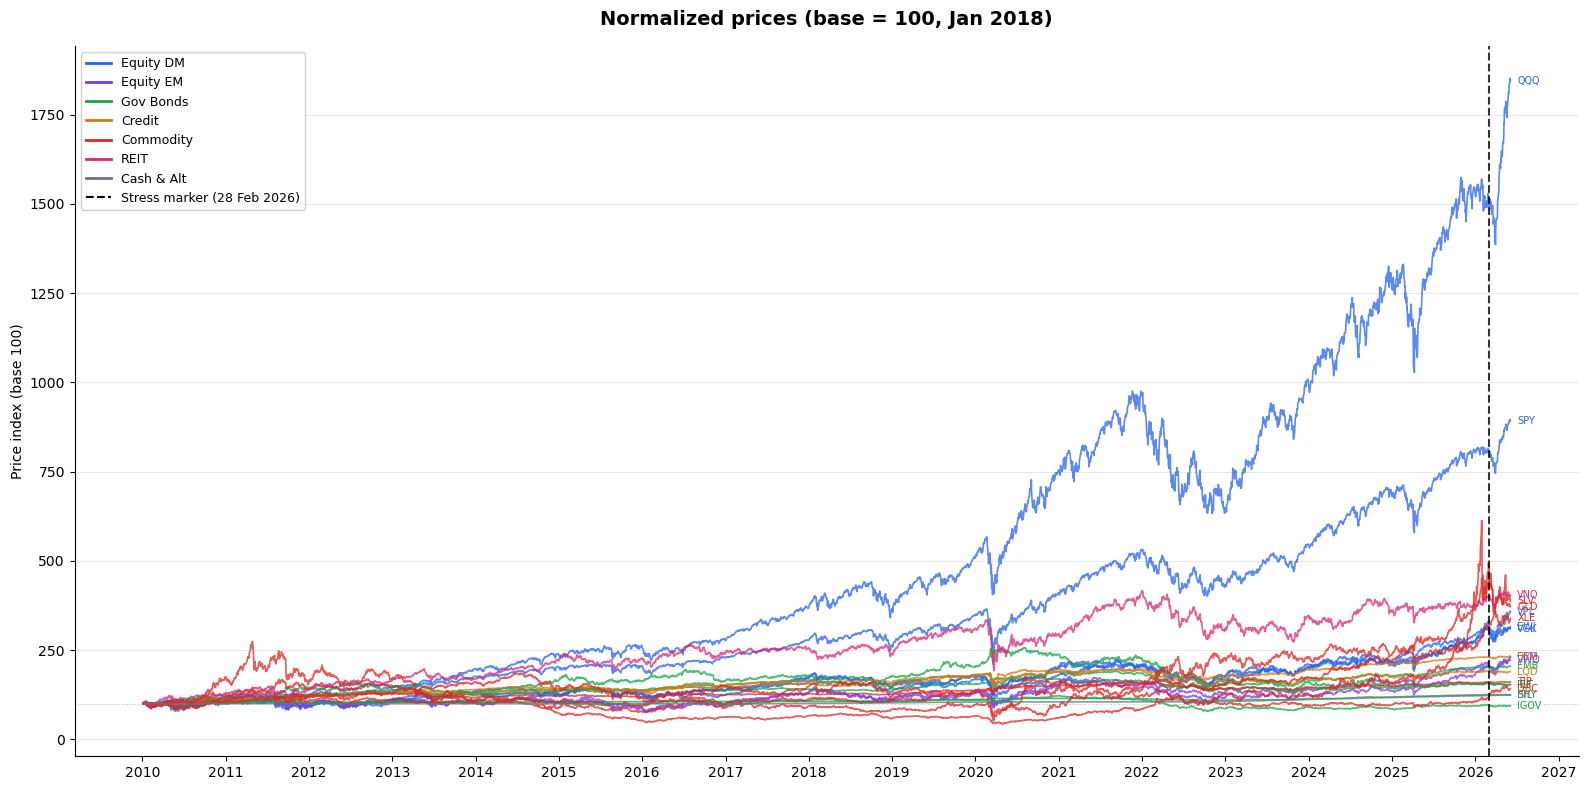

In [4]:
normalized = prices / prices.bfill().iloc[0] * 100

groups = {
    "Equity DM":   (["SPY", "QQQ", "VGK", "EWJ", "VPL"], "#2563EB"),
    "Equity EM":   (["EEM", "VWO"],                        "#7C3AED"),
    "Gov Bonds":   (["SHY", "IEF", "TLT", "IGOV", "EMB"], "#16A34A"),
    "Credit":      (["LQD", "HYG", "BKLN"],                "#D97706"),
    "Commodity":   (["GLD", "SLV", "DBC", "XLE", "TIP"],  "#DC2626"),
    "REIT":        (["VNQ", "VNQI"],                        "#DB2777"),
    "Cash & Alt":  (["BIL", "PDBC", "DBMF"],               "#6B7280"),
}

fig, ax = plt.subplots(figsize=(16, 8))

for group_name, (group_tickers, color) in groups.items():
    for i, ticker in enumerate(group_tickers):
        if ticker not in normalized.columns:
            continue
        ax.plot(
            normalized.index,
            normalized[ticker],
            color=color,
            linewidth=1.2,
            alpha=0.75,
            label=f"{ticker}" if i == 0 else "_nolegend_",  # only the first asset is shown in the color legend
        )
        last_val = normalized[ticker].dropna().iloc[-1]
        ax.annotate(
            ticker,
            xy=(normalized[ticker].dropna().index[-1], last_val),
            xytext=(5, 0),
            textcoords="offset points",
            fontsize=7,
            color=color,
            va="center",
        )

ax.axvline(
    x=np.datetime64("2026-02-28"),
    color="black",
    linewidth=1.5,
    linestyle="--",
    alpha=0.8,
    label="Stress marker (28 Feb 2026)",
)
ax.axhline(y=100, color="gray", linewidth=0.7, linestyle=":", alpha=0.5)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color=color, linewidth=2, label=name)
    for name, (_, color) in groups.items()
]
legend_handles.append(
    Line2D([0], [0], color="black", linewidth=1.5, linestyle="--", label="Stress marker (28 Feb 2026)")
)
ax.legend(handles=legend_handles, loc="upper left", fontsize=9, framealpha=0.9)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set_title("Normalized prices (base = 100, Jan 2018)", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Price index (base 100)")
ax.set_xlabel("")
ax.grid(axis="y", linewidth=0.5, alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


This cell initializes the equal-weight benchmark. The $1/N$ portfolio assigns the same weight to every asset,

$$w_i=\frac{1}{N}, \quad i=1,\ldots,N.$$

It is a useful naive benchmark because it does not rely on noisy expected-return or covariance estimates. If an optimized portfolio cannot beat or improve on this benchmark after accounting for risk and turnover, the optimization is not clearly adding value.


In [5]:
n = len(tickers)
w_ew = np.ones(n) / n  # 4% each


This cell defines the strategic 60/40 benchmark. The benchmark allocates 60% to equity ETFs and 40% to bond ETFs, split equally inside each bucket. It represents a simple policy portfolio with fixed asset-class budgets:

$$\sum_{i \in Equity} w_i = 0.60, \qquad \sum_{i \in Bonds} w_i = 0.40.$$

It is rebalanced using the same monthly frequency as the active strategies so that comparisons are consistent.


In [6]:

equity_tickers = ["SPY", "QQQ", "VGK", "EWJ", "VPL", "EEM", "VWO"]
bond_tickers   = ["SHY", "IEF", "TLT", "IGOV", "EMB", "LQD"]

w_6040 = {}
for t in equity_tickers:
    w_6040[t] = 0.60 / len(equity_tickers)
for t in bond_tickers:
    w_6040[t] = 0.40 / len(bond_tickers)
# all remaining assets receive zero benchmark weight


## 2. Exploratory Data Analysis

The EDA section inspects performance, correlations, drawdowns, volatility, tail behaviour, and unconditional risk-return characteristics before any optimizer is used. This step documents the data and highlights why dynamic allocation can be difficult during stress regimes.


This cell computes monthly log returns and plots cumulative performance. The cumulative wealth index is based on

$$W_t = W_0 \exp\left(\sum_{s=1}^{t} r_s\right),$$

so every line can be read as the value of one monetary unit invested in the asset. This first visualization helps identify dominant trends, defensive assets, and stress-period behavior before optimization is introduced.


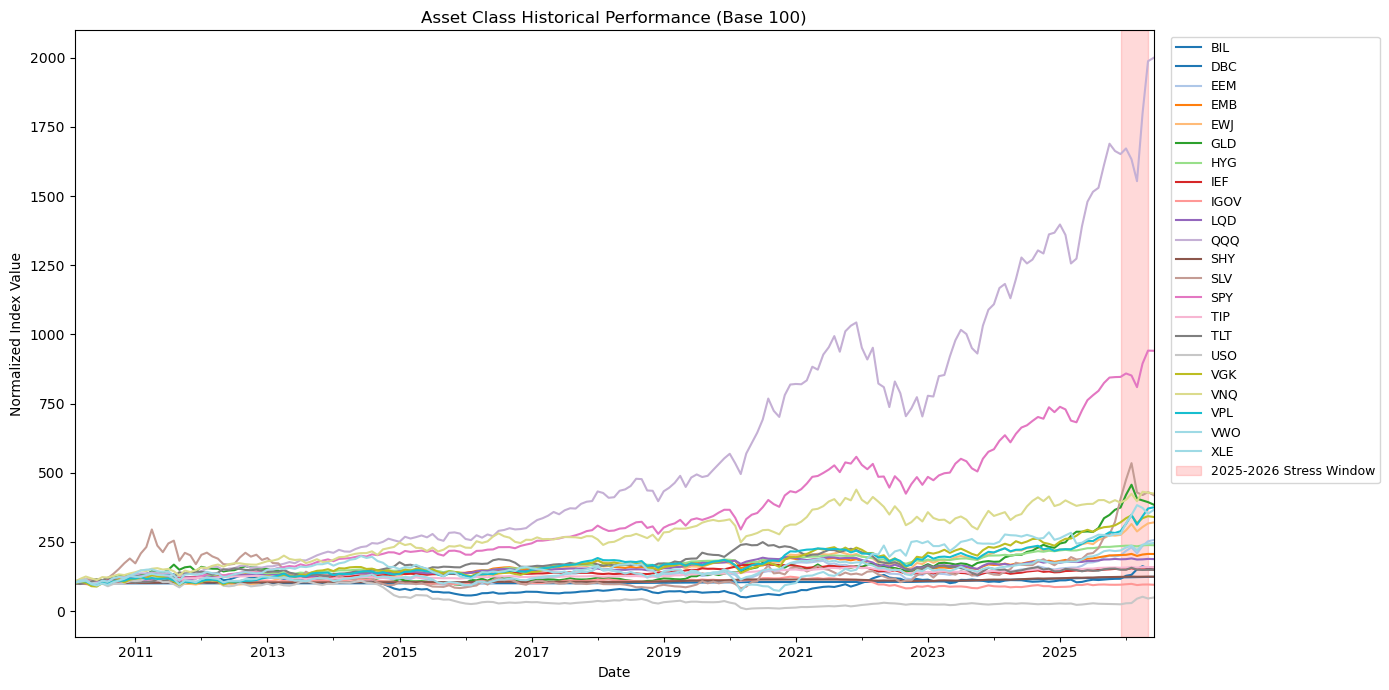

In [7]:
monthly_prices = prices.resample('ME').last()
log_returns = np.log(monthly_prices / monthly_prices.shift(1)).dropna()
# Plot 1: Normalized Historical Performance
plt.figure(figsize=(14, 7))
p_norm = (np.exp(log_returns.cumsum()) * 100)
p_norm.plot(colormap='tab20', linewidth=1.5, ax=plt.gca())

plt.axvspan('2025-12-31', '2026-05-31', color='red', alpha=0.15, label='2025-2026 Stress Window')

plt.title('Asset Class Historical Performance (Base 100)')
plt.ylabel('Normalized Index Value')
plt.xlabel("Date")
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
plt.tight_layout()
plt.show()


This cell estimates the full-sample correlation matrix. Pearson correlation is defined as

$$\rho_{ij}=\frac{\operatorname{Cov}(r_i,r_j)}{\sigma_i\sigma_j}.$$

In Markowitz theory, diversification is valuable when assets are not perfectly positively correlated. A correlation matrix therefore gives a first view of whether the universe can reduce portfolio variance through cross-asset allocation.


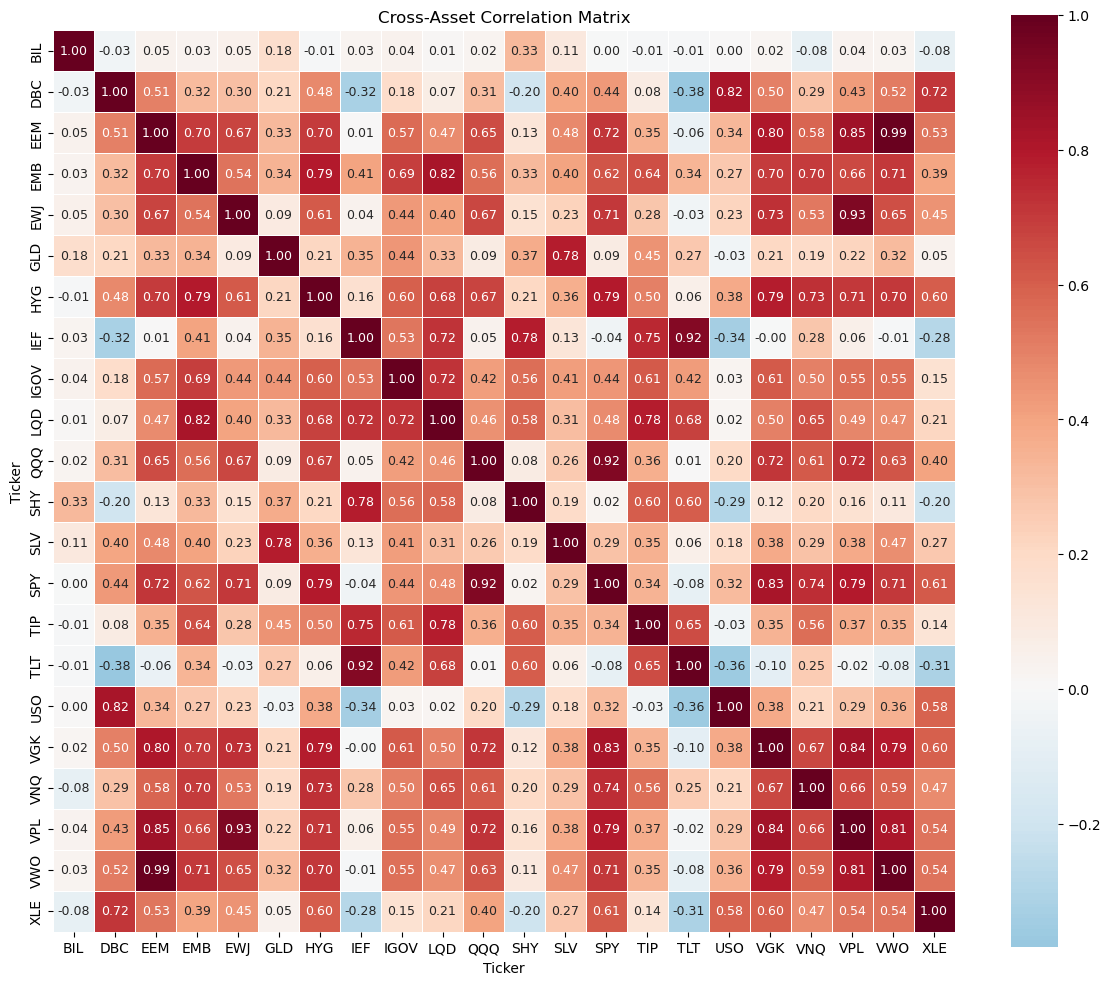

In [8]:
# Plot 2: Correlation Matrix Heatmap
plt.figure(figsize=(12, 10))

# Calculate the correlation matrix of the log returns
corr_matrix = log_returns.corr()

# Use Seaborn to plot the heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, annot_kws={"size": 9}, linewidths=.5)

plt.title('Cross-Asset Correlation Matrix')
plt.tight_layout()
plt.show()


This cell isolates a recent stress window and compares its average correlation with the historical average. Stress regimes matter because correlations often increase when risky assets sell off together. The comparison summarizes contagion by measuring the change in average pairwise correlation:

$$\Delta \bar{\rho}=\bar{\rho}_{stress}-\bar{\rho}_{full\ sample}.$$


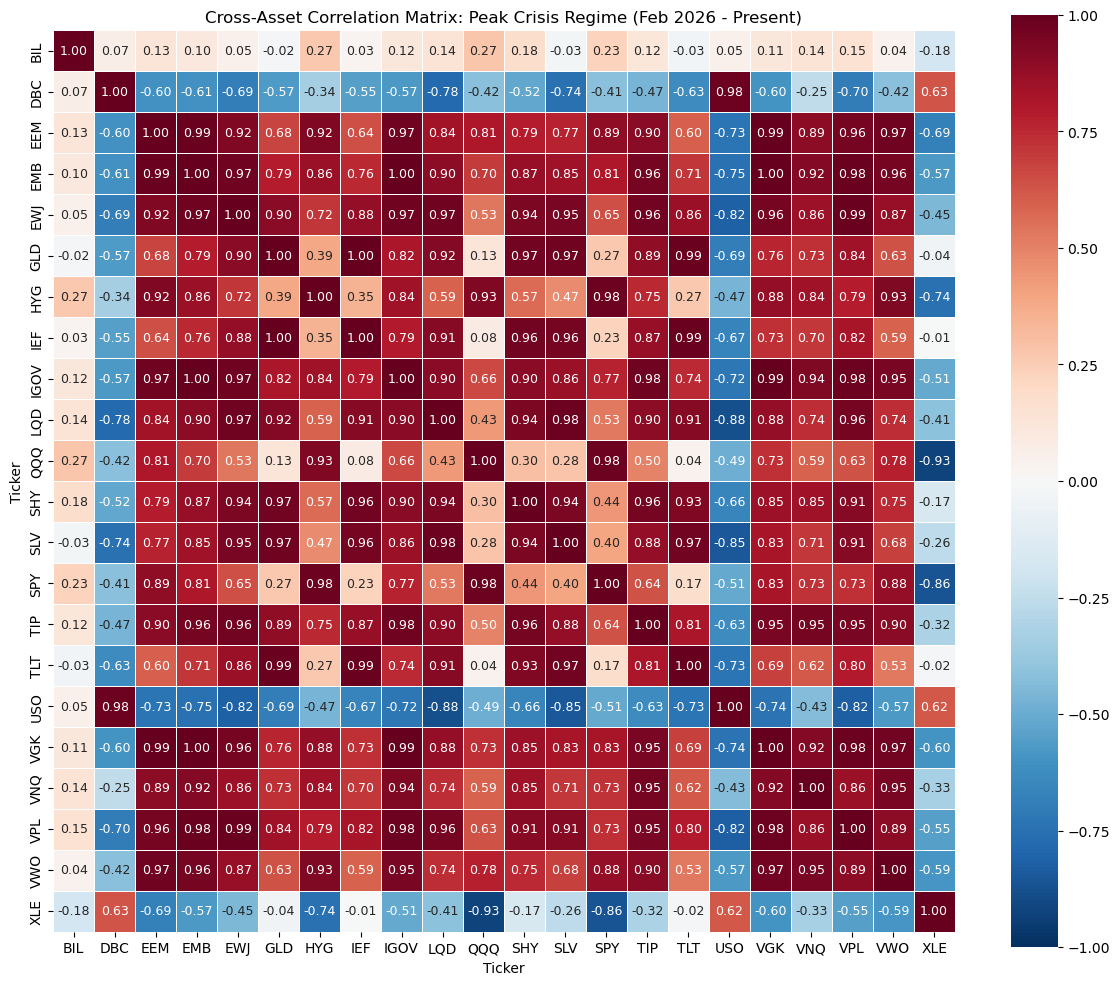

>>> Average Historical Cross-Asset Correlation: 0.336
>>> Average Crisis-Regime Cross-Asset Correlation: 0.378
>>> Correlation Jump (Contagion): 0.042


In [9]:
# Define the start date of the severe crisis period
crisis_start_date = '2026-02-01'

# Slice the log returns dataframe to isolate the war period
crisis_returns = log_returns.loc[crisis_start_date:]

# Calculate the correlation matrix specifically for the crisis regime
crisis_corr_matrix = crisis_returns.corr()

# Plot 2b: Crisis Period Correlation Matrix Heatmap
plt.figure(figsize=(12, 10))

# Use a consistent color map and scale (vmin=-1, vmax=1) to allow direct comparison with the previous heatmap
sns.heatmap(crisis_corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            vmin=-1, vmax=1, square=True, annot_kws={"size": 9}, linewidths=.5)

plt.title('Cross-Asset Correlation Matrix: Peak Crisis Regime (Feb 2026 - Present)')
plt.tight_layout()
plt.show()

# Optional analytical step: Calculate the average correlation jump
# We extract the upper triangle of the matrices to avoid duplicating values and the diagonal (1.0s)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
hist_avg_corr = corr_matrix.where(mask).mean().mean()
crisis_avg_corr = crisis_corr_matrix.where(mask).mean().mean()

print(f">>> Average Historical Cross-Asset Correlation: {hist_avg_corr:.3f}")
print(f">>> Average Crisis-Regime Cross-Asset Correlation: {crisis_avg_corr:.3f}")
print(f">>> Correlation Jump (Contagion): {(crisis_avg_corr - hist_avg_corr):.3f}")


This cell computes the main unconditional risk statistics used by the later models. Annualized expected return and volatility are estimated from monthly log returns as

$$\hat{\mu}_i = 12\bar{r}_i, \qquad \hat{\sigma}_i = \sqrt{12}\,s_i.$$

The Sharpe ratio uses BIL as a cash/risk-free proxy,

$$SR_i=\frac{\hat{\mu}_i-r_f}{\hat{\sigma}_i},$$

and maximum drawdown is computed from the cumulative wealth path as the largest peak-to-trough loss.


In [10]:
prices_monthly = prices_daily.resample('ME').last()
log_returns_monthly = np.log(prices_monthly / prices_monthly.shift(1)).dropna(how="all")

# Annualized metrics
ann_returns = log_returns_monthly.mean() * 12
ann_volatility = log_returns_monthly.std() * np.sqrt(12)

# Sharpe Ratio using BIL as the risk-free proxy
risk_free_rate = ann_returns['BIL']
sharpe_ratio = (ann_returns - risk_free_rate) / ann_volatility

# Maximum Drawdown
cumulative_returns = np.exp(log_returns_monthly.cumsum())
running_max = cumulative_returns.cummax()
drawdowns = (cumulative_returns / running_max) - 1
max_drawdown = drawdowns.min()

# Summary DataFrame
eda_metrics = pd.DataFrame({
    'Asset Class': pd.Series(etf_universe),
    'Annual Return': ann_returns,
    'Annual Volatility': ann_volatility,
    'Sharpe Ratio': sharpe_ratio,
    'Max Drawdown': max_drawdown
})

display(eda_metrics.round(4).sort_values(by='Sharpe Ratio', ascending=False))


,Asset Class,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown
QQQ,Nasdaq-100,0.1825,0.1736,0.9764,-0.3258
SPY,S&P 500,0.1365,0.1438,0.8596,-0.2393
HYG,High Yield Corporate Bonds,0.0528,0.0749,0.5321,-0.1525
VPL,Asia-Pacific,0.0805,0.1520,0.4442,-0.2815
VNQ,U.S. REIT,0.0881,0.1729,0.4347,-0.3275
GLD,Gold,0.0821,0.1608,0.4299,-0.4291
EWJ,Japan,0.0709,0.1428,0.4057,-0.2886
VGK,Europe,0.0746,0.1755,0.3511,-0.3096
LQD,Investment Grade Corporate Bonds,0.0384,0.0727,0.3498,-0.2326
EMB,Emerging Market Bonds,0.0441,0.0925,0.3364,-0.2674


This cell visualizes the monthly correlation matrix used by the optimization models. Since the covariance matrix can be decomposed as

$$\Sigma = D_\sigma R D_\sigma,$$

where $R$ is the correlation matrix and $D_\sigma$ is the diagonal matrix of volatilities, this chart also helps interpret the risk structure that enters Markowitz and Michaud optimization.


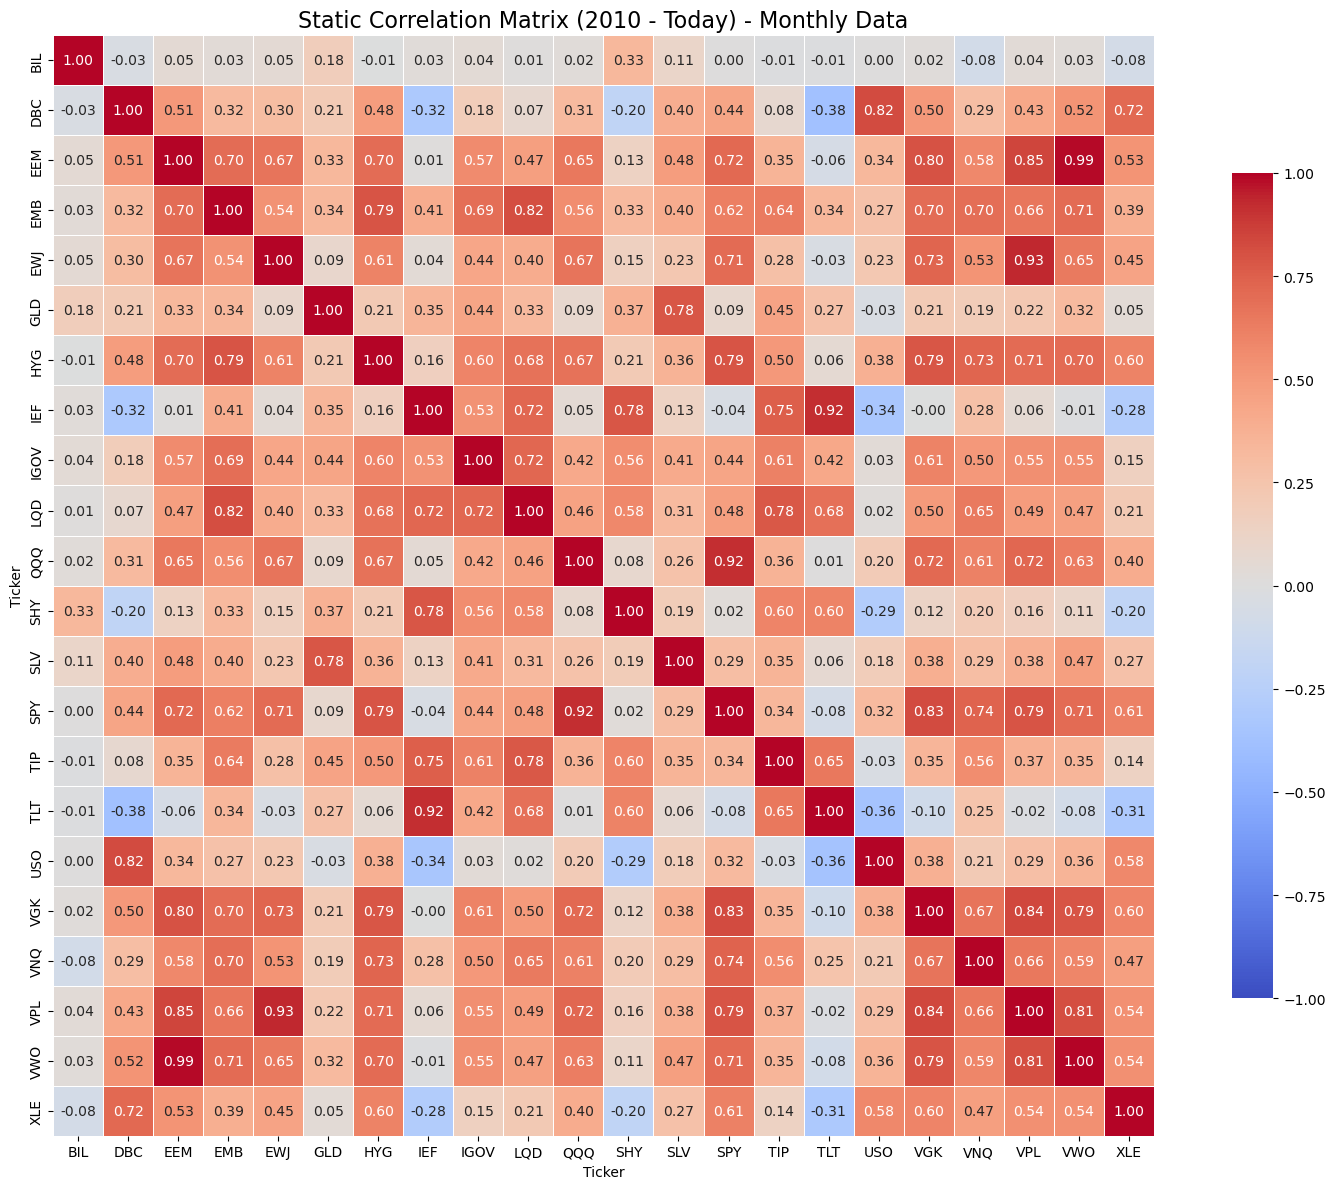

In [11]:
corr_matrix_monthly = log_returns_monthly.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix_monthly, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    square=True, 
    linewidths=.5,
    cbar_kws={"shrink": .75}
)
plt.title("Static Correlation Matrix (2010 - Today) - Monthly Data", fontsize=16)
plt.tight_layout()
plt.show()


This cell computes rolling daily correlations. A rolling correlation updates $\rho_{ij}$ over a moving window of recent observations, allowing us to see whether relationships such as SPY--TLT or SPY--GLD change during stress episodes. This is an empirical check against the static-correlation assumption implicit in simple mean-variance optimization.


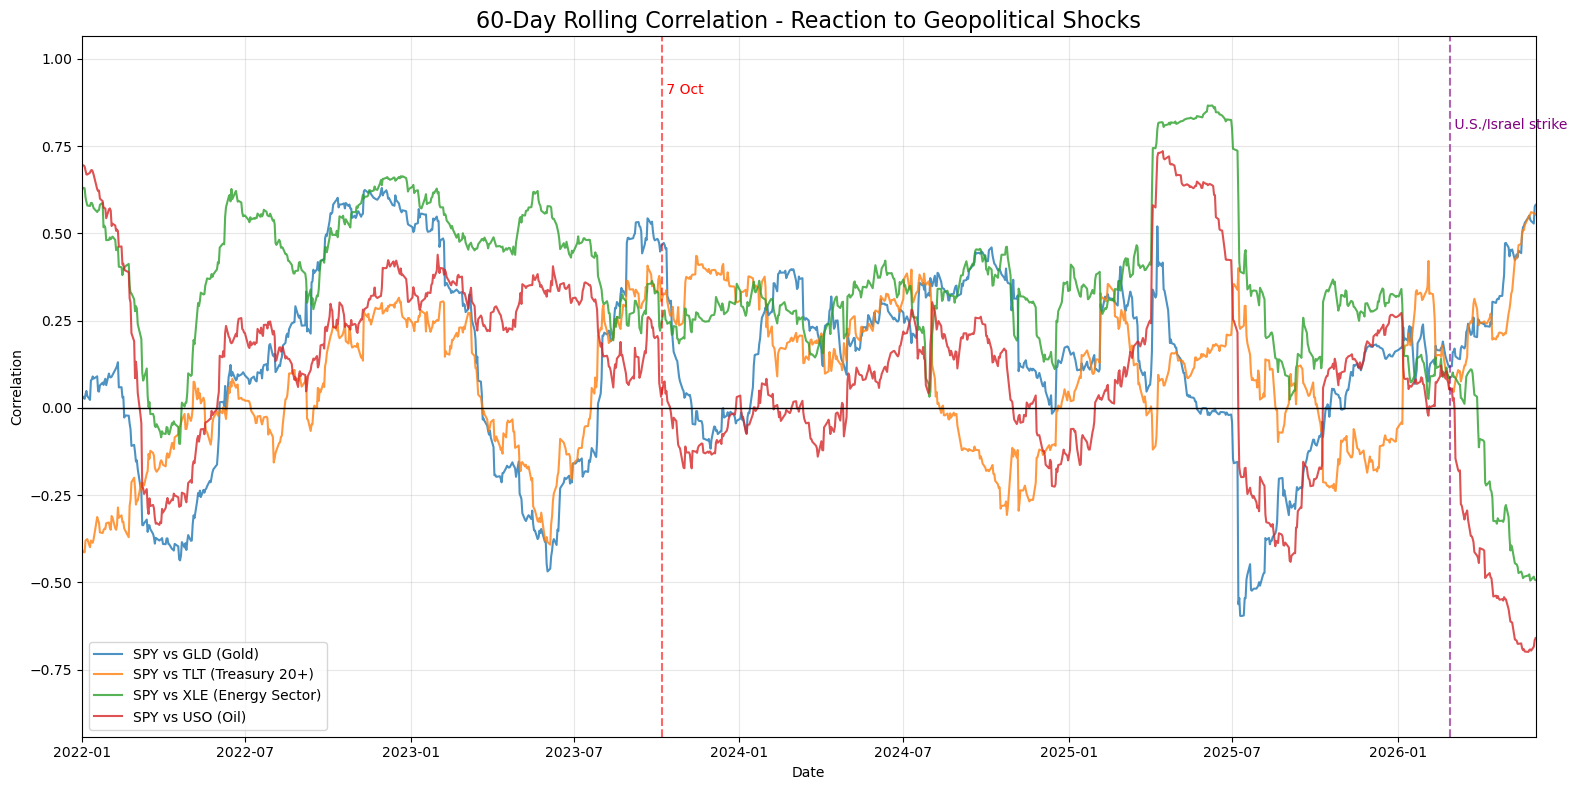

In [12]:
log_returns_daily = np.log(prices_daily / prices_daily.shift(1)).dropna(how="all")
window = 60

rolling_corr_gld = log_returns_daily['SPY'].rolling(window=window).corr(log_returns_daily['GLD'])
rolling_corr_tlt = log_returns_daily['SPY'].rolling(window=window).corr(log_returns_daily['TLT'])
# Use XLE as an energy-sector proxy
rolling_corr_xle = log_returns_daily['SPY'].rolling(window=window).corr(log_returns_daily['XLE'])
rolling_corr_uso = log_returns_daily['SPY'].rolling(window=window).corr(log_returns_daily['USO'])

plt.figure(figsize=(16, 8))
plt.plot(rolling_corr_gld, label='SPY vs GLD (Gold)', alpha=0.8, linewidth=1.5)
plt.plot(rolling_corr_tlt, label='SPY vs TLT (Treasury 20+)', alpha=0.8, linewidth=1.5)
plt.plot(rolling_corr_xle, label='SPY vs XLE (Energy Sector)', alpha=0.8, linewidth=1.5)
plt.plot(rolling_corr_uso, label='SPY vs USO (Oil)', alpha=0.8, linewidth=1.5)

# Historical geopolitical event markers
plt.axvline(pd.to_datetime('2023-10-07'), color='red', linestyle='--', alpha=0.6)
plt.text(pd.to_datetime('2023-10-07'), 0.9, ' 7 Oct' , color='red')

# Hormuz 2026 stress marker
plt.axvline(pd.to_datetime('2026-02-28'), color='purple', linestyle='--', alpha=0.6)
plt.text(pd.to_datetime('2026-02-28'), 0.8, ' U.S./Israel strike' , color='purple')


plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.title("60-Day Rolling Correlation - Reaction to Geopolitical Shocks", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)

plt.xlim(pd.to_datetime('2022-01-01'), log_returns_daily.index[-1])
plt.tight_layout()
plt.show()


This cell plots a base-100 cumulative wealth index for representative ETFs. A base-100 index is defined as

$$I_t = 100\exp\left(\sum_{s=1}^{t} r_s\right).$$

It allows assets with different price levels to be compared on the same scale. The selected ETFs represent equities, long-duration bonds, gold, emerging markets, broad commodities, and oil, so the plot gives an intuitive cross-asset view before portfolio construction.


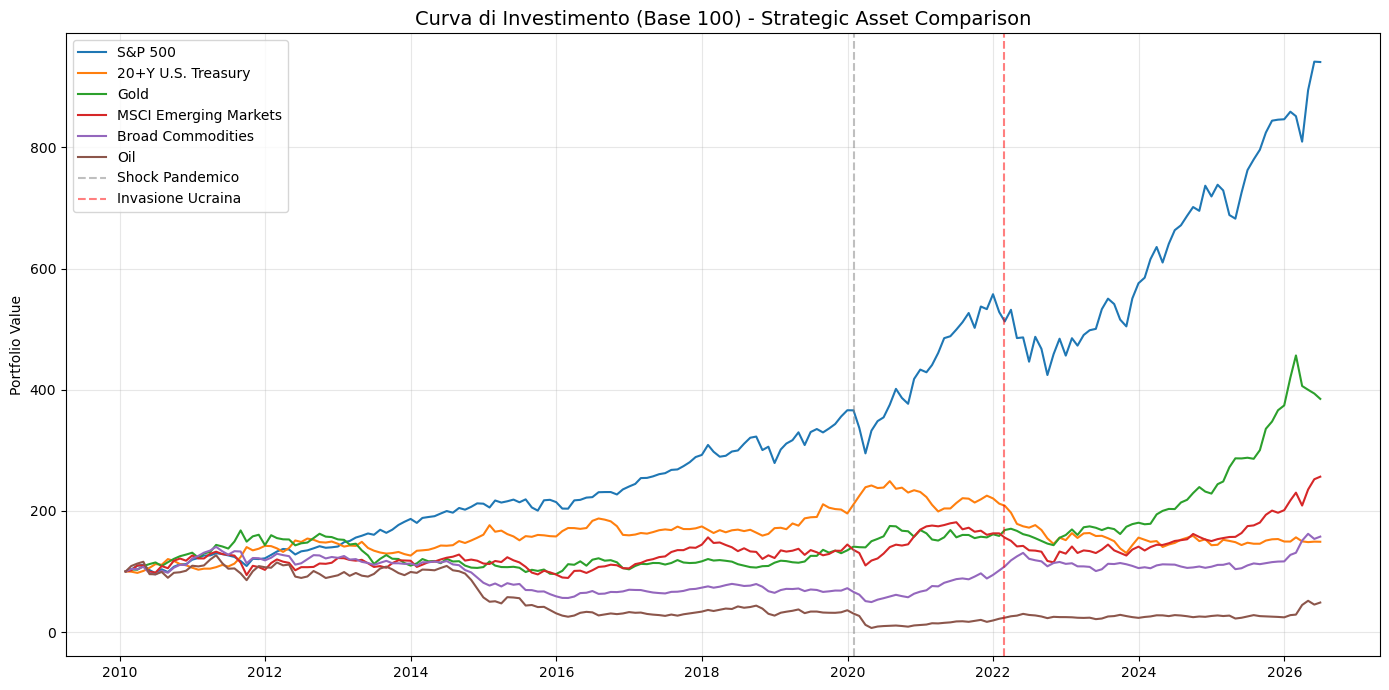

In [13]:
sample_tickers = ['SPY', 'TLT', 'GLD', 'EEM', 'DBC', "USO"]

cumulative_wealth = 100 * np.exp(log_returns_monthly[sample_tickers].cumsum())
cumulative_wealth.loc[prices_monthly.index[0]] = 100
cumulative_wealth = cumulative_wealth.sort_index()

plt.figure(figsize=(14, 7))
for ticker in sample_tickers:
    plt.plot(cumulative_wealth.index, cumulative_wealth[ticker], label=etf_universe[ticker], linewidth=1.5)

plt.axvline(pd.to_datetime('2020-02-01'), color='gray', linestyle='--', alpha=0.5, label='Shock Pandemico')
plt.axvline(pd.to_datetime('2022-02-24'), color='red', linestyle='--', alpha=0.5, label='Invasione Ucraina')

plt.title("Curva di Investimento (Base 100) - Strategic Asset Comparison", fontsize=14)
plt.ylabel("Portfolio Value")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


This cell produces the underwater plot. Drawdown at time $t$ is

$$DD_t=\frac{W_t}{\max_{s\le t}W_s}-1.$$

Unlike volatility, drawdown directly measures realized capital loss from a previous peak. This is important for evaluating whether a strategy is investable from a risk-management perspective.


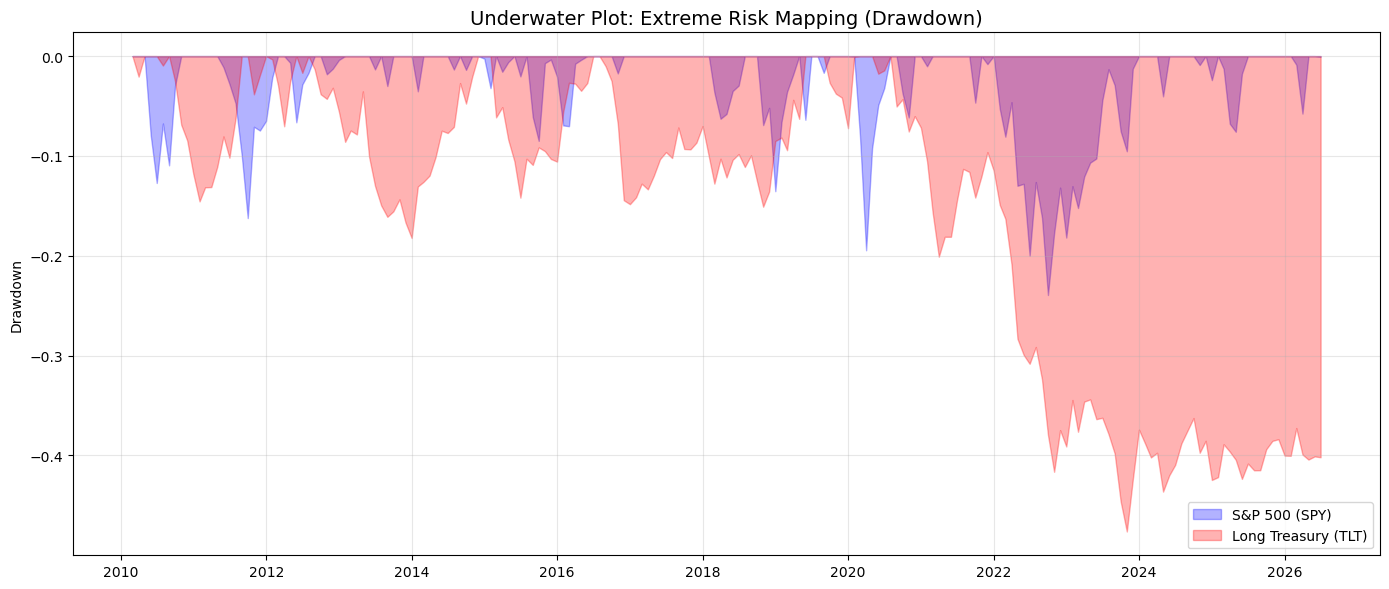

In [14]:
cum_returns_all = np.exp(log_returns_monthly.cumsum())
running_max_all = cum_returns_all.cummax()
drawdowns_all = (cum_returns_all / running_max_all) - 1

plt.figure(figsize=(14, 6))
plt.fill_between(drawdowns_all.index, drawdowns_all['SPY'], 0, color='blue', alpha=0.3, label='S&P 500 (SPY)')
plt.fill_between(drawdowns_all.index, drawdowns_all['TLT'], 0, color='red', alpha=0.3, label='Long Treasury (TLT)')

plt.title("Underwater Plot: Extreme Risk Mapping (Drawdown)", fontsize=14)
plt.ylabel("Drawdown")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


This cell estimates rolling annualized volatility. For a rolling monthly window of length $h$, volatility is computed as

$$\hat{\sigma}_{t,h}=\sqrt{12}\,\operatorname{std}(r_{t-h+1},\ldots,r_t).$$

The plot shows whether risk is stable or clustered over time, which affects the reliability of covariance estimates used by the optimizers.


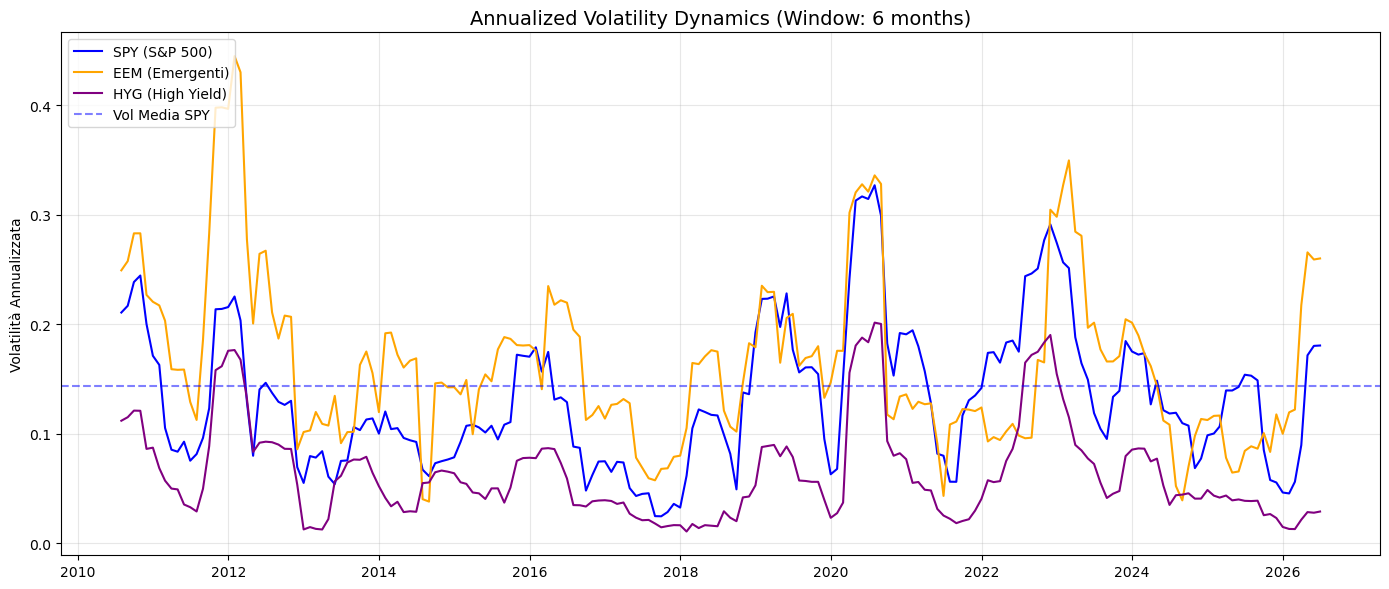

In [15]:
window_months = 6
rolling_vol = log_returns_monthly[['SPY', 'EEM', 'HYG']].rolling(window=window_months).std() * np.sqrt(12)

plt.figure(figsize=(14, 6))
plt.plot(rolling_vol['SPY'], label='SPY (S&P 500)', color='blue')
plt.plot(rolling_vol['EEM'], label='EEM (Emergenti)', color='orange')
plt.plot(rolling_vol['HYG'], label='HYG (High Yield)', color='purple')

plt.axhline(ann_volatility['SPY'], color='blue', linestyle='--', alpha=0.5, label='Vol Media SPY')
plt.title(f"Annualized Volatility Dynamics (Window: {window_months} months)", fontsize=14)
plt.ylabel("Volatilità Annualizzata")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


This cell compares the empirical SPY return distribution with a fitted normal density. Classical mean-variance models depend mainly on first and second moments, but real financial returns often show skewness and fat tails. Comparing the histogram with

$$r \sim \mathcal{N}(\mu,\sigma^2)$$

helps motivate why out-of-sample testing and robustness checks are necessary.


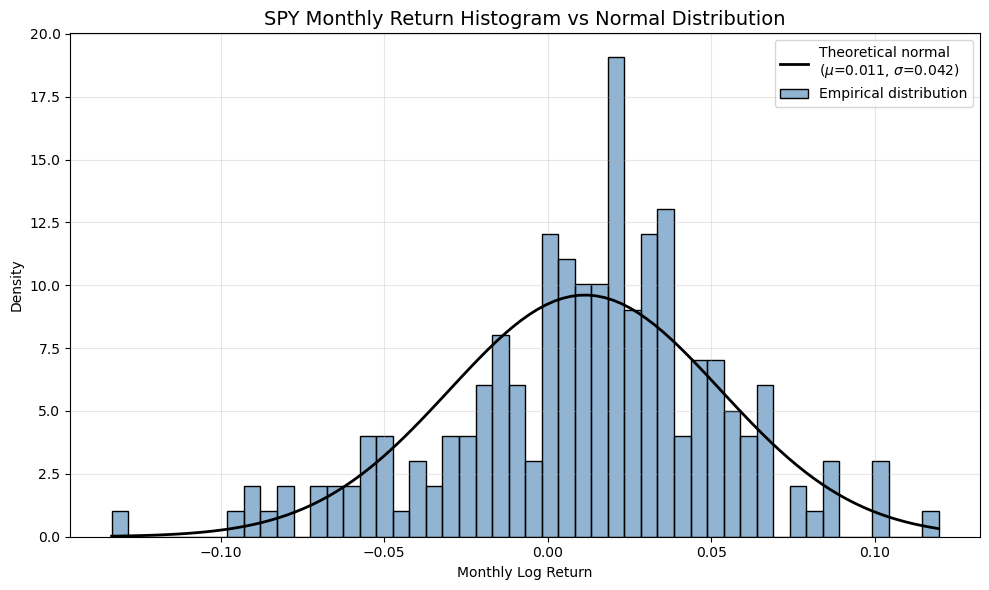

In [16]:
spy_returns = log_returns_monthly['SPY'].dropna()

plt.figure(figsize=(10, 6))
sns.histplot(spy_returns, bins=50, stat='density', alpha=0.6, color='steelblue', label='Empirical distribution')

mu, std = spy_returns.mean(), spy_returns.std()
x = np.linspace(spy_returns.min(), spy_returns.max(), 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label=f'Theoretical normal\n($\mu$={mu:.3f}, $\sigma$={std:.3f})')

plt.title("SPY Monthly Return Histogram vs Normal Distribution", fontsize=14)
plt.xlabel("Monthly Log Return")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


This cell creates a boxplot of monthly return dispersion. For each asset, the boxplot summarizes the empirical distribution of monthly log returns through median, interquartile range, and outliers. This is useful because two assets can have similar volatility but very different tail behavior, which matters for drawdown risk and portfolio robustness.


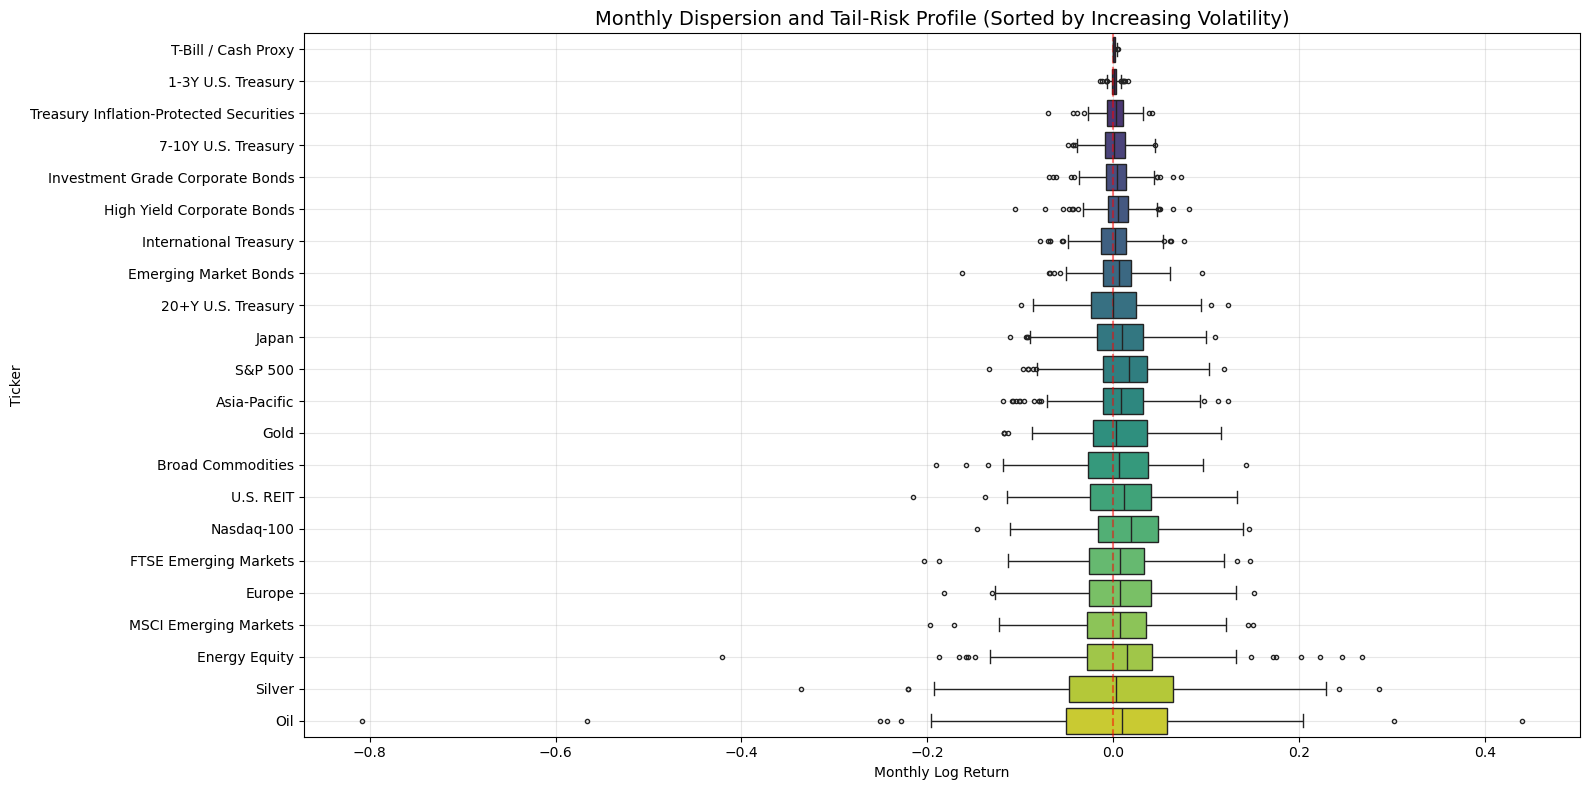

In [17]:
plt.figure(figsize=(16, 8))
sorted_tickers = ann_volatility.sort_values().index

sns.boxplot(data=log_returns_monthly[sorted_tickers], orient='h', palette='viridis', fliersize=3)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)

# Sostituiamo le label dell'asse y con i nomi estesi per leggibilità
plt.yticks(ticks=range(len(sorted_tickers)), labels=[etf_universe[t] for t in sorted_tickers])

plt.title("Monthly Dispersion and Tail-Risk Profile (Sorted by Increasing Volatility)", fontsize=14)
plt.xlabel("Monthly Log Return")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


This cell maps each asset in unconditional risk-return space. Every point has coordinates

$$(\hat{\sigma}_i,\hat{\mu}_i),$$

which provides the visual input intuition for the efficient frontier: portfolios should ideally lie above and to the left of individual assets, delivering higher expected return for the same risk or lower risk for the same expected return.


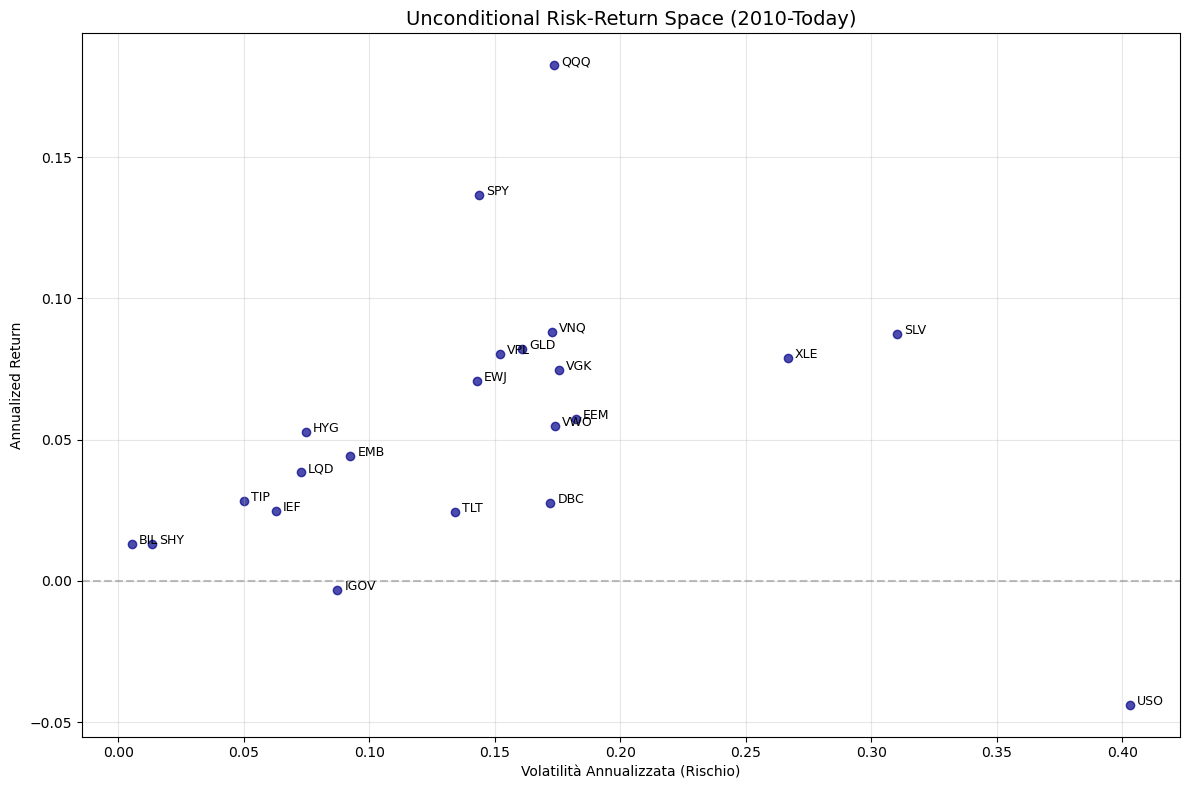

In [18]:
plt.figure(figsize=(12, 8))
plt.scatter(ann_volatility, ann_returns, alpha=0.7, color='darkblue')

for ticker in tickers:
    plt.annotate(
        ticker, 
        (ann_volatility[ticker], ann_returns[ticker]), 
        xytext=(5, 0), 
        textcoords='offset points',
        fontsize=9
    )

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.title("Unconditional Risk-Return Space (2010-Today)", fontsize=14)
plt.xlabel("Volatilità Annualizzata (Rischio)")
plt.ylabel("Annualized Return")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Classical Markowitz Models

This section implements the classical mean-variance tools required by the assignment: efficient frontier construction, maximum Sharpe optimization, target-return minimum variance, global minimum variance, and max-utility portfolios with different risk-aversion parameters.


This cell implements the classical Markowitz efficient frontier and the maximum-Sharpe portfolio. Mean-variance optimization describes a portfolio by expected return $w^T\mu$ and variance $w^T\Sigma w$. The efficient frontier is obtained by solving

$$\min_w \; w^T\Sigma w$$

subject to

$$w^T\mathbf{1}=1, \qquad w^T\mu=\mu_{target}, \qquad 0\le w_i\le 1.$$

The maximum-Sharpe or tangency portfolio instead solves

$$\max_w \; \frac{w^T\mu-r_f}{\sqrt{w^T\Sigma w}},$$

with the same long-only and fully invested constraints. This portfolio is sensitive to estimation error in $\hat{\mu}$, which is one of the reasons Michaud resampling is introduced later.


In [19]:
from scipy.optimize import minimize

# Annualize the expected returns and covariance matrix (multiplying by 12 for monthly data)
mu_hist = log_returns.mean().values * 12
sigma_hist = log_returns.cov().values * 12
asset_names = log_returns.columns.tolist()
rf_rate = 0.02 # Assuming a 2% risk-free rate

def get_max_sharpe_weights(mu: np.ndarray, sigma_matrix: np.ndarray, rf_rate: float = 0.02) -> np.ndarray:
    """Computes long-only portfolio weights maximizing the Sharpe Ratio via SLSQP optimization."""
    n_assets = len(mu)
    w0 = np.ones(n_assets) / n_assets
    
    # Objective function to minimize (Negative Sharpe Ratio)
    def neg_sharpe(w):
        p_ret = np.dot(w, mu)
        p_vol = np.sqrt(np.dot(w.T, np.dot(sigma_matrix, w)))
        if p_vol == 0: return 0
        return -(p_ret - rf_rate) / p_vol

    # Constraints: fully invested (sum of weights = 1) and long-only bounds (0 to 1)
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bounds = tuple((0.0, 1.0) for _ in range(n_assets))
    
    res = minimize(neg_sharpe, w0, method='SLSQP', bounds=bounds, constraints=constraints, options={'ftol': 1e-10})
    return res.x if res.success else w0

def build_efficient_frontier(mu: np.ndarray, sigma_matrix: np.ndarray, n_points: int = 50) -> tuple:
    """Traces out the long-only efficient frontier curve."""
    n_assets = len(mu)
    w0 = np.ones(n_assets) / n_assets
    
    # 1. Find Minimum Variance Portfolio (MVP) to set the lower bound of the frontier
    res_mvp = minimize(lambda w: w @ sigma_matrix @ w, w0, method='SLSQP',
                       bounds=[(0, 1)] * n_assets, constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}])
    
    min_ret = res_mvp.x @ mu
    max_ret = mu.max() * 0.999 # Max possible return is heavily concentrated in the highest-returning asset
    
    # Generate target returns between MVP and Max Return
    targets = np.linspace(min_ret, max_ret, n_points)
    f_vols, f_rets, f_weights = [], [], []
    
    # 2. Minimize variance for each target return
    for t in targets:
        cons = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}, 
                {'type': 'eq', 'fun': lambda w: w @ mu - t}]
        res = minimize(lambda w: w @ sigma_matrix @ w, w0, method='SLSQP', bounds=[(0, 1)] * n_assets, constraints=cons)
        if res.success:
            f_vols.append(np.sqrt(res.x @ sigma_matrix @ res.x))
            f_rets.append(res.x @ mu)
            f_weights.append(res.x)
            
    return np.array(f_vols), np.array(f_rets), np.array(f_weights)

# Compute Max Sharpe Portfolio and the Frontier
opt_weights_ms = get_max_sharpe_weights(mu_hist, sigma_hist, rf_rate)
opt_ret_ms = np.dot(opt_weights_ms, mu_hist)
opt_vol_ms = np.sqrt(np.dot(opt_weights_ms.T, np.dot(sigma_hist, opt_weights_ms)))

frontier_vols, frontier_rets, frontier_weights = build_efficient_frontier(mu_hist, sigma_hist)

print(">>> Optimization completed.")


>>> Optimization completed.


This cell defines the target-return minimum-variance optimizer. For a chosen target return $\mu^*$, the model solves

$$\min_w \; w^T\Sigma w \quad \text{s.t.} \quad w^T\mu=\mu^*, \; w^T\mathbf{1}=1, \; w_i\ge 0.$$

This is the core Markowitz problem from the assignment. By fixing the target return, the model searches for the least risky allocation capable of reaching that expected return.


In [20]:
def get_min_variance_target_return_weights(mu: np.ndarray, sigma_matrix: np.ndarray, target_return: float) -> np.ndarray:
    """
    Computes the Markowitz min-variance portfolio for a specific target return.
    
    Mathematical Formulation:
    Minimize: (1/2) * w^T * Sigma * w
    Subject to:
        1) w^T * mu = mu_target
        2) w^T * 1 = 1
        3) w >= 0 (Long-only constraint)
    """
    n_assets = len(mu)
    w0 = np.ones(n_assets) / n_assets
    
    # Objective Function: Minimize Variance
    def portfolio_variance(w):
        return np.dot(w.T, np.dot(sigma_matrix, w))

    # Constraints mapping exactly to the assignment requirements
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},               # Constraint: w^T 1 = 1 (Fully invested)
        {'type': 'eq', 'fun': lambda w: np.dot(w, mu) - target_return} # Constraint: w^T mu = mu_target
    )
    
    # Long-only bounds (0 to 1 for each asset)
    bounds = tuple((0.0, 1.0) for _ in range(n_assets))
    
    res = minimize(portfolio_variance, w0, method='SLSQP', bounds=bounds, constraints=constraints)
    
    return res.x if res.success else w0


This cell constructs a feasible target return by interpolating between the Global Minimum Variance (GMV) portfolio and the Max-Sharpe portfolio. The GMV portfolio solves

$$w_{GMV}=\arg\min_w w^T\Sigma w, \qquad w^T\mathbf{1}=1, \; w_i\ge0.$$

The target return is then defined as

$$\mu^*=(1-\alpha)\mu_{GMV}+\alpha\mu_{MS}, \qquad \alpha=0.5.$$

This avoids choosing an infeasible target and gives a balanced portfolio between minimum risk and maximum risk-adjusted return.


In [21]:

# --- STEP 1: Define Anchor Portfolios ---

# 1a. Compute Global Minimum Variance (GMV) Portfolio Weights
def get_gmv_weights(sigma_matrix: np.ndarray) -> np.ndarray:
    """Computes long-only weights for the Global Minimum Variance Portfolio."""
    n_assets = sigma_matrix.shape[0]
    w0 = np.ones(n_assets) / n_assets
    
    # Objective: minimize pure variance (no return constraint)
    def portfolio_variance(w):
        return np.dot(w.T, np.dot(sigma_matrix, w))
    
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bounds = tuple((0.0, 1.0) for _ in range(n_assets))
    
    res = minimize(portfolio_variance, w0, method='SLSQP', bounds=bounds, constraints=constraints)
    return res.x if res.success else w0

# Extract weights for the two anchor strategies
weights_gmv = get_gmv_weights(sigma_hist)
weights_ms = get_max_sharpe_weights(mu_hist, sigma_hist, rf_rate)

# Calculate expected returns for both anchor portfolios
mu_gmv = np.dot(weights_gmv, mu_hist)
mu_ms = np.dot(weights_ms, mu_hist)

# --- STEP 2: Convex Interpolation ---

# Set your risk propensity parameter alpha here (alpha in [0, 1])
# alpha = 0.0 -> Pure GMV (minimum risk)
# alpha = 1.0 -> Pure Max-Sharpe (maximum efficiency)
# alpha = 0.5 -> Balanced compromise exactly halfway on the efficient frontier
alpha = 0.5 

# Mathematically guaranteed to be feasible on the efficient frontier
dynamic_mu_target = (1 - alpha) * mu_gmv + alpha * mu_ms

# --- STEP 3: Final Optimization with Feasible Target ---

# Compute final optimized weights using your existing target-return function
optimized_weights_convex = get_min_variance_target_return_weights(
    mu_hist, 
    sigma_hist, 
    dynamic_mu_target
)

# --- STEP 4: Performance Evaluation ---
convex_portfolio_return = np.dot(optimized_weights_convex, mu_hist)
convex_portfolio_volatility = np.sqrt(np.dot(optimized_weights_convex.T, np.dot(sigma_hist, optimized_weights_convex)))

print(">>> Convex Interpolation Target Setting Completed.")
print(f"Anchor GMV Return (alpha=0):         {mu_gmv*100:.2f}%")
print(f"Anchor Max-Sharpe Return (alpha=1):   {mu_ms*100:.2f}%")
print(f"Selected Alpha:                      {alpha}")
print(f"Dynamically Calculated Target Mu:    {dynamic_mu_target*100:.2f}%")
print("-" * 50)
print(f"Final Portfolio Realized Return:     {convex_portfolio_return*100:.2f}%")
print(f"Final Portfolio Volatility:          {convex_portfolio_volatility*100:.2f}%")


>>> Convex Interpolation Target Setting Completed.
Anchor GMV Return (alpha=0):         1.32%
Anchor Max-Sharpe Return (alpha=1):   15.56%
Selected Alpha:                      0.5
Dynamically Calculated Target Mu:    8.44%
--------------------------------------------------
Final Portfolio Realized Return:     8.44%
Final Portfolio Volatility:          6.97%


This cell implements a mean-variance maximum-utility portfolio. Instead of fixing a target return, the investor chooses a risk-aversion parameter $\lambda$ and maximizes

$$U(w)=w^T\mu-\frac{\lambda}{2}w^T\Sigma w.$$

Equivalently, the code minimizes the negative utility. Lower $\lambda$ accepts more variance in pursuit of return, while higher $\lambda$ produces a more conservative allocation.


In [22]:
from scipy.optimize import minimize
import numpy as np

def get_max_utility_weights(mu: np.ndarray, sigma_matrix: np.ndarray, risk_aversion: float = 3.0) -> np.ndarray:
    """
    Computes the portfolio weights that maximize the Mean-Variance Utility function.
    
    Mathematical Formulation:
    Maximize: U = w^T * mu - (lambda/2) * w^T * Sigma * w
    
    Equivalent to Minimizing the Negative Utility:
    Minimize: (lambda/2) * w^T * Sigma * w - w^T * mu
    
    Subject to:
        1) w^T * 1 = 1 (Fully invested / Budget constraint)
        2) w >= 0 (Long-only constraint)
    """
    n_assets = len(mu)
    w0 = np.ones(n_assets) / n_assets
    
    # Obiettivo: Minimizzare la "Disutilità" (Negativo dell'Utilità)
    def negative_utility(w):
        expected_return = np.dot(w, mu)
        portfolio_variance = np.dot(w.T, np.dot(sigma_matrix, w))
        
        return (risk_aversion / 2.0) * portfolio_variance - expected_return

    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1} 
    )
    
    # Bounds: long-only, 0 to 1 for each asset
    bounds = tuple((0.0, 1.0) for _ in range(n_assets))
    
    # Run the SLSQP optimization
    res = minimize(negative_utility, w0, method='SLSQP', bounds=bounds, constraints=constraints)
    
    return res.x if res.success else w0

# Example evaluation
lambda_param = 3.0

opt_weights_utility = get_max_utility_weights(mu_hist, sigma_hist, lambda_param)

# Resulting portfolio metrics
opt_ret_utility = np.dot(opt_weights_utility, mu_hist)
opt_vol_utility = np.sqrt(np.dot(opt_weights_utility.T, np.dot(sigma_hist, opt_weights_utility)))
opt_utility_score = opt_ret_utility - (lambda_param / 2.0) * (opt_vol_utility**2)

print(f">>> Max Utility Portfolio (lambda = {lambda_param}):")
print(f"Expected Return:      {opt_ret_utility*100:.2f}%")
print(f"Volatility:           {opt_vol_utility*100:.2f}%")
print(f"Maximized Utility (U): {opt_utility_score:.4f}")


>>> Max Utility Portfolio (lambda = 3.0):
Expected Return:      18.25%
Volatility:           17.36%
Maximized Utility (U): 0.1373


This cell plots the Markowitz efficient frontier, individual assets, the Max-Sharpe portfolio, and the Capital Allocation Line. The Capital Allocation Line has slope equal to the Sharpe ratio of the tangency portfolio:

$$E[R_p]=r_f + SR_{MS}\sigma_p.$$

The plot connects the numerical optimizer to the geometric interpretation of Modern Portfolio Theory.


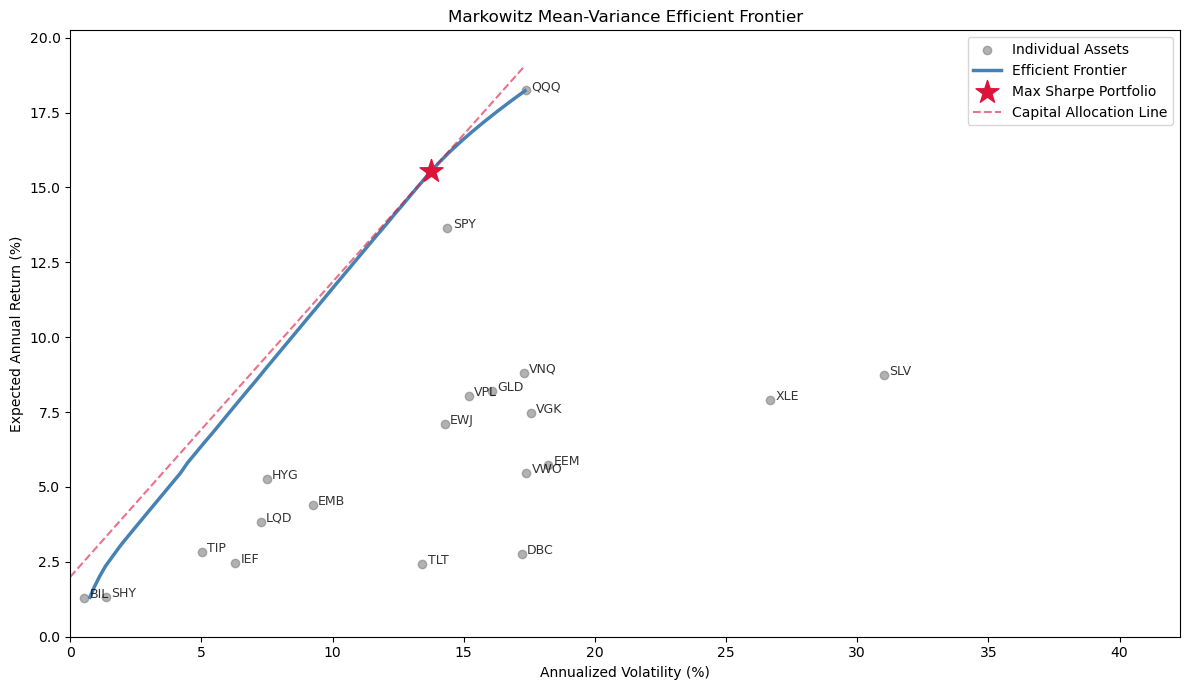


Maximum Sharpe Portfolio Allocation:
     Weight (%)
QQQ       73.23
GLD       26.77


In [23]:
# Plot 3: Efficient Frontier and Max Sharpe Portfolio
plt.figure(figsize=(12, 7))

# Plot individual assets
asset_vols = np.sqrt(np.diag(sigma_hist))
plt.scatter(asset_vols * 100, mu_hist * 100, color='grey', marker='o', alpha=0.6, label='Individual Assets')

# Annotate individual assets
for i, txt in enumerate(asset_names):
    plt.annotate(txt, (asset_vols[i] * 100 + 0.2, mu_hist[i] * 100), fontsize=9, alpha=0.8)
# Plot the Efficient Frontier
plt.plot(frontier_vols * 100, frontier_rets * 100, color='steelblue', lw=2.5, label='Efficient Frontier')

# Plot the Max Sharpe Portfolio
plt.scatter(opt_vol_ms * 100, opt_ret_ms * 100, color='crimson', marker='*', s=300, zorder=5, label='Max Sharpe Portfolio')

# Plot the Capital Allocation Line (CAL) approximation
cal_x = np.linspace(0, max(frontier_vols)*100, 20)
cal_y = rf_rate*100 + cal_x * ((opt_ret_ms - rf_rate) / opt_vol_ms)
plt.plot(cal_x, cal_y, color='crimson', linestyle='--', alpha=0.6, label='Capital Allocation Line')

plt.xlim(0, max(asset_vols)*100 + 2)
plt.ylim(0, max(mu_hist)*100 + 2)
plt.xlabel('Annualized Volatility (%)')
plt.ylabel('Expected Annual Return (%)')
plt.title('Markowitz Mean-Variance Efficient Frontier')
plt.legend()
plt.tight_layout()
plt.show()

# Display Max Sharpe Weights
ms_weights_df = pd.DataFrame({'Weight (%)': np.round(opt_weights_ms * 100, 2)}, index=asset_names)
print("\nMaximum Sharpe Portfolio Allocation:")
print(ms_weights_df[ms_weights_df['Weight (%)'] > 0.1].sort_values(by='Weight (%)', ascending=False))


This cell visualizes portfolio composition along the efficient frontier. Each point on the frontier corresponds not only to a risk-return pair, but also to a vector of weights $w$. The stacked area chart shows how the optimizer changes exposure as the target return rises, making concentration and asset rotation visible.


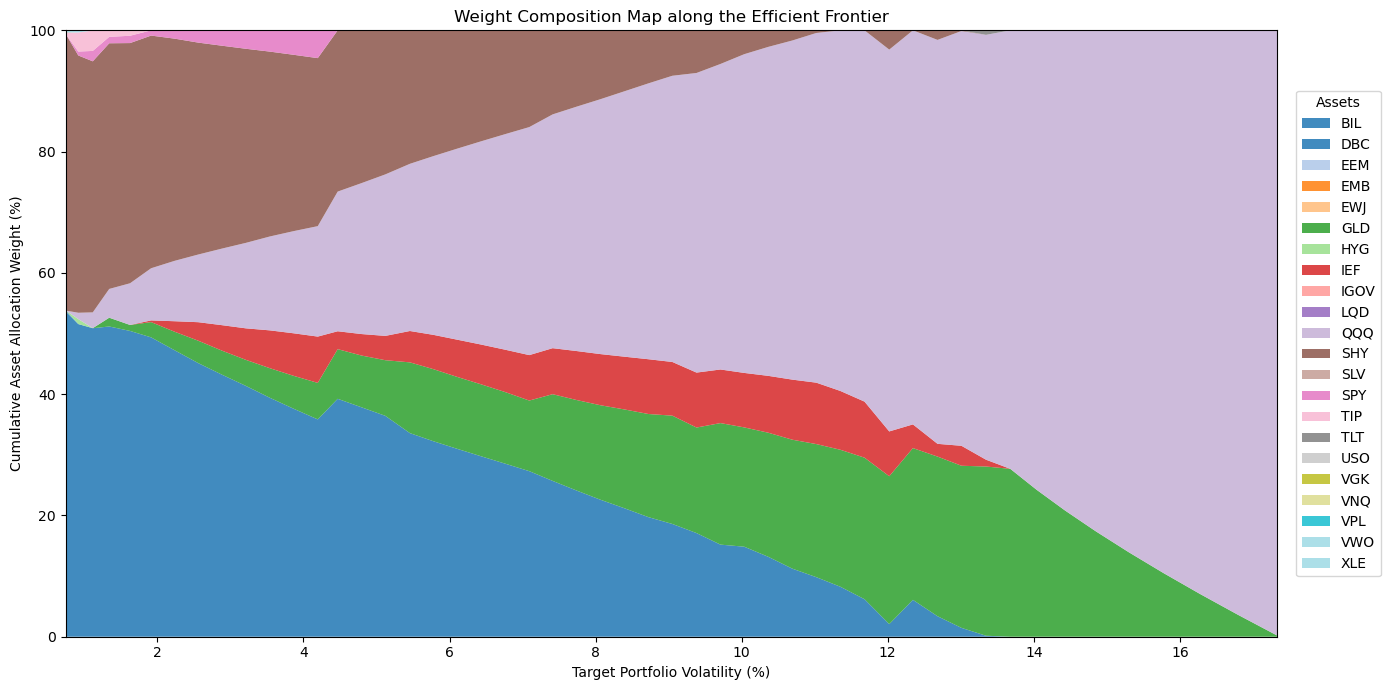

In [24]:
# Plot 4: Weight Composition along the Frontier
colors = plt.cm.tab20(np.linspace(0, 1, len(asset_names)))

plt.figure(figsize=(14, 7))
plt.stackplot(frontier_vols * 100, frontier_weights.T * 100, labels=asset_names, colors=colors, alpha=0.85)

plt.xlim(frontier_vols.min() * 100, frontier_vols.max() * 100)
plt.ylim(0, 100)
plt.xlabel('Target Portfolio Volatility (%)')
plt.ylabel('Cumulative Asset Allocation Weight (%)')
plt.title('Weight Composition Map along the Efficient Frontier')

# Place legend outside the plot for readability
plt.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=10, title="Assets")
plt.tight_layout()
plt.show()


## 4. Rolling Out-of-Sample Backtest

The rolling backtest uses a 60-month estimation window and monthly rebalancing. At each date, the models use only past information, then apply the resulting weights to the next realized monthly return. The benchmark set includes equal-weight and strategic 60/40 portfolios.


This cell explains the out-of-sample design used for model comparison. At each rebalancing date $t$, parameters are estimated only on the past rolling window $[t-h,t-1]$, weights $w_t$ are computed, and performance is measured on the next realized return $r_t$:

$$R^{strategy}_t = w_t^T r_t.$$

This avoids look-ahead bias and evaluates whether the optimization rule generalizes beyond the estimation sample.

| Design choice | Setting |
|---|---|
| Universe | Multi-asset ETF universe |
| Frequency | Monthly returns |
| Estimation window | 60 months |
| Constraints | Long-only, fully invested |
| Covariance estimator | Sample covariance matrix |
| Return estimator | Sample mean of monthly log returns, annualized |
| Target return | Convex interpolation between GMV and Max-Sharpe expected return, with alpha = 0.5 |
| Max-Utility risk aversion | lambda in {1, 3, 6} |
| Benchmarks | Equal-Weight (1/N) and Strategic 60/40 |


This cell converts the benchmark definitions into arrays aligned with the full ETF universe. Benchmarks must be expressed as weight vectors $w$ with the same ordering as the return matrix, so that realized portfolio returns can be computed consistently as

$$R_t = w^T r_t.$$

The code verifies that both benchmark weight vectors are fully invested, i.e. $\sum_i w_i=1$.


In [25]:

# Complete universe
all_tickers = tickers
n_assets = len(all_tickers)

# 1. Equal Weight Benchmark (1/N)
w_ew = np.ones(n_assets) / n_assets

# 2. Strategic 60/40 Benchmark (zero-weight on tactical assets)
w_6040 = np.zeros(n_assets)
for i, t in enumerate(all_tickers):
    if t in equity_tickers:
        w_6040[i] = 0.60 / len(equity_tickers)
    elif t in bond_tickers:
        w_6040[i] = 0.40 / len(bond_tickers)
        
# Verify weights sum to 1
assert np.isclose(np.sum(w_ew), 1.0), "Equal weights must sum to 1"
assert np.isclose(np.sum(w_6040), 1.0), "60/40 weights must sum to 1"

print(f">>> Universe size: {n_assets} assets.")


>>> Universe size: 22 assets.


This cell defines the rolling backtest engine for Markowitz strategies and benchmarks. The procedure is recursive: estimate $\hat{\mu}_t$ and $\hat{\Sigma}_t$ from the previous 60 months, optimize weights, apply them to the next month, and repeat. This produces a genuine out-of-sample return series for each strategy.


In [26]:
def run_rolling_backtest(returns_df: pd.DataFrame, w_eq: np.ndarray, w_6040: np.ndarray,
                          w_ew: np.ndarray, tickers: list, window: int = 60,
                          utility_lambdas: tuple = (1.0, 3.0, 6.0, 10.0)) -> pd.DataFrame:
    """
    Executes a dynamic out-of-sample backtest with monthly rolling rebalancing windows.

    Parameters
    ----------
    returns_df : pd.DataFrame
        Log returns DataFrame (monthly frequency).
    w_eq : np.ndarray
        Placeholder equilibrium weights retained for interface compatibility.
    w_6040 : np.ndarray
        Static 60/40 benchmark weights.
    w_ew : np.ndarray
        Equal-weight (1/N) benchmark weights.
    tickers : list
        List of asset tickers in the same order as returns_df columns.
    window : int
        Rolling estimation window length in months (default: 60).
    utility_lambdas : tuple
        Risk-aversion parameters for Markowitz max-utility portfolios.

    Returns
    -------
    strat_returns : pd.DataFrame
        Monthly simple returns for each implemented strategy.
    """

    oos_index = returns_df.index[window:]
    total_months = len(returns_df) - window
    utility_lambdas = tuple(float(lam) for lam in utility_lambdas)
    utility_labels = {
        lam: f"Markowitz Max-Utility (lambda={lam:g})"
        for lam in utility_lambdas
    }

    style_map = {
        'Markowitz Max-Sharpe':                 ('firebrick', '-',  2.5),
        'Markowitz Target-Return Min-Variance': ('royalblue', '-',  2.5),
        'Equal-Weight (1/N)':                   ('grey',      '--', 1.5),
        'Strategic 60/40':                      ('black',     '-.', 1.5),
    }
    utility_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(utility_lambdas)))
    for lam, color in zip(utility_lambdas, utility_colors):
        style_map[utility_labels[lam]] = (color, '-', 1.8)

    m_ms_rets      = []
    m_target_rets  = []
    utility_rets   = {lam: [] for lam in utility_lambdas}
    ew_rets        = []
    b6040_rets     = []

    print(f">>> Executing Rolling Backtest ({window}-month estimation window). {total_months} periods...")
    print(f">>> Max-Utility lambdas: {utility_lambdas}")

    for i in range(window, len(returns_df)):
        train_slice   = returns_df.iloc[i - window:i]
        realized_step = returns_df.iloc[i].values
        current_date  = returns_df.index[i]

        if (i - window) % 12 == 0:
            print(f"    - Optimizing portfolios for date: {current_date.strftime('%Y-%m')}")

        # Estimate rolling sample parameters from monthly log returns, then annualize them.
        mu_h  = train_slice.mean().values * 12
        cov_h = train_slice.cov().values  * 12

        # Strategy 1a: Markowitz Max-Sharpe / tangency portfolio.
        w_ms = get_max_sharpe_weights(mu_h, cov_h, rf_rate)

        # Strategy 1b: Markowitz minimum-variance portfolio with a dynamic target return.
        # The target is a convex interpolation between the expected return of the
        # pure GMV portfolio and the expected return of the Max-Sharpe portfolio.
        alpha       = 0.5
        w_gmv_pure  = get_gmv_weights(cov_h)
        w_ms_anchor = get_max_sharpe_weights(mu_h, cov_h, rf_rate)

        mu_gmv_anchor = np.dot(w_gmv_pure,  mu_h)
        mu_ms_anchor  = np.dot(w_ms_anchor, mu_h)

        dynamic_mu_target = (1 - alpha) * mu_gmv_anchor + alpha * mu_ms_anchor
        w_target = get_min_variance_target_return_weights(mu_h, cov_h, dynamic_mu_target)

        # Strategy 1c: Markowitz Max-Utility portfolios for different risk aversion levels.
        utility_weights = {
            lam: get_max_utility_weights(mu_h, cov_h, risk_aversion=lam)
            for lam in utility_lambdas
        }

        # Realized OOS step: convert the one-month log return vector to simple returns
        # before applying portfolio weights.
        realized_simple = np.exp(realized_step) - 1

        m_ms_rets.append(np.dot(w_ms,       realized_simple))
        m_target_rets.append(np.dot(w_target, realized_simple))
        for lam, w_utility in utility_weights.items():
            utility_rets[lam].append(np.dot(w_utility, realized_simple))
        ew_rets.append(np.dot(w_ew,         realized_simple))
        b6040_rets.append(np.dot(w_6040,    realized_simple))

    strat_returns = pd.DataFrame(index=oos_index, dtype=float)
    strat_returns['Markowitz Max-Sharpe']                 = m_ms_rets
    strat_returns['Markowitz Target-Return Min-Variance'] = m_target_rets
    for lam in utility_lambdas:
        strat_returns[utility_labels[lam]] = utility_rets[lam]
    strat_returns['Equal-Weight (1/N)']                   = ew_rets
    strat_returns['Strategic 60/40']                      = b6040_rets

    # CHART A: Out-of-Sample Wealth Index (Full Period)
    wealth_index = (1 + strat_returns).cumprod() * 100

    plt.figure(figsize=(14, 8))
    for col in wealth_index.columns:
        c, ls, lw = style_map[col]
        plt.plot(wealth_index.index, wealth_index[col],
                 label=col, color=c, linestyle=ls, linewidth=lw)

    plt.axvspan('2025-10-01', '2026-06-30', color='red', alpha=0.1,
                label='2025-2026 Stress Window')
    plt.title('Out-of-Sample Wealth Index: Markowitz Utility Sensitivity')
    plt.ylabel('Portfolio Value (Base 100)')
    plt.legend(loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()

    crisis_start = pd.Timestamp('2025-01-01')
    if strat_returns.index[-1] >= crisis_start:
        crisis_rets   = strat_returns.loc[crisis_start:]
        crisis_wealth = (1 + crisis_rets).cumprod() * 100

        plt.figure(figsize=(14, 7))
        for col in crisis_wealth.columns:
            c, ls, lw = style_map[col]
            plt.plot(crisis_wealth.index, crisis_wealth[col],
                     label=col, color=c, linestyle=ls, linewidth=lw)

        plt.axvspan('2025-12-01', '2026-04-30', color='darkred', alpha=0.15,
                    label='2025-2026 Stress Window')
        plt.title('Stress-Window Robustness: Markowitz Utility Sensitivity (Base 100 at Jan 2025)')
        plt.ylabel('Normalized Capital Value')
        plt.legend(loc='lower left', fontsize=9)
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()
    return strat_returns


This cell prepares the final monthly return matrix and runs the rolling backtest. Returns are computed from monthly prices, and each strategy is evaluated through the same function so that differences in performance come from allocation rules rather than from inconsistent data treatment or rebalancing frequency.


>>> Data downloaded successfully. observations: 197
>>> Executing Rolling Backtest (60-month estimation window). 137 periods...
>>> Max-Utility lambdas: (1.0, 3.0, 6.0)
    - Optimizing portfolios for date: 2015-02
    - Optimizing portfolios for date: 2016-02
    - Optimizing portfolios for date: 2017-02
    - Optimizing portfolios for date: 2018-02
    - Optimizing portfolios for date: 2019-02
    - Optimizing portfolios for date: 2020-02
    - Optimizing portfolios for date: 2021-02
    - Optimizing portfolios for date: 2022-02
    - Optimizing portfolios for date: 2023-02
    - Optimizing portfolios for date: 2024-02
    - Optimizing portfolios for date: 2025-02
    - Optimizing portfolios for date: 2026-02


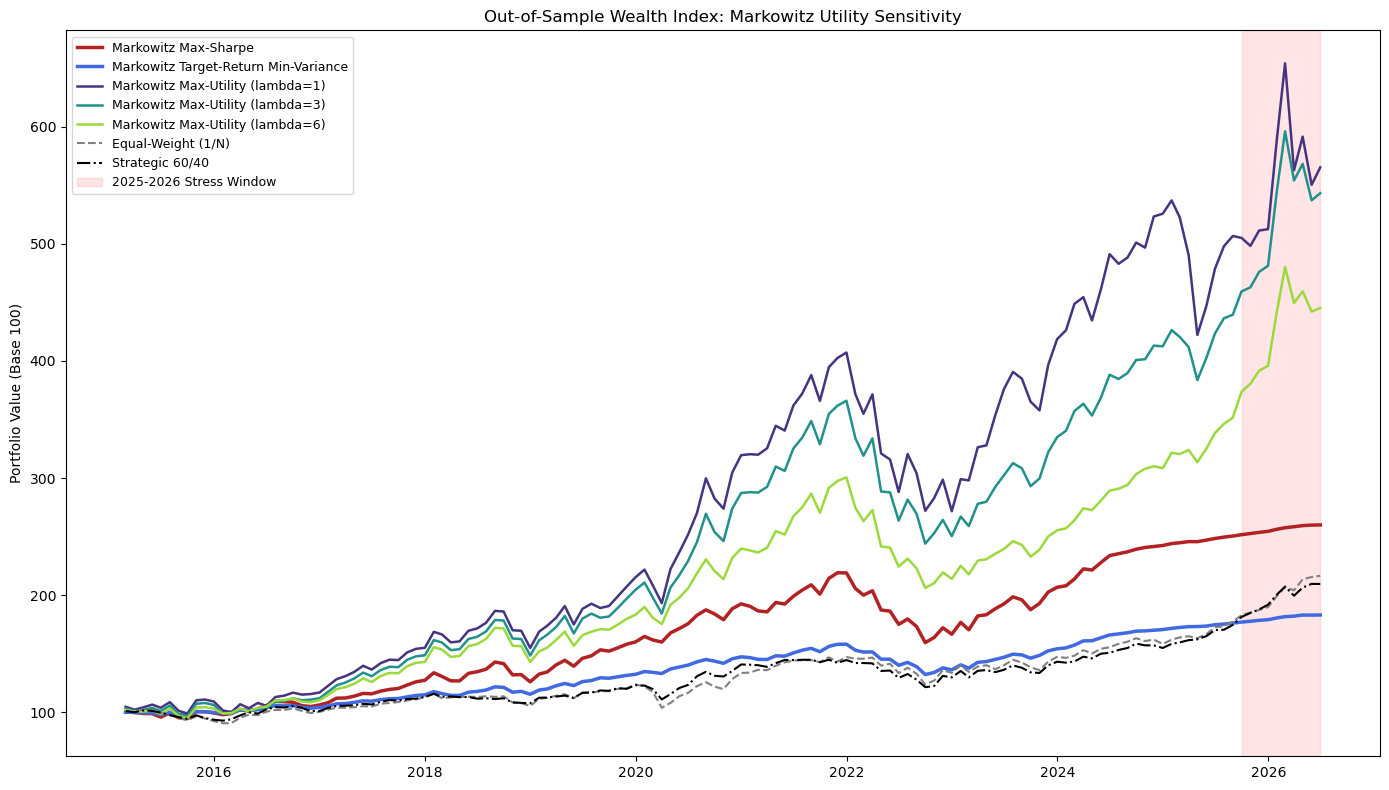

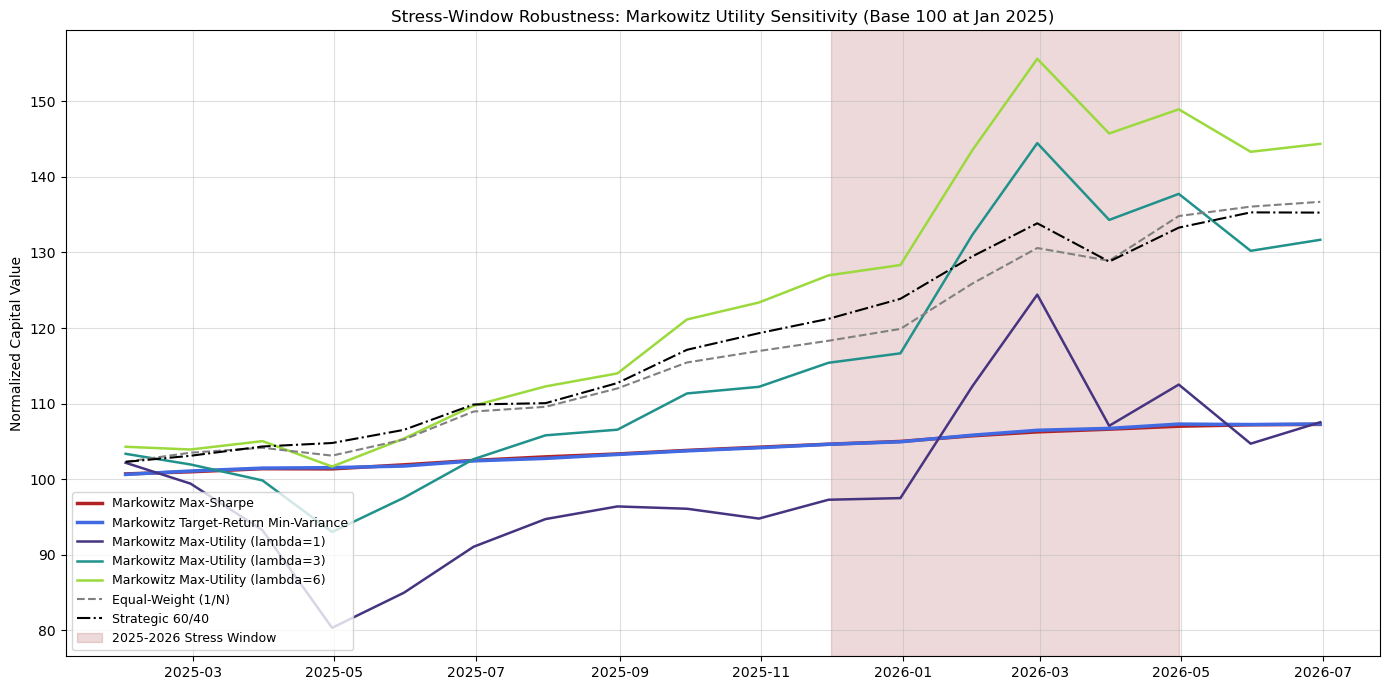

In [27]:
# 4. Resample to monthly and calculate log returns
monthly_prices_all = prices.resample('ME').last()
returns_df = np.log(monthly_prices_all / monthly_prices_all.shift(1)).dropna()

print(f">>> Data downloaded successfully. observations: {len(returns_df)}")

# 5. NOW you can safely run the backtest
utility_lambdas = (1.0, 3.0, 6.0)
oos_returns = run_rolling_backtest(
    returns_df,
    w_ew,
    w_6040,
    w_ew,
    tickers,
    window=60,
    utility_lambdas=utility_lambdas,
)


This cell calculates out-of-sample performance metrics. The key statistics are compound annual growth rate,

$$CAGR=\left(\prod_{t=1}^{T}(1+R_t)\right)^{12/T}-1,$$

annualized volatility,

$$\sigma_{ann}=\sqrt{12}\,\operatorname{std}(R_t),$$

Sharpe ratio,

$$SR=\frac{CAGR-r_f}{\sigma_{ann}},$$

and maximum drawdown, which captures the worst realized capital loss from a previous peak.


In [28]:
def calculate_performance_metrics(strat_returns: pd.DataFrame, rf_rate: float = 0.02) -> pd.DataFrame:
    """Calculates compound return, annualized volatility, Sharpe Ratio, and Max Drawdown."""
    metrics = pd.DataFrame(index=strat_returns.columns)
    
    # 1. Compound Annual Growth Rate (CAGR)
    cum_returns = (1 + strat_returns).prod()
    n_years = len(strat_returns) / 12
    ann_ret = cum_returns ** (1 / n_years) - 1
    metrics['CAGR (%)'] = ann_ret * 100
    
    # 2. Annualized Volatility
    ann_vol = strat_returns.std() * np.sqrt(12)
    metrics['Ann. Volatility (%)'] = ann_vol * 100
    
    # 3. Sharpe Ratio
    metrics['Sharpe Ratio'] = (ann_ret - rf_rate) / ann_vol
    
    # 4. Maximum Drawdown (Risk mapping)
    wealth_index = (1 + strat_returns).cumprod()
    peak = wealth_index.cummax()
    drawdown = (wealth_index - peak) / peak
    metrics['Max Drawdown (%)'] = drawdown.min() * 100
    
    return metrics.round(2)

# Uncomment to execute after running the backtest
metrics_df = calculate_performance_metrics(oos_returns, rf_rate=0.02)
print("\n=== OUT-OF-SAMPLE METRICS (Full Period) ===")
print(metrics_df.to_string())



=== OUT-OF-SAMPLE METRICS (Full Period) ===
                                      CAGR (%)  Ann. Volatility (%)  Sharpe Ratio  Max Drawdown (%)
Markowitz Max-Sharpe                      8.73                 9.83          0.68            -27.20
Markowitz Target-Return Min-Variance      5.44                 5.14          0.67            -16.39
Markowitz Max-Utility (lambda=1)         16.38                19.52          0.74            -33.27
Markowitz Max-Utility (lambda=3)         15.98                16.68          0.84            -33.32
Markowitz Max-Utility (lambda=6)         13.98                13.88          0.86            -31.41
Equal-Weight (1/N)                        7.00                 9.48          0.53            -16.05
Strategic 60/40                           6.70                 8.02          0.59            -16.16


This cell reconstructs rolling Max-Sharpe weights. Weight paths matter because a strategy can have attractive returns but be impractical if it trades too aggressively. Large month-to-month changes suggest sensitivity to estimation noise in $\hat{\mu}$ and $\hat{\Sigma}$.


>>> Extracting historical weights for Markowitz Max-Sharpe...


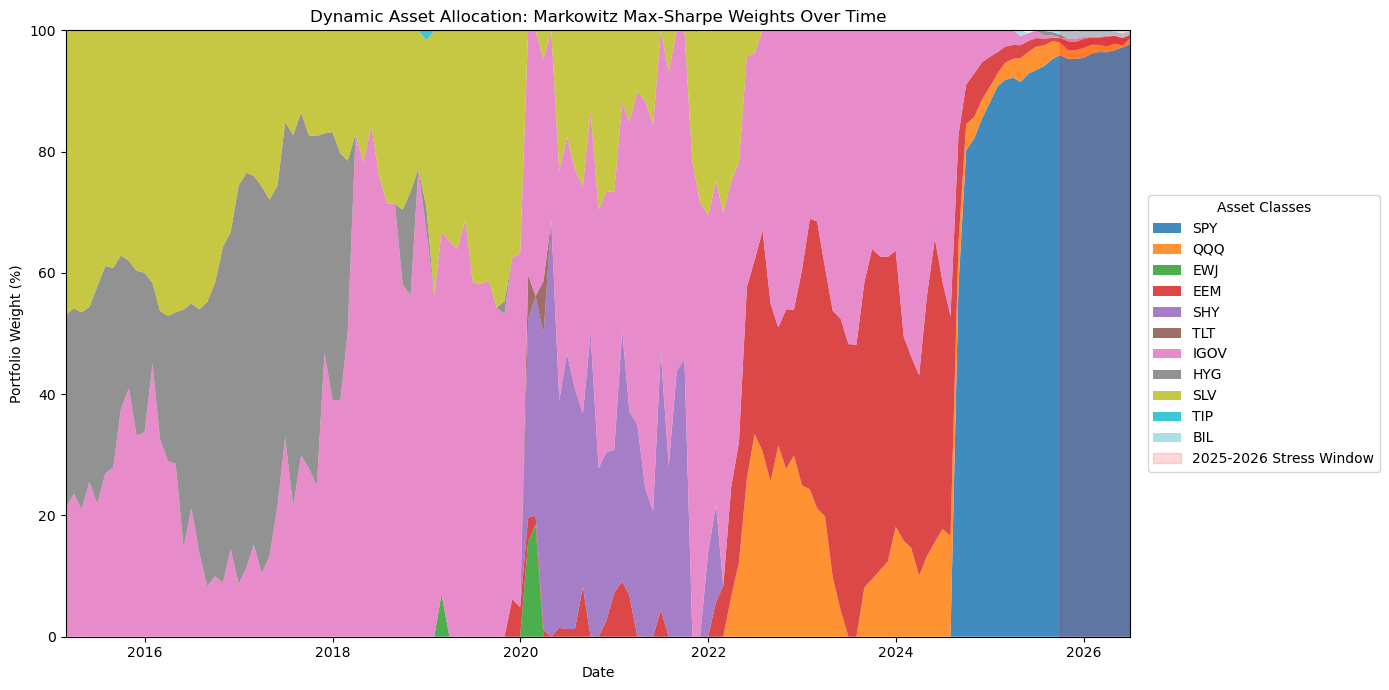

In [29]:
window = 60
oos_index = returns_df.index[window:]
markowitz_weights_history = pd.DataFrame(index=oos_index, columns=all_tickers)

print(">>> Extracting historical weights for Markowitz Max-Sharpe...")

for i in range(window, len(returns_df)):
    train_slice = returns_df.iloc[i-window:i]
    
    mu_h = train_slice.mean().values * 12
    cov_h = train_slice.cov().values * 12
    
    w_mv = get_max_sharpe_weights(mu_h, cov_h, rf_rate)
    
    markowitz_weights_history.iloc[i-window] = w_mv

threshold = 0.01 # 1%
max_weights = markowitz_weights_history.max()
active_assets = max_weights[max_weights > threshold].index
filtered_weights_history = markowitz_weights_history[active_assets].astype(float) * 100

plt.figure(figsize=(14, 7))

colors = plt.cm.tab20(np.linspace(0, 1, len(active_assets)))

plt.stackplot(filtered_weights_history.index, 
              filtered_weights_history.T, 
              labels=active_assets, 
              colors=colors, 
              alpha=0.85)

plt.title('Dynamic Asset Allocation: Markowitz Max-Sharpe Weights Over Time')
plt.ylabel('Portfolio Weight (%)')
plt.xlabel("Date")
plt.xlim(filtered_weights_history.index.min(), filtered_weights_history.index.max())
plt.ylim(0, 100)

plt.axvspan('2025-10-01', '2026-06-30', color='red', alpha=0.15, label='2025-2026 Stress Window')

plt.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=10, title="Asset Classes")
plt.tight_layout()
plt.show()


This cell reconstructs rolling target-return minimum-variance weights and computes turnover. Monthly turnover is measured as

$$TO_t=\frac{1}{2}\sum_i |w_{i,t}-w_{i,t-1}|.$$

The factor $1/2$ avoids double-counting buys and sells. Lower turnover generally means lower transaction costs and a more stable allocation.


>>> Extracting historical weights for Markowitz Target-Return Min-Variance...


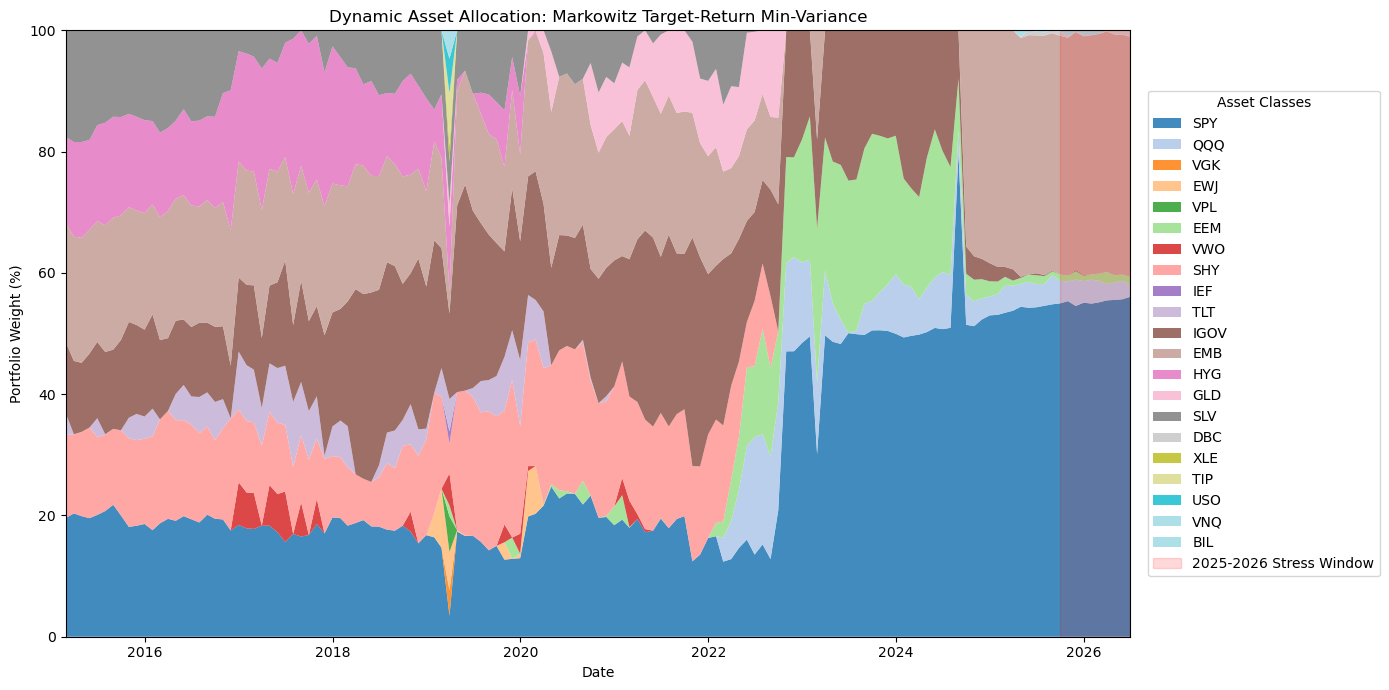


=== AVERAGE MONTHLY TURNOVER ===
                                      Average Monthly Turnover (%)
Markowitz Max-Sharpe                                          8.74
Markowitz Target-Return Min-Variance                          7.20


In [30]:
target_mv_weights_history = pd.DataFrame(index=oos_index, columns=all_tickers)

print(">>> Extracting historical weights for Markowitz Target-Return Min-Variance...")

for i in range(window, len(returns_df)):
    train_slice = returns_df.iloc[i-window:i]
    
    mu_h = train_slice.mean().values * 12
    cov_h = train_slice.cov().values * 12

    weights_gmv = get_gmv_weights(cov_h)
    weights_ms = get_max_sharpe_weights(mu_h, cov_h, rf_rate)

    mu_gmv = np.dot(weights_gmv, mu_h)
    mu_ms = np.dot(weights_ms, mu_h)

    alpha = 0.5 
    dynamic_mu_target = (1 - alpha) * mu_gmv + alpha * mu_ms
    w_target_mv = get_min_variance_target_return_weights(mu_h, cov_h, dynamic_mu_target)

    target_mv_weights_history.iloc[i-window] = w_target_mv

active_assets_target = target_mv_weights_history.max()[target_mv_weights_history.max() > threshold].index
filtered_target_weights = target_mv_weights_history[active_assets_target].astype(float) * 100

# Plot the Target-Return Min-Variance portfolio recomposition
plt.figure(figsize=(14, 7))

colors_target = plt.cm.tab20(np.linspace(0, 1, len(active_assets_target)))

plt.stackplot(filtered_target_weights.index, 
              filtered_target_weights.T, 
              labels=active_assets_target, 
              colors=colors_target, 
              alpha=0.85)

plt.title('Dynamic Asset Allocation: Markowitz Target-Return Min-Variance')
plt.ylabel('Portfolio Weight (%)')
plt.xlabel("Date")
plt.xlim(filtered_target_weights.index.min(), filtered_target_weights.index.max())
plt.ylim(0, 100)

plt.axvspan('2025-10-01', '2026-06-30', color='red', alpha=0.15, label='2025-2026 Stress Window')

plt.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=10, title="Asset Classes")
plt.tight_layout()
plt.show()

# Turnover numerico: turnover_t = 0.5 * sum(abs(w_t - w_{t-1}))
def calculate_average_turnover(weights_history: pd.DataFrame) -> float:
    weights = weights_history.astype(float)
    turnover = 0.5 * weights.diff().abs().sum(axis=1)
    return turnover.dropna().mean()

turnover_df = pd.DataFrame({
    'Average Monthly Turnover': {
        'Markowitz Max-Sharpe': calculate_average_turnover(markowitz_weights_history),
        'Markowitz Target-Return Min-Variance': calculate_average_turnover(target_mv_weights_history),
    }
})
turnover_df['Average Monthly Turnover (%)'] = turnover_df['Average Monthly Turnover'] * 100

print("\n=== AVERAGE MONTHLY TURNOVER ===")
print(turnover_df[['Average Monthly Turnover (%)']].round(2).to_string())


## 5. Michaud Resampled Efficiency

Michaud resampling addresses estimation error by repeatedly simulating return samples, optimizing each simulated efficient frontier, and averaging portfolios by frontier rank. The section keeps the original frontier analysis and adds a rolling OOS integration so Michaud can be compared directly against Markowitz and the benchmarks.


This cell defines the Markowitz helper functions used by Michaud resampling. Michaud's critique is that classical Markowitz optimization can maximize estimation error: small changes in $\hat{\mu}$ may produce very different corner portfolios. The helper functions are reused to optimize each simulated sample in the resampling procedure.


In [31]:
from scipy.optimize import minimize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

mu_v = ann_returns.values
S = ann_volatility.values[:, None] * corr_matrix_monthly.values * ann_volatility.values[None, :]
n = len(tickers)
asset_names = tickers
MONTHS_PER_YEAR = 12

def mvp(mu, cov):
    """Compute the minimum-variance portfolio at the left edge of the frontier."""
    n_assets = len(mu)
    def obj(w):
        return w @ cov @ w
    # Fully invested and long-only constraint
    cons = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    bnds = tuple((0.0, 1.0) for _ in range(n_assets))
    w0 = np.ones(n_assets) / n_assets
    return minimize(obj, w0, method='SLSQP', bounds=bnds, constraints=cons)

def min_var_for_target(target_ret, mu, cov):
    """Minimize variance for a given target return and create frontier points."""
    n_assets = len(mu)
    def obj(w):
        return w @ cov @ w
    # 1. Match the target return
    # 2. Fully invested
    cons = [{'type': 'eq', 'fun': lambda w: w @ mu - target_ret},
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bnds = tuple((0.0, 1.0) for _ in range(n_assets))
    w0 = np.ones(n_assets) / n_assets
    return minimize(obj, w0, method='SLSQP', bounds=bnds, constraints=cons)


This cell runs the core Michaud resampling algorithm. The method repeatedly simulates return samples from

$$r^{(b)}_t \sim \mathcal{N}(\hat{\mu},\hat{\Sigma}), \qquad b=1,\ldots,B,$$

estimates $\hat{\mu}^{(b)}$ and $\hat{\Sigma}^{(b)}$ inside each simulation, computes an efficient frontier, and stores the weights. The final resampled frontier averages weights by frontier rank:

$$w^*_{k}=\frac{1}{B}\sum_{b=1}^{B}w^{(b)}_{k}.$$

The goal is not to improve in-sample optimality, but to reduce instability caused by estimation error.


In [32]:
np.random.seed(7) # Per riproducibilità

B = 100
K = 30
T = 60

# I modelli normali multivariati di Numpy necessitano di input con granularità monthly
mu_m = mu_v / MONTHS_PER_YEAR
S_m  = S / MONTHS_PER_YEAR

def run_resampling(B, K, T_sim, mu_m, S_m, seed=None):
    if seed is not None:
        np.random.seed(seed)
        
    all_W = np.full((B, K, n), np.nan)
    all_sim_vol = np.full((B, K), np.nan)
    all_sim_ret = np.full((B, K), np.nan)
    
    print(f"Running {B} Monte Carlo simulations...")
    
    for b in range(B):
        # 1. Create the simulated parallel universe
        sim = np.random.multivariate_normal(mu_m, S_m, size=T_sim)
        sim_mu = sim.mean(axis=0) * MONTHS_PER_YEAR
        sim_S  = np.cov(sim.T) * MONTHS_PER_YEAR
        
        # 2. Find the minimum-risk portfolio in the new simulated universe
        mvp_b = mvp(sim_mu, sim_S)
        if not mvp_b.success: continue
        mvp_b_ret = mvp_b.x @ sim_mu
        
        max_ret = sim_mu.max() * 0.999
        if max_ret <= mvp_b_ret: continue
            
        targets_b = np.linspace(mvp_b_ret, max_ret, K)
        
        for k, t in enumerate(targets_b):
            r = min_var_for_target(t, sim_mu, sim_S)
            if r.success:
                w = r.x
                all_W[b, k] = w
                all_sim_vol[b, k] = np.sqrt(w @ sim_S @ w)
                all_sim_ret[b, k] = w @ sim_mu
                
    return all_W, all_sim_vol, all_sim_ret

all_W, all_sim_vol, all_sim_ret = run_resampling(B, K, T, mu_m, S_m, seed=7)
print(f'Done: B={B}, K={K}, T_sim={T} (full)')


Running 100 Monte Carlo simulations...
Done: B=100, K=30, T_sim=60 (full)


This cell aggregates the simulated Michaud weights and evaluates them on the original historical covariance matrix. This distinction matters: portfolios are optimized in simulated worlds but compared on the same historical risk-return estimates as the classical frontier. The averaged weights are re-normalized so that $\sum_i w_i=1$.


In [33]:
def aggregate_weights_mean(all_W):
    """Average weight vectors across resamples by frontier rank."""
    W_agg = np.nanmean(all_W, axis=0)
    # Ribilanciamo a 1 la somma in caso di micro-approssimazioni
    s = W_agg.sum(axis=1, keepdims=True)
    s[s == 0] = 1
    return W_agg / s

def eval_on_original(W_agg, mu_v, S):
    """Evaluate portfolios on the original historical covariance matrix."""
    vol = np.sqrt(np.einsum('ki,ij,kj->k', W_agg, S, W_agg))
    ret = W_agg @ mu_v
    order = np.argsort(vol)
    return vol[order], ret[order], W_agg[order]

W_avg = aggregate_weights_mean(all_W)
vol_avg, ret_avg, W_avg = eval_on_original(W_avg, mu_v, S)

baseline_W = np.zeros((K, n))
baseline_vol = np.zeros(K)
baseline_ret = np.zeros(K)

mvp0 = mvp(mu_v, S)
r_mvp = mvp0.x @ mu_v
r_max = mu_v.max() * 0.999
targets0 = np.linspace(r_mvp, r_max, K)

for k, t in enumerate(targets0):
    res = min_var_for_target(t, mu_v, S)
    if res.success:
        baseline_W[k] = res.x
        baseline_vol[k] = np.sqrt(res.x @ S @ res.x)
        baseline_ret[k] = res.x @ mu_v
        
vol0 = baseline_vol
ret0 = baseline_ret

all_orig_vol = np.sqrt(np.einsum('bki,ij,bkj->bk', np.nan_to_num(all_W), S, np.nan_to_num(all_W)))
all_orig_ret = np.nan_to_num(all_W) @ mu_v
mask = ~np.isnan(all_W).any(axis=2)
print('Aggregazione e Baseline completate.')


Aggregazione e Baseline completate.


This cell compares simulated frontiers, the classical Markowitz frontier, and the averaged Michaud frontier. Michaud portfolios can appear less efficient in-sample, but they are designed to be more diversified and less sensitive to input noise. This is the practical tradeoff between in-sample optimality and out-of-sample robustness.


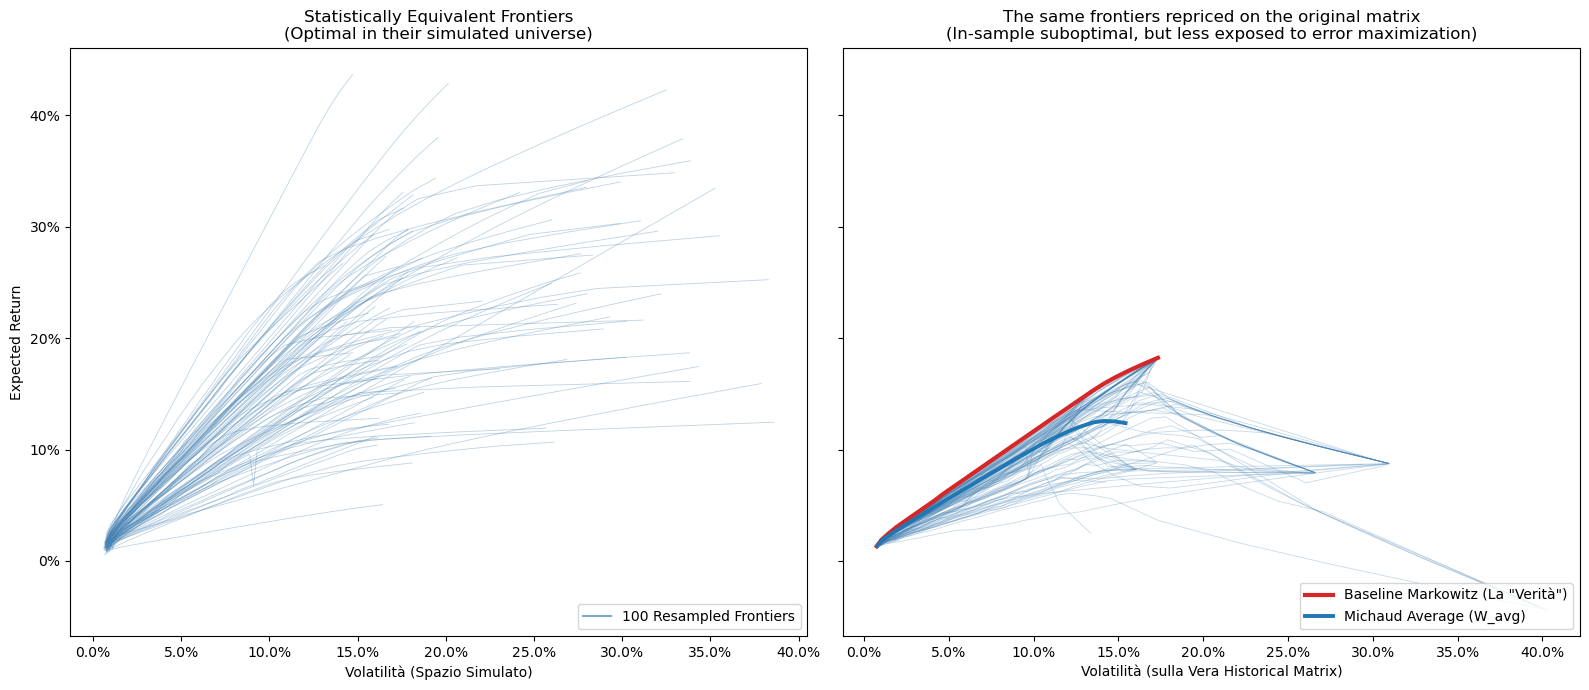

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for b in range(B):
    if mask[b].any():
        v = all_sim_vol[b][mask[b]]
        r = all_sim_ret[b][mask[b]]
        order = np.argsort(v)
        axes[0].plot(v[order], r[order], color='steelblue', lw=0.6, alpha=0.35)
axes[0].plot([], [], color='steelblue', lw=1.5, alpha=0.7, label=f'{B} Resampled Frontiers')
axes[0].set_xlabel('Volatilità (Spazio Simulato)')
axes[0].set_ylabel('Expected Return')
axes[0].set_title('Statistically Equivalent Frontiers\n(Optimal in their simulated universe)')
axes[0].xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
axes[0].legend(loc='lower right')

# RIGHT: in-sample suboptimality, but higher robustness
for b in range(B):
    if mask[b].any():
        v = all_orig_vol[b][mask[b]]
        r = all_orig_ret[b][mask[b]]
        order = np.argsort(v)
        axes[1].plot(v[order], r[order], color='steelblue', lw=0.6, alpha=0.3)
axes[1].plot(vol0, ret0, color='#d62728', lw=3, label='Baseline Markowitz (La "Verità")')
axes[1].plot(vol_avg, ret_avg, color='#1f77b4', lw=2.8, label='Michaud Average (W_avg)')
axes[1].set_xlabel('Volatilità (sulla Vera Historical Matrix)')
axes[1].set_title('The same frontiers repriced on the original matrix\n(In-sample suboptimal, but less exposed to error maximization)')
axes[1].xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()


This cell plots the allocation composition along the averaged Michaud frontier. Since Michaud resampling averages weight vectors rather than expected returns directly, the stacked chart is central for interpretation: it shows whether resampling reduces concentration and produces smoother exposure transitions across the frontier.


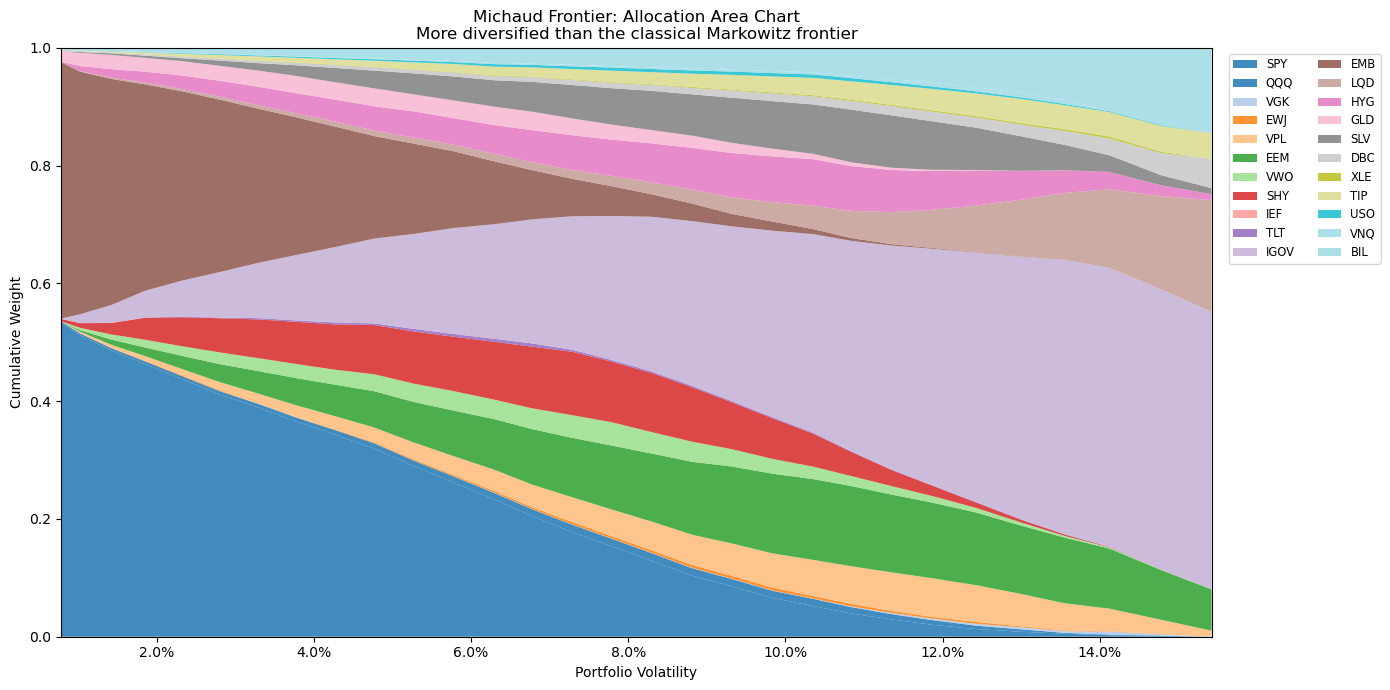

In [35]:
colors = plt.cm.tab20(np.linspace(0, 1, n)) # tab20 permette di distinguere 20+ colori
fig, ax = plt.subplots(figsize=(14, 7))
ax.stackplot(vol_avg, W_avg.T, labels=asset_names, colors=colors, alpha=0.85)
ax.set_xlim(vol_avg.min(), vol_avg.max())
ax.set_ylim(0, 1)
ax.set_xlabel('Portfolio Volatility')
ax.set_ylabel('Cumulative Weight')
ax.set_title('Michaud Frontier: Allocation Area Chart\nMore diversified than the classical Markowitz frontier')
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), ncol=2, fontsize='small')
plt.tight_layout()
plt.show()


This cell runs a half-amplitude resampling variant. Reducing the simulated sample length from $T$ to $T/2$ increases parameter uncertainty. In theory, higher uncertainty should push the averaged Michaud allocation toward broader diversification because extreme simulated optimizer choices cancel out across resamples.



Running the Half-Amplitude variant (higher statistical uncertainty)...
Running 100 Monte Carlo simulations...


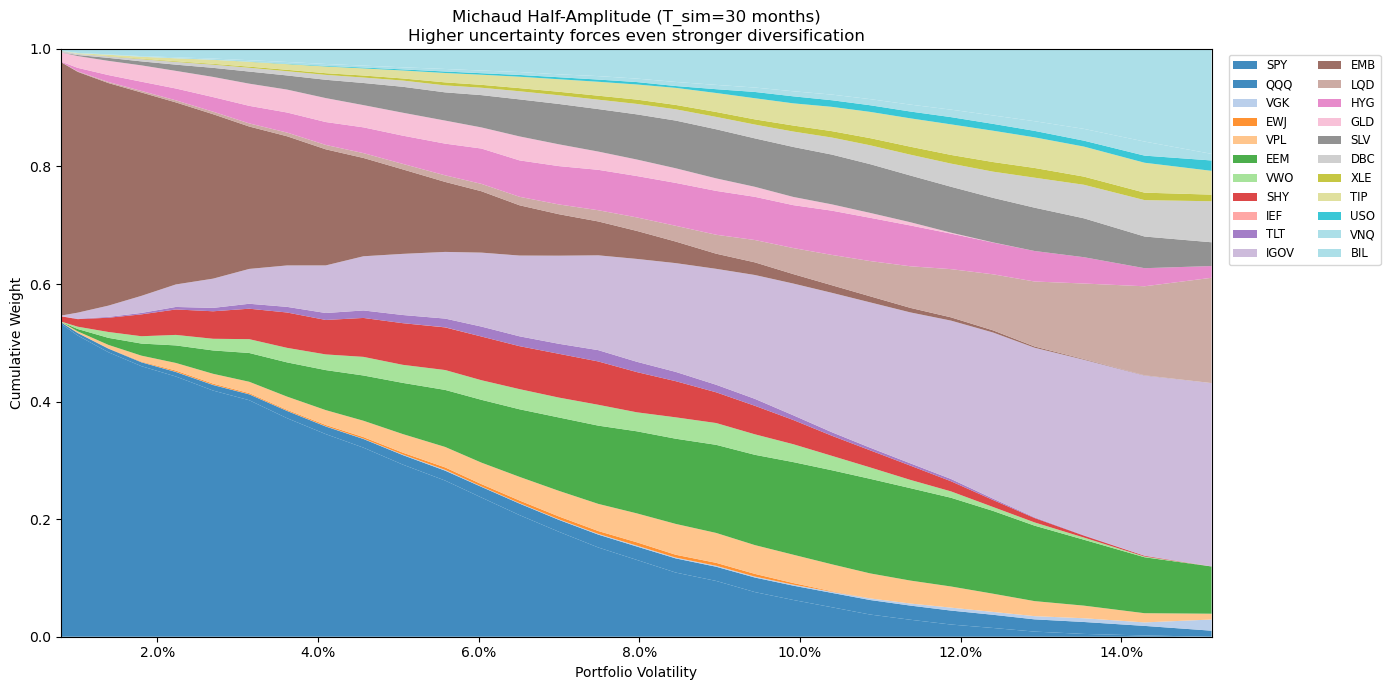

In [36]:
T_half = T // 2
print("\nRunning the Half-Amplitude variant (higher statistical uncertainty)...")
all_W_h, all_sim_vol_h, all_sim_ret_h = run_resampling(B, K, T_half, mu_m, S_m, seed=11)

W_avg_h = aggregate_weights_mean(all_W_h)
vol_avg_h, ret_avg_h, W_avg_h = eval_on_original(W_avg_h, mu_v, S)

fig, ax = plt.subplots(figsize=(14, 7))
ax.stackplot(vol_avg_h, W_avg_h.T, labels=asset_names, colors=colors, alpha=0.85)
ax.set_xlim(vol_avg_h.min(), vol_avg_h.max())
ax.set_ylim(0, 1)
ax.set_xlabel('Portfolio Volatility')
ax.set_ylabel('Cumulative Weight')
ax.set_title("Michaud Half-Amplitude (T_sim=30 months)\nHigher uncertainty forces even stronger diversification")
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), ncol=2, fontsize='small')
plt.tight_layout()
plt.show()


This cell performs a perturbation sensitivity analysis on expected returns. The experiment adds small shocks $\epsilon_i$ to historical expected returns,

$$\mu_i^{perturbed}=\mu_i+\epsilon_i,$$

and rebuilds the frontier. If small shocks cause large changes in weights, the optimizer is amplifying estimation error, which is the core instability highlighted by Michaud.


In [37]:
# ==========================================
# ==========================================

# Assicuriamoci di avere le volatilità singole per i grafici successivi
sigma = ann_volatility.values 

def build_frontier(mu, cov, K_points=30):
    res_mvp = mvp(mu, cov)
    if not res_mvp.success: return [], [], []
    r_min = res_mvp.x @ mu
    r_max = mu.max() * 0.999
    if r_max <= r_min: return [], [], []
    
    targets = np.linspace(r_min, r_max, K_points)
    vols, rets, weights = [], [], []
    
    for t in targets:
        res = min_var_for_target(t, mu, cov)
        if res.success:
            w = res.x
            vols.append(np.sqrt(w @ cov @ w))
            rets.append(w @ mu)
            weights.append(w)
            
    return np.array(vols), np.array(rets), np.array(weights)

# 1. Generating 20 perturbed scenarios
SHOCK_STD = 0.01  # 1% std (il 95% degli shock sarà circa entro il +/- 2%)
np.random.seed(123)
K_PERT = 20
perturbed = []

print(f"Generating {K_PERT} perturbed frontiers...")
for k in range(K_PERT):
    eps = np.zeros(n)
    for i in range(n):
        # Estrazione della magnitudo dell'errore e lancio della moneta per il segno
        mag = abs(np.random.normal(0, SHOCK_STD))
        eps[i] = mag if np.random.random() < 0.5 else -mag
        
    mu_p = mu_v + eps
    v, r, W = build_frontier(mu_p, S, K_points=30)
    
    if len(v) > 0:
        perturbed.append({'k': k, 'eps': eps, 'mu': mu_p, 'vol': v, 'ret': r, 'W': W})

# 2. Quantificazione dell'impatto e ricerca del "Worst Case"
impacts = []
for p in perturbed:
    Wp_interp = np.array([np.interp(vol0, p['vol'], p['W'][:, j]) for j in range(n)]).T
    impacts.append(np.abs(Wp_interp - baseline_W).sum(axis=1).max())

most_idx = int(np.argmax(impacts))
print(f'Successfully computed {len(perturbed)} perturbed frontiers.')
print(f'Highest-impact perturbation: index {most_idx} (max L1 distance = {impacts[most_idx]:.2f})')

n_up = (perturbed[most_idx]["eps"] > 0).sum()
print(f' -> {n_up} POSITIVE shocks (UP) / {n - n_up} NEGATIVE shocks (DOWN)')


Generating 20 perturbed frontiers...
Successfully computed 20 perturbed frontiers.
Highest-impact perturbation: index 0 (max L1 distance = 1.01)
 -> 11 POSITIVE shocks (UP) / 11 NEGATIVE shocks (DOWN)


This cell visualizes the highest-impact perturbation from the sensitivity analysis. The table reports the shocked expected returns, while the frontier and allocation plots show how a small change in input estimates can alter portfolio weights. This directly illustrates the estimation-error amplification problem in classical mean-variance optimization.


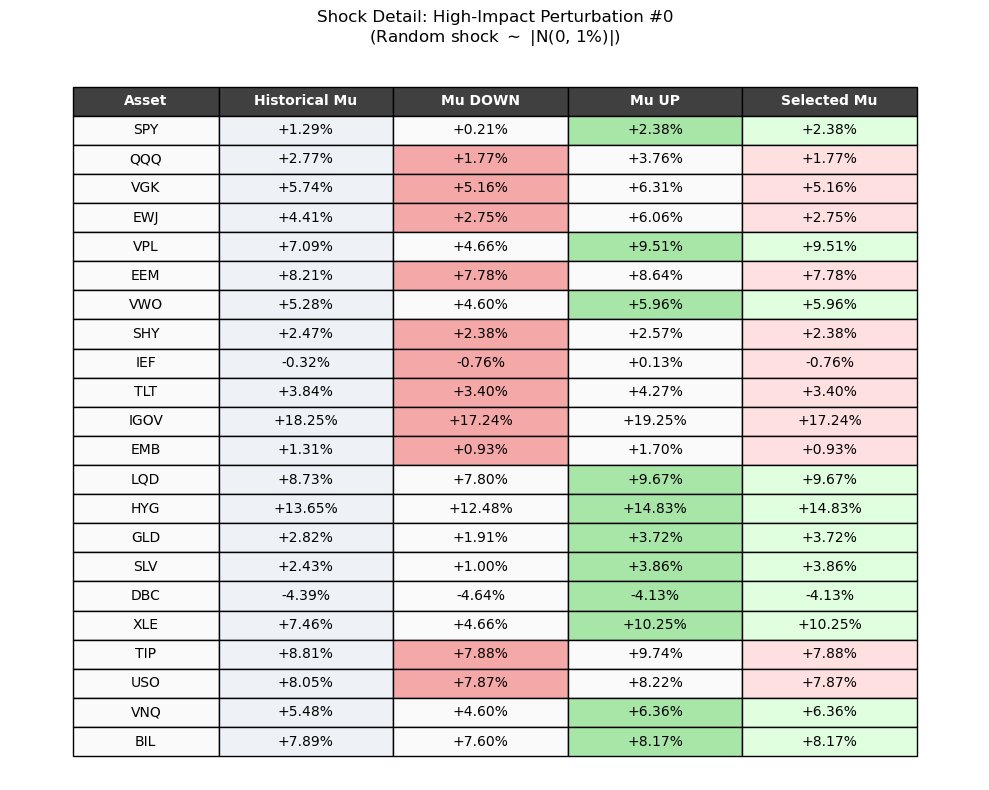

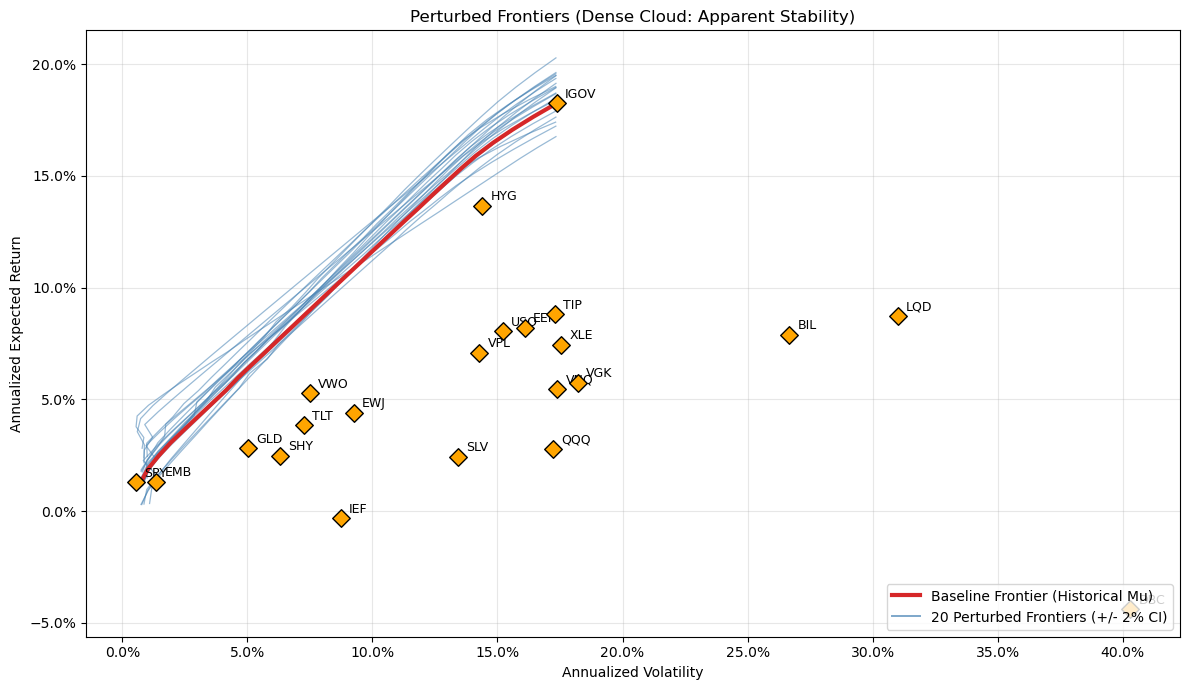

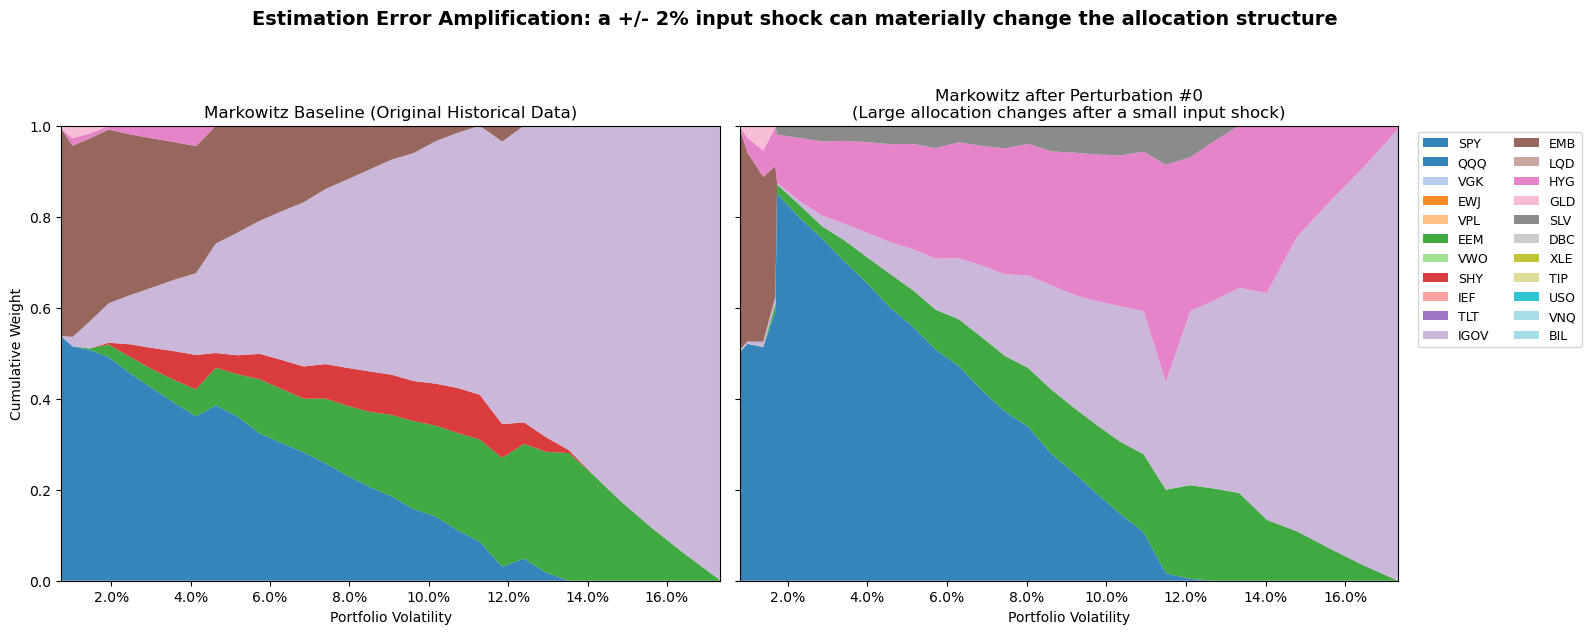

In [38]:
ex = perturbed[most_idx]
mag = np.abs(ex['eps'])
mu_down = mu_v - mag
mu_up   = mu_v + mag
chosen_up = ex['eps'] > 0
mu_chosen = ex['mu']

fig, ax = plt.subplots(figsize=(10, 8)) # Enlarged for the ETF universe
ax.axis('off')
cell_text=[]; cell_colors=[]

for i, name in enumerate(asset_names):
    cell_text.append([name, f'{mu_v[i]*100:+.2f}%', f'{mu_down[i]*100:+.2f}%',
                      f'{mu_up[i]*100:+.2f}%', f'{mu_chosen[i]*100:+.2f}%'])
    if chosen_up[i]:
        rc = ['#fafafa','#eef2f7','#fafafa','#a8e6a8','#dfffdf'] # Green for upward shocks
    else:
        rc = ['#fafafa','#eef2f7','#f5a8a8','#fafafa','#ffe0e0'] # Red for downward shocks
    cell_colors.append(rc)
    
col_labels = ['Asset', 'Historical Mu', 'Mu DOWN', 'Mu UP', 'Selected Mu']
tbl = ax.table(cellText=cell_text, colLabels=col_labels, cellColours=cell_colors,
               loc='center', cellLoc='center', colWidths=[0.15, 0.18, 0.18, 0.18, 0.18])
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.5)

for ci in range(len(col_labels)):
    tbl[(0, ci)].set_text_props(weight='bold', color='white')
    tbl[(0, ci)].set_facecolor('#404040')
    
ax.set_title(f'Shock Detail: High-Impact Perturbation #{most_idx}\n(Random shock $\sim$ |N(0, 1%)|)', pad=15, fontsize=12)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 7))
for p in perturbed:
    ax.plot(p['vol'], p['ret'], color='steelblue', lw=0.9, alpha=0.55)
ax.plot(vol0, ret0, color='#d62728', lw=3, label='Baseline Frontier (Historical Mu)')
ax.plot([], [], color='steelblue', lw=1.4, alpha=0.7,
        label=f'{len(perturbed)} Perturbed Frontiers (+/- 2% CI)')

# Plot individual ETFs
for i, t in enumerate(asset_names):
    ax.scatter(sigma[i], mu_v[i], s=80, marker='D', edgecolor='black', linewidth=1, color='orange', zorder=5)
    ax.annotate(t, xy=(sigma[i], mu_v[i]), xytext=(6, 4), textcoords='offset points', fontsize=9)
    
ax.set_xlabel('Annualized Volatility')
ax.set_ylabel('Annualized Expected Return')
ax.set_title('Perturbed Frontiers (Dense Cloud: Apparent Stability)')
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

colors = plt.cm.tab20(np.linspace(0, 1, n)) # Colors for 22 assets

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

axes[0].stackplot(vol0, baseline_W.T, labels=asset_names, colors=colors, alpha=0.9)
axes[0].set_xlim(vol0.min(), vol0.max()); axes[0].set_ylim(0, 1)
axes[0].set_xlabel('Portfolio Volatility')
axes[0].set_ylabel('Cumulative Weight')
axes[0].set_title('Markowitz Baseline (Original Historical Data)')
axes[0].xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

# Perturbed stackplot (Worst Case)
axes[1].stackplot(ex['vol'], ex['W'].T, labels=asset_names, colors=colors, alpha=0.9)
axes[1].set_xlim(ex['vol'].min(), ex['vol'].max()); axes[1].set_ylim(0, 1)
axes[1].set_xlabel('Portfolio Volatility')
axes[1].set_title(f'Markowitz after Perturbation #{most_idx}\n(Large allocation changes after a small input shock)')
axes[1].xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
axes[1].legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9, ncol=2)

plt.suptitle('Estimation Error Amplification: a +/- 2% input shock can materially change the allocation structure', y=1.05, fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


This cell integrates Michaud into the rolling out-of-sample comparison. For each rolling window, the code computes a resampled frontier and selects the resampled portfolio with the highest Sharpe ratio on the window estimates. The resulting return series is then added to the same `oos_returns` table as Markowitz and the benchmarks.


>>> Running rolling Michaud OOS integration. This is intentionally lighter than the full frontier simulation.
Running 15 Monte Carlo simulations...
Running 15 Monte Carlo simulations...
Running 15 Monte Carlo simulations...
Running 15 Monte Carlo simulations...
Running 15 Monte Carlo simulations...
Running 15 Monte Carlo simulations...
Running 15 Monte Carlo simulations...
Running 15 Monte Carlo simulations...
Running 15 Monte Carlo simulations...
Running 15 Monte Carlo simulations...
Running 15 Monte Carlo simulations...
Running 15 Monte Carlo simulations...
Running 15 Monte Carlo simulations...
Running 15 Monte Carlo simulations...
Running 15 Monte Carlo simulations...
Running 15 Monte Carlo simulations...
Running 15 Monte Carlo simulations...
Running 15 Monte Carlo simulations...
Running 15 Monte Carlo simulations...
Running 15 Monte Carlo simulations...
Running 15 Monte Carlo simulations...
Running 15 Monte Carlo simulations...
Running 15 Monte Carlo simulations...
Running 15 Monte

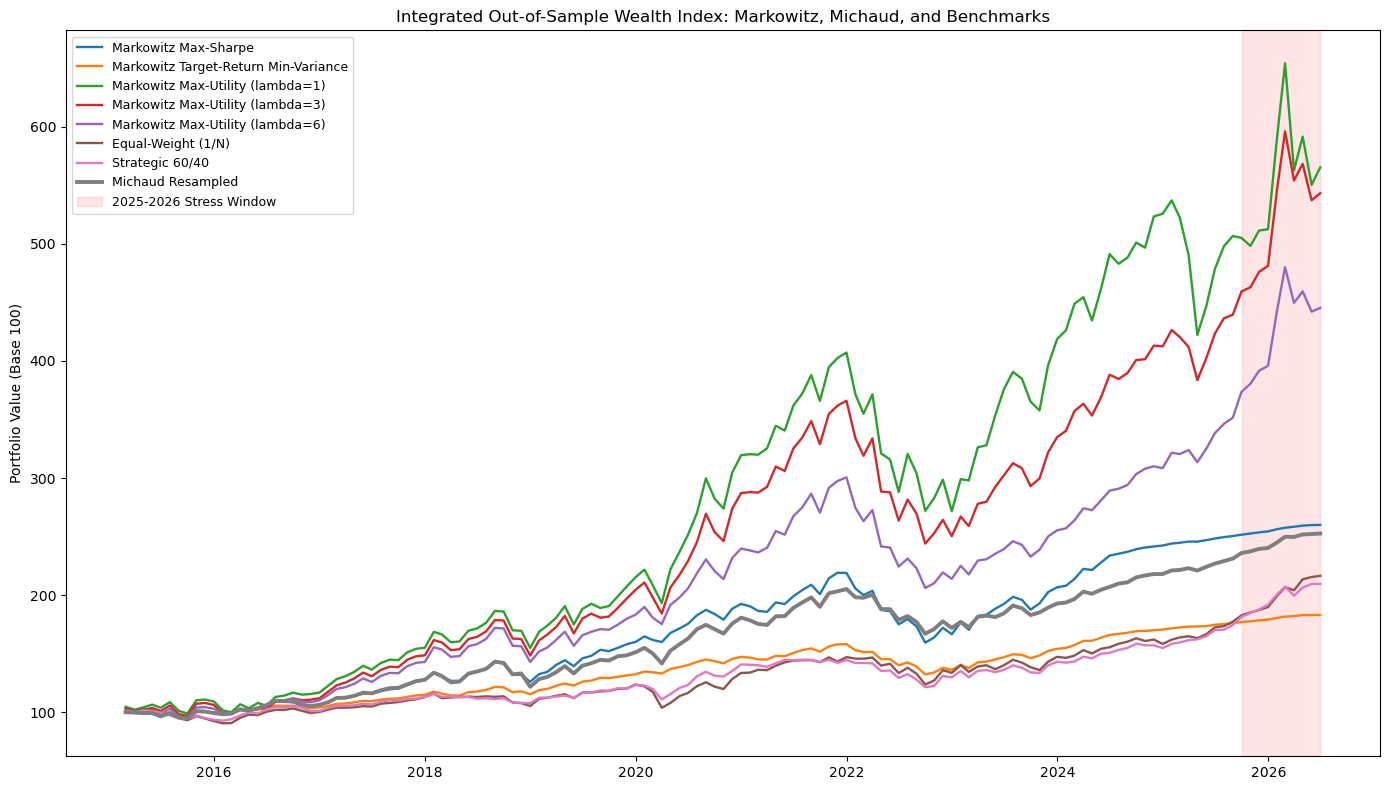


=== INTEGRATED OOS METRICS: MARKOWITZ, MICHAUD, AND BENCHMARKS ===


,CAGR (%),Ann. Volatility (%),Sharpe Ratio,Max Drawdown (%)
Markowitz Max-Sharpe,8.73,9.83,0.68,-27.20
Markowitz Target-Return Min-Variance,5.44,5.14,0.67,-16.39
Markowitz Max-Utility (lambda=1),16.38,19.52,0.74,-33.27
Markowitz Max-Utility (lambda=3),15.98,16.68,0.84,-33.32
Markowitz Max-Utility (lambda=6),13.98,13.88,0.86,-31.41
Equal-Weight (1/N),7.00,9.48,0.53,-16.05
Strategic 60/40,6.70,8.02,0.59,-16.16
Michaud Resampled,8.46,9.41,0.69,-18.58


In [39]:

def get_michaud_max_sharpe_weights(mu_h, cov_h, B_oos=15, K_oos=10, T_sim=60, seed=None):
    """Return one Michaud-resampled max-Sharpe portfolio for a rolling window."""
    mu_m_h = mu_h / MONTHS_PER_YEAR
    cov_m_h = cov_h / MONTHS_PER_YEAR
    W_sim, _, _ = run_resampling(B_oos, K_oos, T_sim, mu_m_h, cov_m_h, seed=seed)
    W_avg_h = aggregate_weights_mean(W_sim)
    vol_h, ret_h, W_avg_h = eval_on_original(W_avg_h, mu_h, cov_h)
    valid = (vol_h > 1e-12) & np.isfinite(vol_h) & np.isfinite(ret_h)
    if not valid.any():
        return np.ones(len(mu_h)) / len(mu_h)
    sharpe_h = (ret_h[valid] - rf_rate) / vol_h[valid]
    return W_avg_h[valid][int(np.nanargmax(sharpe_h))]

print(">>> Running rolling Michaud OOS integration. This is intentionally lighter than the full frontier simulation.")
michaud_rets = []
michaud_weights = []
window = 60
oos_index = returns_df.index[window:]

for step, i in enumerate(range(window, len(returns_df))):
    train_slice = returns_df.iloc[i-window:i]
    realized_simple = np.exp(returns_df.iloc[i].values) - 1
    mu_h = train_slice.mean().values * 12
    cov_h = train_slice.cov().values * 12
    w_mich = get_michaud_max_sharpe_weights(mu_h, cov_h, B_oos=15, K_oos=10, T_sim=window, seed=1000 + step)
    michaud_weights.append(w_mich)
    michaud_rets.append(np.dot(w_mich, realized_simple))

michaud_strategy_returns = pd.Series(michaud_rets, index=oos_index, name='Michaud Resampled')
michaud_historical_weights = pd.DataFrame(michaud_weights, index=oos_index, columns=returns_df.columns)
oos_returns['Michaud Resampled'] = michaud_strategy_returns

combined_wealth = (1 + oos_returns).cumprod() * 100
plt.figure(figsize=(14, 8))
for col in combined_wealth.columns:
    lw = 2.8 if col == 'Michaud Resampled' else 1.7
    plt.plot(combined_wealth.index, combined_wealth[col], label=col, linewidth=lw)
plt.axvspan('2025-10-01', '2026-06-30', color='red', alpha=0.10, label='2025-2026 Stress Window')
plt.title('Integrated Out-of-Sample Wealth Index: Markowitz, Michaud, and Benchmarks')
plt.ylabel('Portfolio Value (Base 100)')
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

metrics_df = calculate_performance_metrics(oos_returns, rf_rate=0.02)
print("\n=== INTEGRATED OOS METRICS: MARKOWITZ, MICHAUD, AND BENCHMARKS ===")
display(metrics_df)


## 6. Black-Litterman Hormuz Extension

The Black-Litterman section is included as the optional extension requested by the assignment. It states the ETF universe, derives equilibrium returns, defines geopolitical views for the Hormuz stress scenario, calibrates tau and Omega, runs a rolling OOS backtest, and visualizes posterior sensitivity.


This cell imports the additional libraries and plotting settings used in the Black-Litterman extension. The Black-Litterman block reuses NumPy, pandas, SciPy optimization, and matrix inversion because the posterior formula depends on linear algebra operations such as $\Sigma^{-1}$ and $\Omega^{-1}$.


In [40]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (13, 7)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

inv    = np.linalg.inv
MONTHS = 12


This cell defines the ETF universe for the Black-Litterman extension, downloads prices, and prepares monthly log returns.


In [41]:
etf_universe = {
    "SPY":  "S&P 500",          "QQQ":  "Nasdaq-100",
    "VGK":  "Europe",            "EWJ":  "Japan",
    "VPL":  "Asia-Pacific",      "EEM":  "MSCI EM",
    "VWO":  "FTSE EM",           "SHY":  "1-3Y Treasury",
    "IEF":  "7-10Y Treasury",    "TLT":  "20+Y Treasury",
    "IGOV": "Intl Treasury",     "EMB":  "EM Bond USD",
    "LQD":  "IG Corporate",      "HYG":  "High Yield",
    "GLD":  "Gold",              "SLV":  "Silver",
    "DBC":  "Broad Commodity",   "XLE":  "Energy Equity",
    "TIP":  "TIPS",              "VNQ":  "US REIT",
    "BIL":  "T-Bill (Risk-Free)","USO":  "Oil"
}
tickers = list(etf_universe.keys())
n       = len(tickers)
idx     = {t: i for i, t in enumerate(tickers)}  # ticker -> colonna

print("Downloading data...")
prices_daily = yf.download(tickers, start="2010-01-01", auto_adjust=True, progress=False)["Close"]
prices_daily = prices_daily[tickers].dropna(how="all")

prices_m = prices_daily.resample('ME').last().dropna()
rets_m   = np.log(prices_m / prices_m.shift(1)).dropna()

print(f"Period: {rets_m.index[0].date()} → {rets_m.index[-1].date()}")
print(f"Monthly observations: {len(rets_m)} | ETF: {n}")
print(f"Total missing values: {rets_m.isna().sum().sum()}")


Period: 2010-02-28 → 2026-06-30
Monthly observations: 197 | ETF: 22
Total missing values: 0


This cell computes the historical moments used in the Black-Litterman extension. The sample expected return and covariance matrix are estimated as

$$\hat{\mu}=12\bar{r}, \qquad \hat{\Sigma}=12\operatorname{Cov}(r).$$

These estimates are used both for diagnostics and for comparing the classical historical-return frontier with the Black-Litterman posterior frontier.


,Description,Annual Return,Annual Volatility,Sharpe (rf=4%)
QQQ,Nasdaq-100,18.27%,17.36%,0.822
SPY,S&P 500,13.65%,14.38%,0.671
VNQ,US REIT,8.83%,17.29%,0.279
VPL,Asia-Pacific,8.07%,15.20%,0.268
GLD,Gold,8.22%,16.08%,0.263
EWJ,Japan,7.09%,14.28%,0.216
VGK,Europe,7.45%,17.55%,0.196
HYG,High Yield,5.28%,7.49%,0.171
SLV,Silver,8.74%,31.01%,0.153
XLE,Energy Equity,7.93%,26.68%,0.147


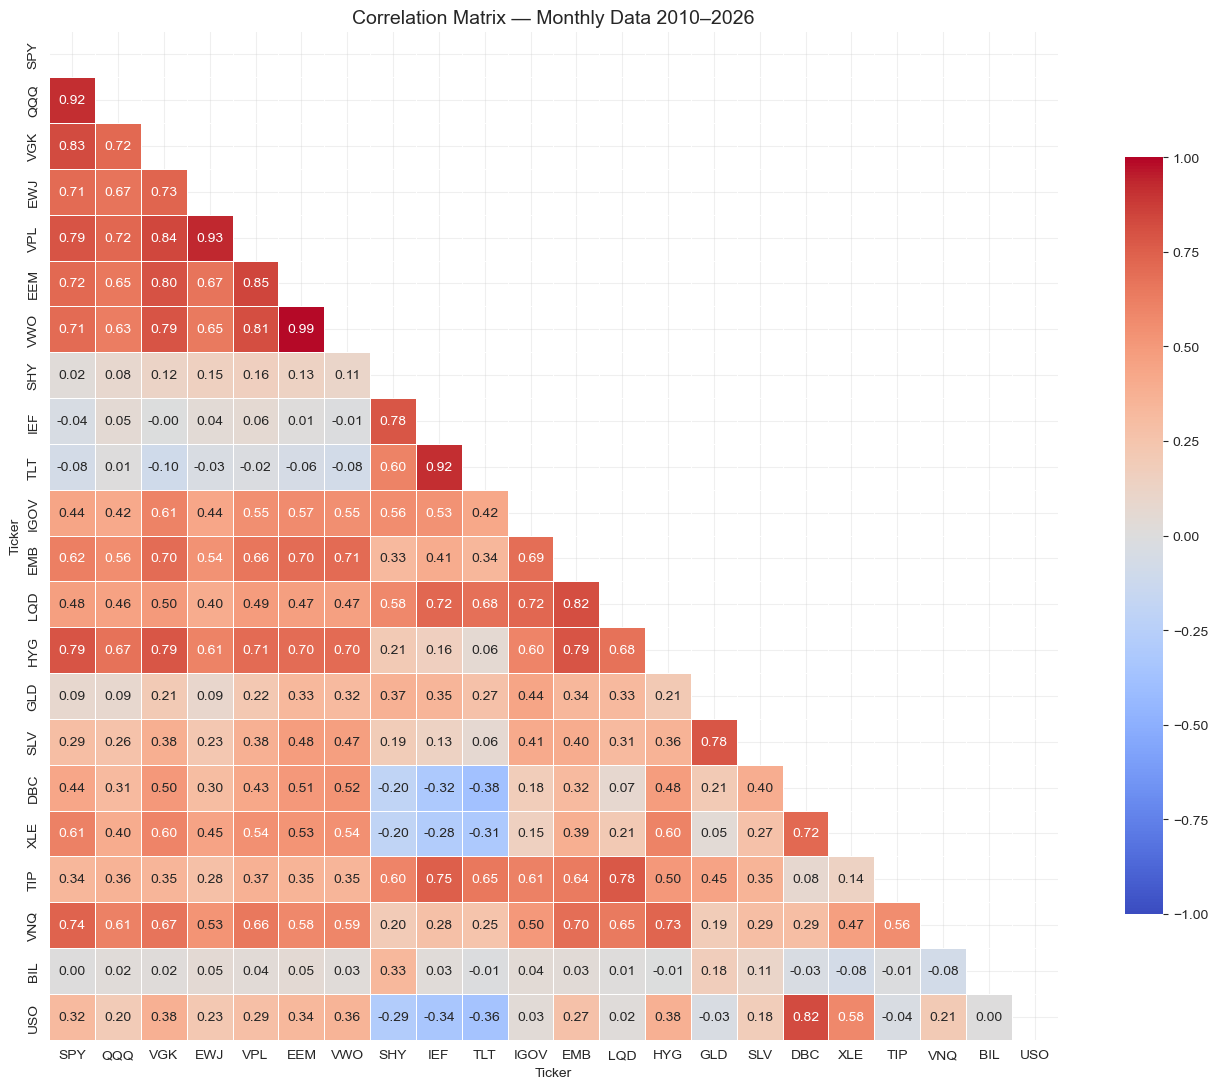

In [42]:
rf_annual = 0.04   # 4% approximate 2026 Fed Funds rate
rf_m      = rf_annual / MONTHS

mu_hist = rets_m.mean().values * MONTHS
Sigma   = rets_m.cov().values  * MONTHS          # annualized sample covariance
sigma_v = np.sqrt(np.diag(Sigma))
sharpe_v = (mu_hist - rf_annual) / sigma_v

stats_df = pd.DataFrame({
    'Description':     list(etf_universe.values()),
    'Annual Return': mu_hist * 100,
    'Annual Volatility': sigma_v  * 100,
    'Sharpe (rf=4%)':  sharpe_v,
}, index=tickers).sort_values('Sharpe (rf=4%)', ascending=False)

stats_df['Annual Return'] = stats_df['Annual Return'].map('{:.2f}%'.format)
stats_df['Annual Volatility'] = stats_df['Annual Volatility'].map('{:.2f}%'.format)
stats_df['Sharpe (rf=4%)']  = stats_df['Sharpe (rf=4%)'].map('{:.3f}'.format)
display(stats_df)

# Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 11))
corr_m  = rets_m.corr()
mask    = np.triu(np.ones_like(corr_m, dtype=bool))
sns.heatmap(corr_m, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=.5,
            cbar_kws={"shrink": .75}, ax=ax)
ax.set_title("Correlation Matrix — Monthly Data 2010–2026", fontsize=14)
plt.tight_layout()
plt.show()


This cell derives implied equilibrium returns from market-cap proxy weights. Black-Litterman starts from a market-equilibrium prior:

$$\Pi = \delta \Sigma w_m,$$

where $w_m$ is the market portfolio proxy and $\delta$ is the risk-aversion coefficient. This prior is less noisy than raw historical means and becomes the anchor for subjective views.


Market portfolio (AUM proxy):
  Expected return  = 10.98%
  Volatilità         = 11.53%
  Sharpe ratio       = 0.606
  Risk aversion delta = 5.254
  (He & Litterman 1999 use delta around 2.5 for an equity-only universe)


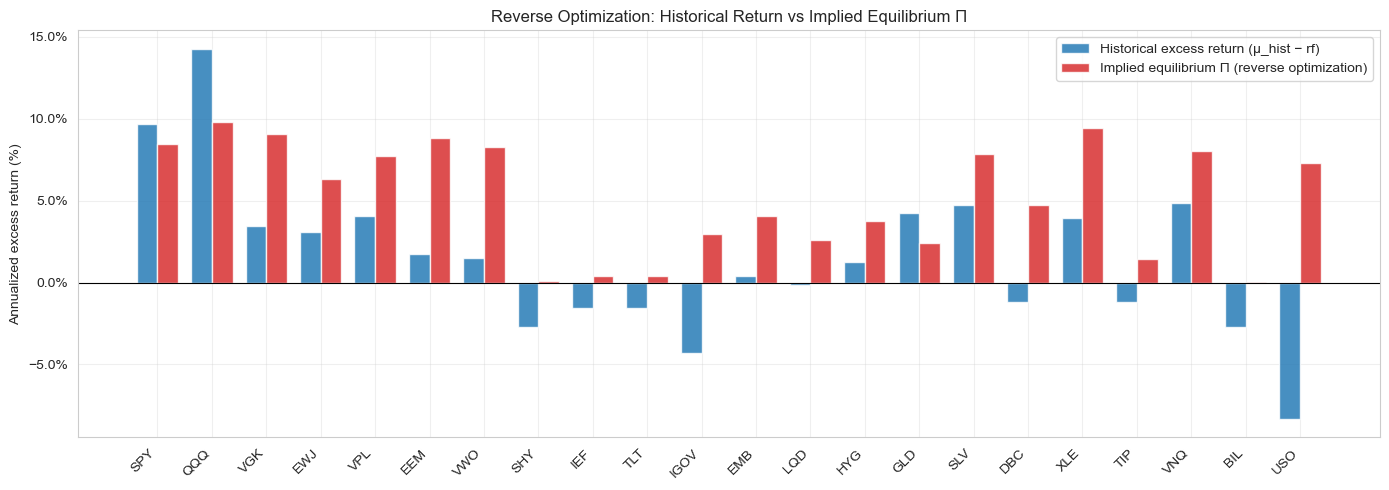

In [43]:
# AUM approssimativo (miliardi USD, inizio 2026) — proxy market cap
aum = pd.Series({
    "SPY":530, "QQQ":290, "VGK":25,  "EWJ":12,  "VPL":6,
    "EEM":26,  "VWO":80,  "SHY":30,  "IEF":35,  "TLT":54,
    "IGOV":5,  "EMB":18,  "LQD":35,  "HYG":16,  "GLD":67,
    "SLV":14,  "DBC":5,   "XLE":34,  "TIP":55,  "VNQ":33,
    "BIL":35,  "USO":1
}).reindex(tickers)
w_eq = (aum / aum.sum()).values

# Delta endogeno (Drobetz 2001 — come nel notebook del professore)
mu_m_port  = w_eq @ mu_hist
var_m_port = w_eq @ Sigma @ w_eq
delta      = (mu_m_port - rf_annual) / var_m_port

# Prior: ritorni impliciti di equilibrium (excess returns)
Pi = delta * Sigma @ w_eq

print(f"Market portfolio (AUM proxy):")
print(f"  Expected return  = {mu_m_port:.2%}")
print(f"  Volatilità         = {np.sqrt(var_m_port):.2%}")
print(f"  Sharpe ratio       = {(mu_m_port-rf_annual)/np.sqrt(var_m_port):.3f}")
print(f"  Risk aversion delta = {delta:.3f}")
print("  (He & Litterman 1999 use delta around 2.5 for an equity-only universe)")

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(n); w = 0.38
ax.bar(x - w/2, (mu_hist - rf_annual)*100, w,
       label='Historical excess return (μ_hist − rf)', color='#1f77b4', alpha=0.82)
ax.bar(x + w/2, Pi*100, w,
       label='Implied equilibrium Π (reverse optimization)', color='#d62728', alpha=0.82)
ax.set_xticks(x); ax.set_xticklabels(tickers, rotation=45, ha='right')
ax.set_ylabel('Annualized excess return (%)')
ax.set_title('Reverse Optimization: Historical Return vs Implied Equilibrium Π')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.axhline(0, color='black', lw=0.8)
ax.legend()
plt.tight_layout()
plt.show()


This cell defines the Black-Litterman views through matrix $P$ and vector $Q$. Each view is written as a linear statement about expected excess returns:

$$P\mu = Q.$$

Relative views compare assets, such as oil outperforming equities, while absolute views assign an expected excess return directly to one asset or sector.


In [44]:
K = 4
P = np.zeros((K, n))

P[0, idx['USO']] =  1.0
P[0, idx['SPY']] = -1.0

P[1, idx['GLD']] =  1.0
P[1, idx['EEM']] = -1.0

P[2, idx['XLE']] =  1.0

P[3, idx['SPY']] =  1.0
P[3, idx['VGK']] = -1.0

Q = np.array([0.12, 0.09, 0.12, 0.04])   # annualizzato

view_labels = [
    'View 1 — USO − SPY  (+12% a.)  [Relative]',
    'View 2 — GLD − EEM  (+9% a.)   [Relative]',
    'View 3 — XLE abs    (+12% a.)  [Absolute]',
    'View 4 — SPY − VGK  (+4% a.)   [Relative]',
]

P_df = pd.DataFrame(P, index=view_labels, columns=tickers)
print("P matrix (non-zero columns):")
display(P_df.loc[:, (P_df != 0).any()])
print(f"\nQ vector: {Q}")


P matrix (non-zero columns):


,SPY,VGK,EEM,GLD,XLE,USO
View 1 — USO − SPY (+12% a.) [Relative],-1.0,0.0,0.0,0.0,0.0,1.0
View 2 — GLD − EEM (+9% a.) [Relative],0.0,0.0,-1.0,1.0,0.0,0.0
View 3 — XLE abs (+12% a.) [Absolute],0.0,0.0,0.0,0.0,1.0,0.0
View 4 — SPY − VGK (+4% a.) [Relative],1.0,-1.0,0.0,0.0,0.0,0.0



Q vector: [0.12 0.09 0.12 0.04]


This cell calibrates the Black-Litterman uncertainty parameters. The scalar $\tau$ controls uncertainty around the prior covariance, while $\Omega$ controls uncertainty around the views. The He-Litterman diagonal specification is

$$\Omega = \operatorname{diag}\left(P(\tau\Sigma)P^T\right).$$

A smaller $\Omega$ means higher confidence in the views; a larger $\Omega$ means the posterior stays closer to the equilibrium prior.


In [45]:
tau   = 0.025
Omega = np.diag(np.diag(P @ (tau * Sigma) @ P.T))   # He-Litterman

print(f"τ = {tau}  (baseline Drobetz 2001 / He & Litterman 1999)")
print("\nOmega - uncertainty for each view:")
for i, lbl in enumerate(view_labels):
    o = Omega[i, i]
    print(f"  {lbl}")
    print(f"    ω_ii = {o:.6f}  →  σ_view = {np.sqrt(o)*100:.2f}% annualized")


τ = 0.025  (baseline Drobetz 2001 / He & Litterman 1999)

Omega - uncertainty for each view:
  View 1 — USO − SPY  (+12% a.)  [Relative]
    ω_ii = 0.003660  →  σ_view = 6.05% annualized
  View 2 — GLD − EEM  (+9% a.)   [Relative]
    ω_ii = 0.000994  →  σ_view = 3.15% annualized
  View 3 — XLE abs    (+12% a.)  [Absolute]
    ω_ii = 0.001780  →  σ_view = 4.22% annualized
  View 4 — SPY − VGK  (+4% a.)   [Relative]
    ω_ii = 0.000243  →  σ_view = 1.56% annualized


This cell computes the Black-Litterman posterior. The posterior expected excess return is

$$\mu_{BL}=\left[(\tau\Sigma)^{-1}+P^T\Omega^{-1}P\right]^{-1}\left[(\tau\Sigma)^{-1}\Pi+P^T\Omega^{-1}Q\right].$$

The posterior combines the equilibrium prior $\Pi$ with the view portfolio $P\mu=Q$, weighted by their respective uncertainty matrices.


✓ Both formulations match (numerical check passed).


,Prior Π,Posterior μ_BL,Shift BL − Π,Historical mu_hist
SPY,+8.47%,+5.91%,-2.55%,+13.65%
QQQ,+9.81%,+6.71%,-3.10%,+18.27%
VGK,+9.05%,+4.22%,-4.84%,+7.45%
EWJ,+6.31%,+2.94%,-3.37%,+7.09%
VPL,+7.73%,+3.82%,-3.91%,+8.07%
EEM,+8.83%,+3.86%,-4.98%,+5.75%
VWO,+8.31%,+3.67%,-4.63%,+5.48%
SHY,+0.12%,+0.04%,-0.08%,+1.32%
IEF,+0.39%,+0.36%,-0.03%,+2.47%
TLT,+0.38%,+0.60%,+0.22%,+2.43%


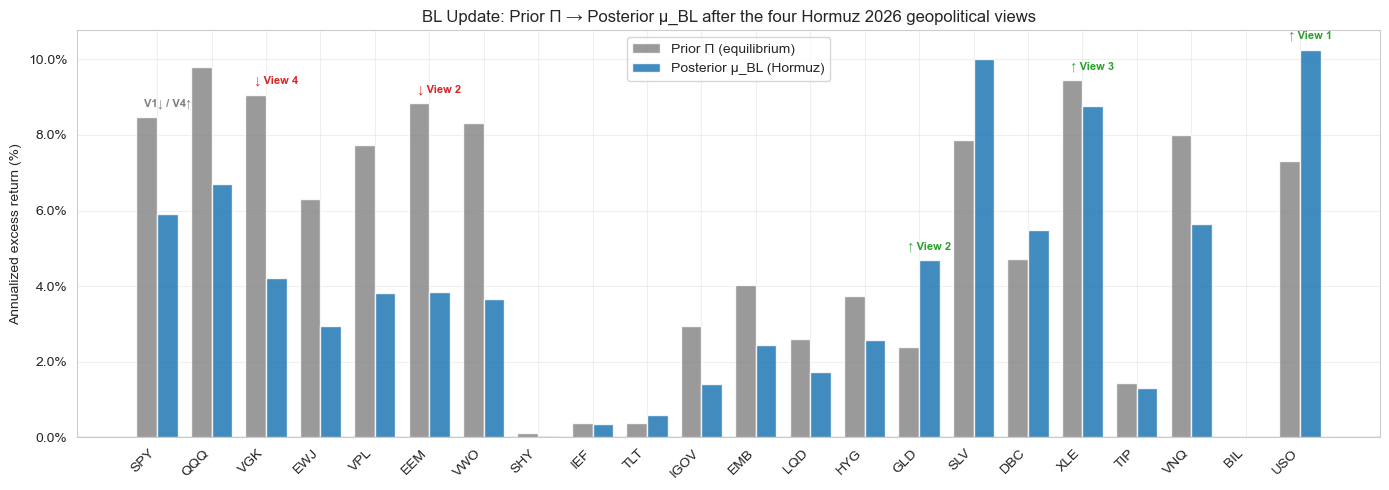

In [46]:
def bl_posterior(Pi, Sigma, P, Q, Omega, tau):
    """
    Compute the Black-Litterman posterior.
    Implementation following Drobetz (2001) and He & Litterman (1999).
    Check the equivalence between the direct formula and the shortcut formula.

    Returns
    -------
    mu_BL    : array (n,)   — posterior excess returns
    Sigma_BL : array (n,n)  — posterior covariance (Sigma + M)
    M        : array (n,n)  — variance of the mean-return parameter
    """
    tSig = tau * Sigma
    M        = inv(inv(tSig) + P.T @ inv(Omega) @ P)
    mu_dir   = M @ (inv(tSig) @ Pi + P.T @ inv(Omega) @ Q)
    # He-Litterman shortcut
    mu_short = Pi + tSig @ P.T @ inv(P @ tSig @ P.T + Omega) @ (Q - P @ Pi)
    assert np.allclose(mu_dir, mu_short, atol=1e-9), \
        "ERROR: the two formulations do not match!"
    return mu_dir, Sigma + M, M


mu_BL, Sigma_BL, M = bl_posterior(Pi, Sigma, P, Q, Omega, tau)
print("✓ Both formulations match (numerical check passed).")

# Comparison table
df_bl = pd.DataFrame({
    'Prior Π':           [f"{x*100:+.2f}%" for x in Pi],
    'Posterior μ_BL':    [f"{x*100:+.2f}%" for x in mu_BL],
    'Shift BL − Π':      [f"{(b-p)*100:+.2f}%" for p, b in zip(Pi, mu_BL)],
    'Historical mu_hist':    [f"{x*100:+.2f}%" for x in mu_hist],
}, index=tickers)
display(df_bl)

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(n); w = 0.38
ax.bar(x - w/2, Pi*100,    w, label='Prior Π (equilibrium)',      color='#888888', alpha=0.85)
ax.bar(x + w/2, mu_BL*100, w, label='Posterior μ_BL (Hormuz)',   color='#1f77b4', alpha=0.85)

view_impact = {
    'USO': ('↑ View 1', '#2ca02c'), 
    'SPY': ('V1↓ / V4↑', '#7f7f7f'),
    'GLD': ('↑ View 2', '#2ca02c'), 
    'EEM': ('↓ View 2', '#d62728'),
    'XLE': ('↑ View 3', '#2ca02c'),
    'VGK': ('↓ View 4', '#d62728')
}

for tkr, (lbl, col) in view_impact.items():
    i = idx[tkr]
    ypos = max(abs(Pi[i]), abs(mu_BL[i]))*100 + 0.3
    ax.text(i + w/2, ypos, lbl, ha='center', fontsize=8, color=col, weight='bold')

ax.set_xticks(x); ax.set_xticklabels(tickers, rotation=45, ha='right')
ax.set_ylabel('Annualized excess return (%)')
ax.set_title('BL Update: Prior Π → Posterior μ_BL after the four Hormuz 2026 geopolitical views')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.axhline(0, color='black', lw=0.8)
ax.legend()
plt.tight_layout()
plt.show()


This cell defines the Black-Litterman portfolio optimizer and the view activation logic. Once posterior returns are available, the allocation is selected by a capped long-only Max-Sharpe problem:

$$\max_w \frac{w^T\mu_{BL}}{\sqrt{w^T\Sigma_{BL}w}}, \qquad \sum_i w_i=1, \quad 0\le w_i\le w_{max}.$$

The Hormuz views are active only during the specified stress window; outside that window, the model falls back to the equilibrium prior.


In [47]:
# ── Funzione Max Sharpe (long-only, cap per asset) ──
def max_sharpe_opt(mu_excess, Sig, w_max=0.30):
    """
    Optimize the long-only maximum Sharpe portfolio.
    mu_excess: excess returns annualizzati (Π o μ_BL, without the risk-free rate)
    Fallback: 1/N if the optimizer does not converge.
    """
    n_a = len(mu_excess)
    w0  = np.ones(n_a) / n_a

    def neg_sharpe(w):
        vol = np.sqrt(w @ Sig @ w)
        return -(w @ mu_excess / vol) if vol > 1e-12 else 1e6

    res = minimize(
        neg_sharpe, w0, method='SLSQP',
        bounds=[(0.0, w_max)] * n_a,
        constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}],
        options={'ftol': 1e-10, 'maxiter': 1000}
    )
    if res.success:
        w = np.clip(res.x, 0, None)
        return w / w.sum()
    return w0   # fallback 1/N


HORMUZ_START = pd.Timestamp("2026-01-31")
HORMUZ_END   = pd.Timestamp("2026-04-30")

def get_views_for_date(rebal_date):
    """Return (P, Q) if the month falls in the Hormuz period, otherwise (None, None)."""
    if HORMUZ_START <= rebal_date <= HORMUZ_END:
        return P, Q
    return None, None


def compute_bl_weights(rets_window, rebal_date, w_eq,
                       tau=0.025, rf=0.04, w_max=0.30):
    """
    Compute optimal BL weights on the rolling window.
    Se nessuna view è attiva, ottimizza sul prior puro Π.
    """
    mu_w  = rets_window.mean().values * MONTHS
    Sig_w = rets_window.cov().values  * MONTHS

    var_mw = w_eq @ Sig_w @ w_eq
    if var_mw < 1e-12:
        return np.ones(n) / n
    d_w   = (w_eq @ mu_w - rf) / var_mw
    Pi_w  = d_w * Sig_w @ w_eq

    Pv, Qv = get_views_for_date(rebal_date)

    if Pv is None:
        return max_sharpe_opt(Pi_w, Sig_w, w_max)

    Om_w = np.diag(np.diag(Pv @ (tau * Sig_w) @ Pv.T))
    try:
        mu_bl_w, Sig_bl_w, _ = bl_posterior(Pi_w, Sig_w, Pv, Qv, Om_w, tau)
        return max_sharpe_opt(mu_bl_w, Sig_bl_w, w_max)
    except np.linalg.LinAlgError:
        return max_sharpe_opt(Pi_w, Sig_w, w_max)


This cell runs the rolling Black-Litterman out-of-sample backtest. For each monthly date, the model recomputes the prior and posterior using only the rolling window, optimizes weights, and applies them to the next realized return. This keeps the Black-Litterman extension comparable with the Markowitz and Michaud rolling tests.


In [48]:
WINDOW = 60
W_MAX  = 0.30

dates_idx   = rets_m.index
rebal_dates = dates_idx[WINDOW:]

bl_wh, bench_wh     = [], []
bl_r_list, bench_r_list = [], []
vflags = []

print(f"Backtest: {rebal_dates[0].date()} → {rebal_dates[-1].date()}")
print(f"Step out-of-sample: {min(len(rebal_dates), len(rets_m)-WINDOW)}")

for i, rd in enumerate(rebal_dates):
    if i + WINDOW >= len(rets_m):
        break
    win    = rets_m.iloc[i : i + WINDOW]
    w_bl   = compute_bl_weights(win, rd, w_eq, tau=tau, rf=rf_annual, w_max=W_MAX)
    w_1n   = np.ones(n) / n
    nr     = rets_m.iloc[i + WINDOW].values

    bl_r_list.append(w_bl @ nr)
    bench_r_list.append(w_1n @ nr)
    bl_wh.append(w_bl)
    bench_wh.append(w_1n)
    vflags.append(get_views_for_date(rd)[0] is not None)

actual_dates = rebal_dates[:len(bl_r_list)]
bl_ret_s     = pd.Series(bl_r_list,    index=actual_dates, name='BL Hormuz')
bench_ret_s  = pd.Series(bench_r_list, index=actual_dates, name='1/N Benchmark')
view_flags   = pd.Series(vflags,       index=actual_dates, name='Hormuz Active')
bl_w_df      = pd.DataFrame(bl_wh,    index=actual_dates, columns=tickers)
bench_w_df   = pd.DataFrame(bench_wh, index=actual_dates, columns=tickers)

print(f"\nBacktest completed: {len(bl_ret_s)} OOS months")
if view_flags.any():
    print(f"Active Hormuz views: {view_flags.sum()} months -> {list(actual_dates[view_flags.values].date)}")
else:
    print("Hormuz views: not yet in the OOS sample (2026 period not reached).")
    print("The views will activate automatically once the sample covers Feb-Apr 2026.")


Backtest: 2015-02-28 → 2026-06-30
Step out-of-sample: 137

Backtest completed: 137 OOS months
Active Hormuz views: 4 months -> [datetime.date(2026, 1, 31), datetime.date(2026, 2, 28), datetime.date(2026, 3, 31), datetime.date(2026, 4, 30)]


This cell calculates Black-Litterman performance metrics. In addition to return, volatility, Sharpe ratio, drawdown, Calmar ratio, and turnover, it includes the Sortino ratio:

$$Sortino=\frac{R_p-r_f}{\sigma_{downside}},$$

where downside volatility is computed only from negative excess-return observations. This penalizes harmful volatility more directly than the Sharpe ratio.


In [49]:
def calculate_kpis(ret_series, w_df, model_name="Model", rf_annual=0.04):
    """
    Out-of-sample metrics compatible with calculate_kpis from trio_models.
    Addition: Sortino Ratio.
    """
    rf_m     = rf_annual / MONTHS
    ann_ret  = ret_series.mean() * MONTHS
    ann_vol  = ret_series.std()  * np.sqrt(MONTHS)
    sharpe   = (ann_ret - rf_annual) / ann_vol if ann_vol > 0 else 0

    exc_m    = ret_series - rf_m
    downside = exc_m[exc_m < 0].std() * np.sqrt(MONTHS)
    sortino  = (ann_ret - rf_annual) / downside if downside > 0 else 0

    cum  = np.exp(ret_series.cumsum())
    mdd  = ((cum / cum.cummax()) - 1).min()
    calmar = ann_ret / abs(mdd) if mdd != 0 else 0

    turnover = w_df.diff().abs().sum(axis=1).mean() * MONTHS

    return pd.Series({
        'Annual Return':  f"{ann_ret*100:.2f}%",
        'Annual Volatility':  f"{ann_vol*100:.2f}%",
        'Sharpe Ratio':     f"{sharpe:.3f}",
        'Sortino Ratio':    f"{sortino:.3f}",
        'Max Drawdown':     f"{mdd*100:.2f}%",
        'Calmar Ratio':     f"{calmar:.3f}",
        'Annual Turnover':   f"{turnover*100:.2f}%",
    }, name=model_name)


kpi_bl    = calculate_kpis(bl_ret_s,    bl_w_df,    'BL Hormuz')
kpi_bench = calculate_kpis(bench_ret_s, bench_w_df, '1/N Benchmark')

kpi_table = pd.DataFrame([kpi_bl, kpi_bench]).T
print("Out-of-Sample Performance Table")
display(kpi_table)


Out-of-Sample Performance Table


,BL Hormuz,1/N Benchmark
Annual Return,10.57%,5.72%
Annual Volatility,10.01%,9.67%
Sharpe Ratio,0.657,0.178
Sortino Ratio,0.896,0.217
Max Drawdown,-18.97%,-17.49%
Calmar Ratio,0.557,0.327
Annual Turnover,42.46%,0.00%


This cell plots Black-Litterman wealth and drawdown. Wealth is computed from cumulative log returns as $W_t=\exp(\sum_s r_s)$, while drawdown is $DD_t=W_t/\max_{s\le t}W_s-1$. The two panels show both growth and capital-loss risk.


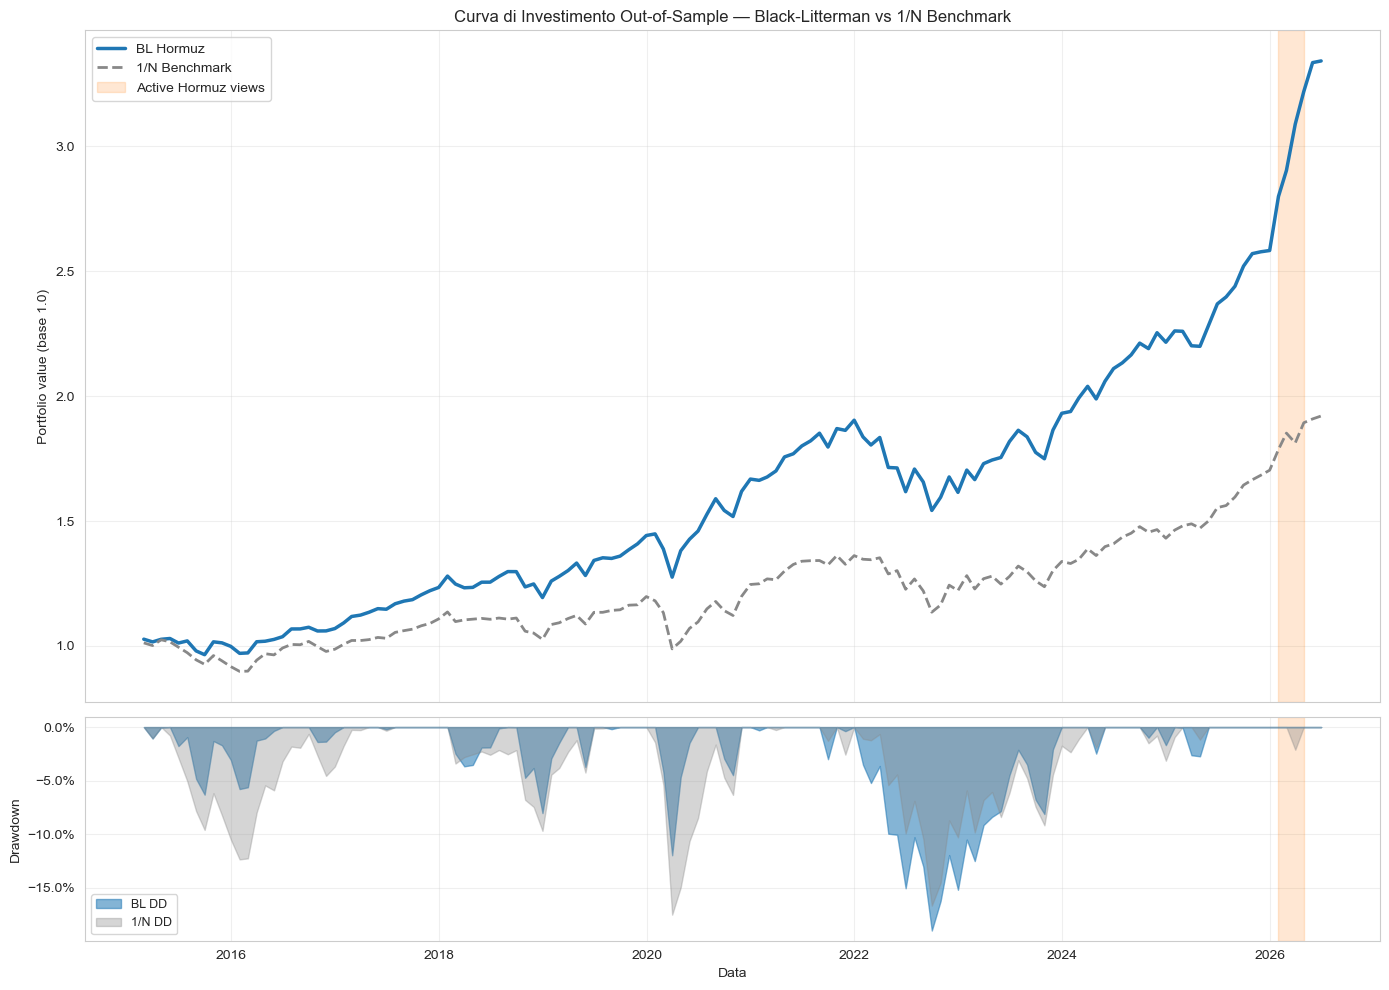

In [50]:
cum_bl    = np.exp(bl_ret_s.cumsum())
cum_bench = np.exp(bench_ret_s.cumsum())
dd_bl     = (cum_bl    / cum_bl.cummax())    - 1
dd_bench  = (cum_bench / cum_bench.cummax()) - 1

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})

# Wealth curve
axes[0].plot(cum_bl,    lw=2.5, color='#1f77b4', label='BL Hormuz')
axes[0].plot(cum_bench, lw=2.0, color='#888',    linestyle='--', label='1/N Benchmark')

if view_flags.any():
    axes[0].axvspan(HORMUZ_START, HORMUZ_END,
                    color='#ff7f0e', alpha=0.18, label='Active Hormuz views')
    axes[1].axvspan(HORMUZ_START, HORMUZ_END, color='#ff7f0e', alpha=0.18)

axes[0].set_ylabel('Portfolio value (base 1.0)')
axes[0].set_title('Curva di Investimento Out-of-Sample — Black-Litterman vs 1/N Benchmark')
axes[0].legend()

# Drawdown
axes[1].fill_between(dd_bl.index,    dd_bl,    0, color='#1f77b4', alpha=0.55, label='BL DD')
axes[1].fill_between(dd_bench.index, dd_bench, 0, color='#888',    alpha=0.35, label='1/N DD')
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('Data')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


This cell groups Black-Litterman weights into macro asset classes. Aggregating weights improves interpretability because the model operates on many ETFs, but the economic story is often about shifts between equities, bonds, credit, real assets, and cash.


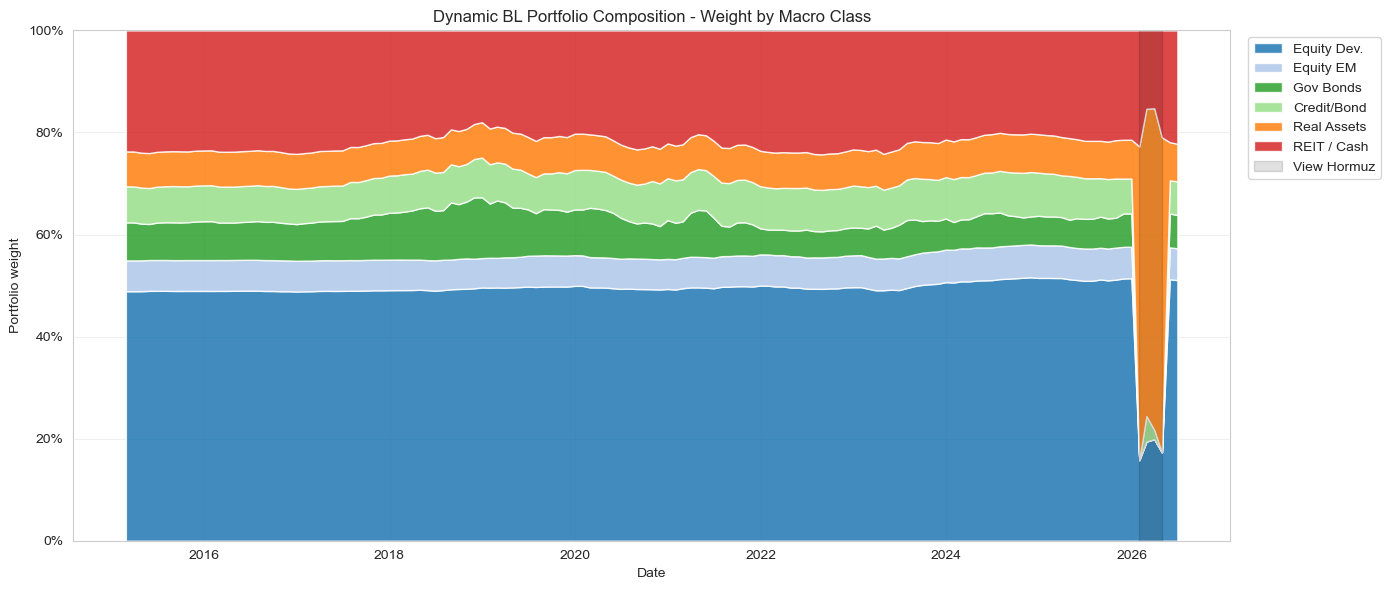

In [51]:
# Raggruppa in macro classi per leggibilità
macro_classes = {
    'Equity Dev.':  ['SPY', 'QQQ', 'VGK', 'EWJ', 'VPL'],
    'Equity EM':    ['EEM', 'VWO'],
    'Gov Bonds':    ['SHY', 'IEF', 'TLT', 'IGOV'],
    'Credit/Bond':  ['EMB', 'LQD', 'HYG', 'TIP'],
    'Real Assets':  ['GLD', 'SLV', 'DBC', 'XLE', 'USO'],
    'REIT / Cash':  ['VNQ', 'BIL'],
}
colors_macro = ['#1f77b4', '#aec7e8', '#2ca02c', '#98df8a', '#ff7f0e', '#d62728']

macro_w = pd.DataFrame(index=bl_w_df.index)
for cls, tks in macro_classes.items():
    cols = [t for t in tks if t in bl_w_df.columns]
    macro_w[cls] = bl_w_df[cols].sum(axis=1)

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(macro_w.index, macro_w.T.values,
             labels=list(macro_classes.keys()),
             colors=colors_macro, alpha=0.85)

if view_flags.any():
    ax.axvspan(HORMUZ_START, HORMUZ_END,
               color='black', alpha=0.12, label='View Hormuz')

ax.set_ylim(0, 1)
ax.set_ylabel('Portfolio weight')
ax.set_xlabel('Date')
ax.set_title('Dynamic BL Portfolio Composition - Weight by Macro Class')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=10)
plt.tight_layout()
plt.show()


This cell compares allocations before and during the Hormuz view window. The tactical shift is measured as the difference between average weights:

$$\Delta w_i = \bar{w}_{i,during}-\bar{w}_{i,pre}.$$

This shows whether the views actually translate into economically meaningful portfolio changes.


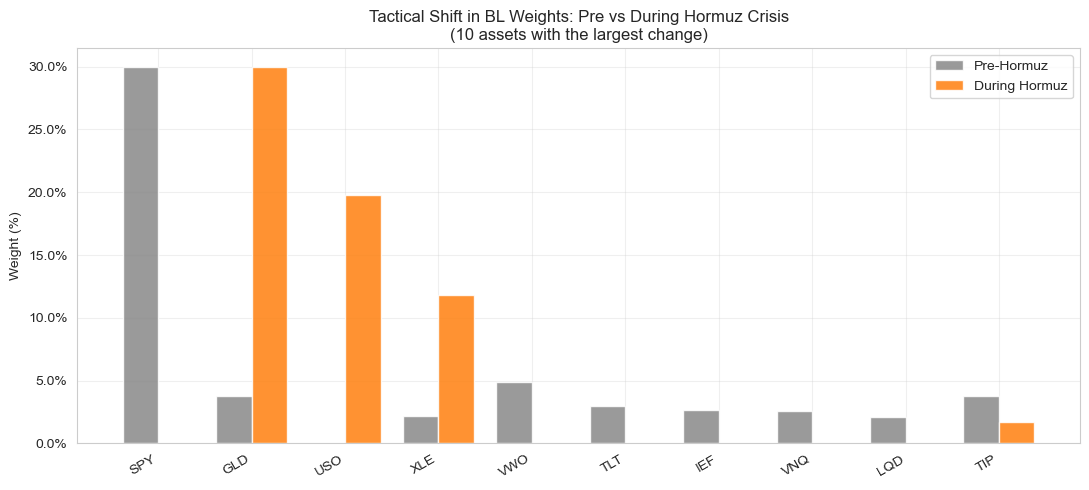

Weight changes (percentage points):


,Pre-Hormuz (6m average),During Hormuz,Shift (pp)
SPY,30.00,0.00,-30.00
GLD,3.79,30.00,26.21
USO,0.00,19.79,19.79
XLE,2.19,11.82,9.62
VWO,4.86,0.00,-4.86
TLT,2.95,0.00,-2.95
IEF,2.65,0.00,-2.65
VNQ,2.54,0.00,-2.54
LQD,2.10,0.00,-2.10
TIP,3.78,1.70,-2.07


In [52]:
if view_flags.any():
    pre_h    = bl_w_df[bl_w_df.index < HORMUZ_START].tail(6).mean()
    dur_h    = bl_w_df[view_flags.values].mean()
    delta_w  = (dur_h - pre_h).abs().nlargest(10).index

    df_shift = pd.DataFrame({
        'Pre-Hormuz (6m average)': pre_h[delta_w] * 100,
        'During Hormuz':         dur_h[delta_w] * 100,
    })
    df_shift['Shift (pp)'] = df_shift['During Hormuz'] - df_shift['Pre-Hormuz (6m average)']

    fig, ax = plt.subplots(figsize=(11, 5))
    x = np.arange(len(delta_w)); w = 0.38
    ax.bar(x - w/2, df_shift['Pre-Hormuz (6m average)'], w,
           label='Pre-Hormuz', color='#888', alpha=0.85)
    ax.bar(x + w/2, df_shift['During Hormuz'], w,
           label='During Hormuz', color='#ff7f0e', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(delta_w, rotation=30, ha='right')
    ax.set_ylabel('Weight (%)')
    ax.set_title('Tactical Shift in BL Weights: Pre vs During Hormuz Crisis\n(10 assets with the largest change)')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("Weight changes (percentage points):")
    display(df_shift.round(2))
else:
    print("Note: the Hormuz period (Feb-Apr 2026) is not yet in the OOS sample.")
    print("This chart will populate once the data cover that period.")


This cell compares efficient frontiers from historical Markowitz inputs, the equilibrium prior, and the Black-Litterman posterior. The purpose is to show how replacing raw historical means with a prior-plus-views posterior changes the risk-return opportunity set.


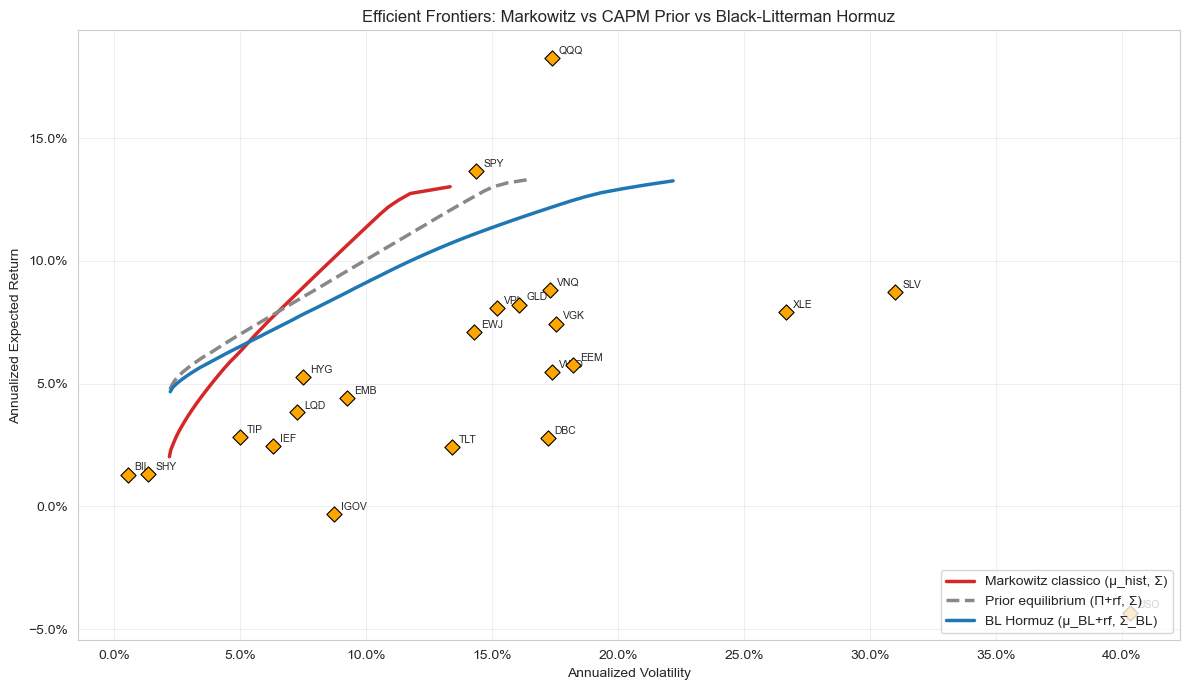

In [53]:
def build_frontier(mu, S, npts=60, w_max=0.30):
    """Long-only efficient frontier matching the assignment style."""
    n_a = len(mu)
    w0  = np.ones(n_a) / n_a
    def obj(w): return w @ S @ w
    res_mvp = minimize(obj, w0, method='SLSQP',
                       bounds=[(0, w_max)] * n_a,
                       constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}])
    if not res_mvp.success:
        return np.array([]), np.array([])
    r_min = res_mvp.x @ mu
    r_max = mu.max() * 0.999
    if r_max <= r_min:
        return np.array([]), np.array([])
    vols, rets = [], []
    for tgt in np.linspace(r_min, r_max, npts):
        res = minimize(obj, w0, method='SLSQP',
                       bounds=[(0, w_max)] * n_a,
                       constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1},
                                    {'type': 'eq', 'fun': lambda w, t=tgt: w @ mu - t}])
        if res.success:
            vols.append(np.sqrt(res.x @ S @ res.x))
            rets.append(res.x @ mu)
    return np.array(vols), np.array(rets)


v_cls, r_cls = build_frontier(mu_hist,                Sigma)
v_eq,  r_eq  = build_frontier(Pi + rf_annual,         Sigma)
v_bl,  r_bl  = build_frontier(mu_BL + rf_annual,      Sigma_BL)

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(v_cls, r_cls, color='#d62728', lw=2.5, label='Markowitz classico (μ_hist, Σ)')
ax.plot(v_eq,  r_eq,  color='#888',    lw=2.5, ls='--', label='Prior equilibrium (Π+rf, Σ)')
ax.plot(v_bl,  r_bl,  color='#1f77b4', lw=2.5, label='BL Hormuz (μ_BL+rf, Σ_BL)')

for i, t in enumerate(tickers):
    ax.scatter(sigma_v[i], mu_hist[i], s=60, marker='D',
               edgecolor='black', lw=0.8, color='orange', zorder=5)
    ax.annotate(t, xy=(sigma_v[i], mu_hist[i]),
                xytext=(5, 3), textcoords='offset points', fontsize=7.5)

ax.set_xlabel('Annualized Volatility')
ax.set_ylabel('Annualized Expected Return')
ax.set_title('Efficient Frontiers: Markowitz vs CAPM Prior vs Black-Litterman Hormuz')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


This cell analyzes sensitivity to $\tau$. In Black-Litterman, smaller $\tau$ makes the prior tighter, while larger $\tau$ gives views more room to affect the posterior. A robust model should not change radically for reasonable values of $\tau$.


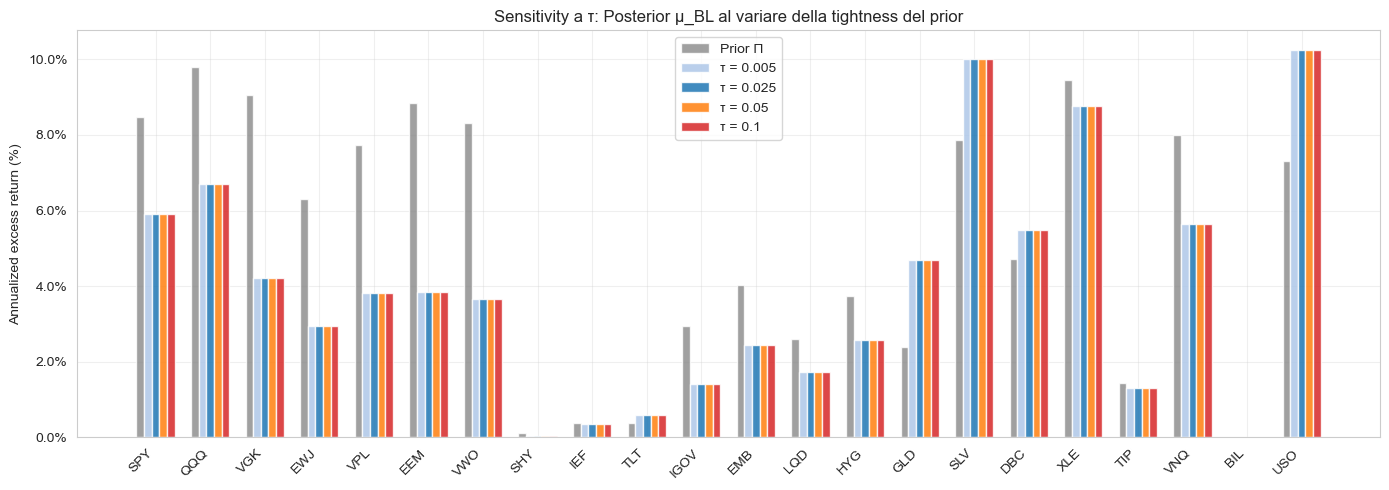

Observation: tau in {0.025, 0.05} produces very similar results, suggesting parameter robustness.


In [54]:
taus         = [0.005, 0.025, 0.05, 0.10]
colors_tau   = ['#aec7e8', '#1f77b4', '#ff7f0e', '#d62728']

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(n); w_b = 0.14

ax.bar(x - w_b, Pi*100, w_b, label='Prior Π', color='#888', alpha=0.8)
for j, tau_j in enumerate(taus):
    Om_j = np.diag(np.diag(P @ (tau_j * Sigma) @ P.T))
    mu_j, _, _ = bl_posterior(Pi, Sigma, P, Q, Om_j, tau_j)
    ax.bar(x + j*w_b, mu_j*100, w_b,
           label=f'τ = {tau_j}', color=colors_tau[j], alpha=0.85)

ax.set_xticks(x + w_b); ax.set_xticklabels(tickers, rotation=45, ha='right')
ax.set_ylabel('Annualized excess return (%)')
ax.set_title('Sensitivity a τ: Posterior μ_BL al variare della tightness del prior')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.axhline(0, color='black', lw=0.5)
ax.legend()
plt.tight_layout()
plt.show()

print("Observation: tau in {0.025, 0.05} produces very similar results, suggesting parameter robustness.")


This cell analyzes sensitivity to the confidence scaling of $\Omega$. Multiplying $\Omega$ by $c$ changes view confidence:

$$\Omega_c = c\Omega.$$

When $c<1$, views are more confident and dominate more; when $c>1$, views are less confident and the posterior moves back toward the prior.


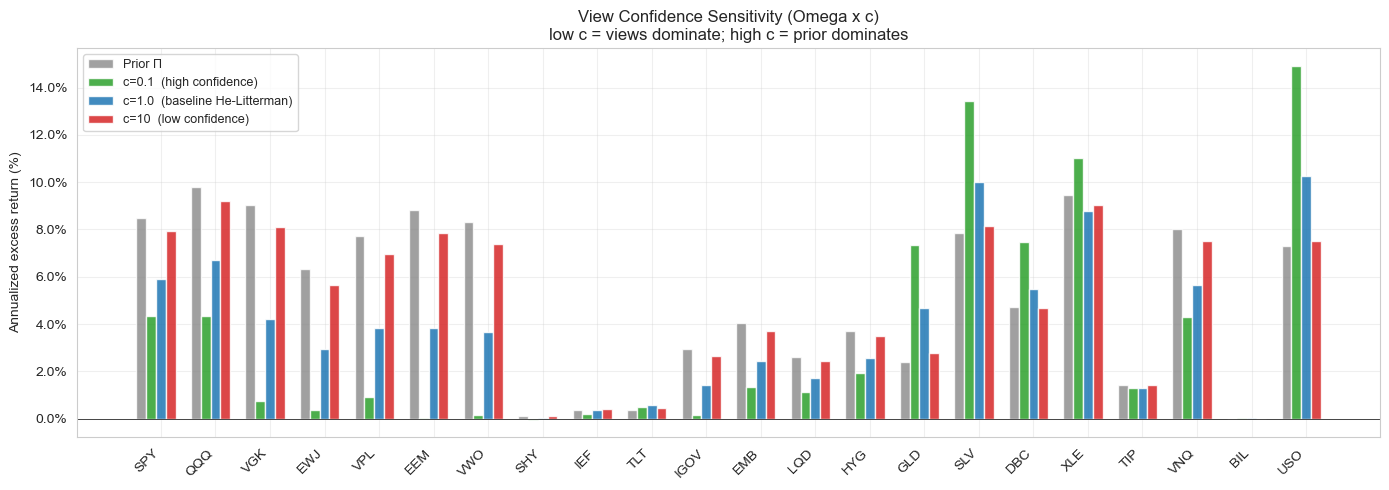

In [55]:
scales    = [0.1, 1.0, 10.0]
labs_c    = ['c=0.1  (high confidence)', 'c=1.0  (baseline He-Litterman)', 'c=10  (low confidence)']
colors_c  = ['#2ca02c', '#1f77b4', '#d62728']

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(n); w_b = 0.18

ax.bar(x - 2*w_b, Pi*100, w_b, label='Prior Π', color='#888', alpha=0.8)
for j, (c, lbl, col) in enumerate(zip(scales, labs_c, colors_c)):
    Om_c = Omega * c
    mu_c, _, _ = bl_posterior(Pi, Sigma, P, Q, Om_c, tau)
    ax.bar(x + (j-1)*w_b, mu_c*100, w_b, label=lbl, color=col, alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(tickers, rotation=45, ha='right')
ax.set_ylabel('Annualized excess return (%)')
ax.set_title('View Confidence Sensitivity (Omega x c)\n'
             'low c = views dominate; high c = prior dominates')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.axhline(0, color='black', lw=0.5)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


This cell sweeps view confidence continuously and plots the resulting optimal Black-Litterman weights. This is a practical robustness check: if small confidence changes cause large allocation jumps, the model may be too sensitive to subjective view calibration.


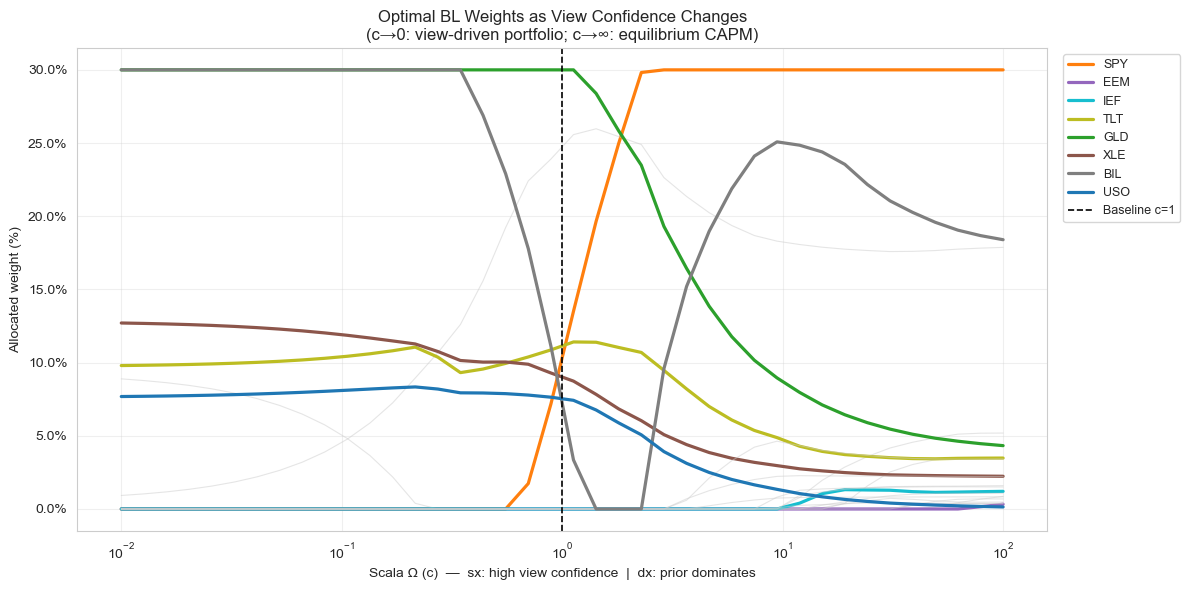

In [56]:
c_grid  = np.logspace(-2, 2, 40)
W_sweep = np.zeros((len(c_grid), n))

for k, c in enumerate(c_grid):
    Om_c = Omega * c
    mu_c, Sig_c, _ = bl_posterior(Pi, Sigma, P, Q, Om_c, tau)
    W_sweep[k] = max_sharpe_opt(mu_c, Sig_c, w_max=0.30)

highlight  = ['USO', 'SPY', 'GLD', 'EEM', 'XLE', 'BIL', 'TLT', 'IEF']
colors_h   = plt.cm.tab10(np.linspace(0, 1, len(highlight)))

fig, ax = plt.subplots(figsize=(12, 6))
for i, name in enumerate(tickers):
    if name in highlight:
        j = highlight.index(name)
        ax.plot(c_grid, W_sweep[:, i]*100, lw=2.3, color=colors_h[j], label=name)
    else:
        ax.plot(c_grid, W_sweep[:, i]*100, lw=0.8, color='#ccc', alpha=0.5)

ax.axvline(1.0, color='black', lw=1.2, ls='--', label='Baseline c=1')
ax.set_xscale('log')
ax.set_xlabel('Scala Ω (c)  —  sx: high view confidence  |  dx: prior dominates')
ax.set_ylabel('Allocated weight (%)')
ax.set_title('Optimal BL Weights as View Confidence Changes\n'
             '(c→0: view-driven portfolio; c→∞: equilibrium CAPM)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
plt.tight_layout()
plt.show()


This cell prints the final Black-Litterman summary and exports return and weight series. The summary documents the rolling window, rebalancing frequency, $\tau$, $\Omega$, asset cap, risk-free rate, active view months, and OOS period, making the extension transparent and reproducible.


In [57]:
print("=" * 58)
print("   BLACK-LITTERMAN HORMUZ 2026 PERFORMANCE SUMMARY")
print("=" * 58)
display(kpi_table)

print("\nMethodological notes:")
print(f"  Estimation window:     {WINDOW} months (rolling)")
print(f"  Rebalancing:       monthly")
print(f"  τ (prior tightness):   {tau}  [Drobetz 2001, He & Litterman 1999]")
print(f"  Ω:                     He-Litterman  diag(P τΣ Pᵀ)")
print(f"  Asset cap:         {W_MAX*100:.0f}%")
print(f"  Risk-free rate:        {rf_annual*100:.1f}%  (approximate 2026 Fed Funds rate)")
print(f"  Active Hormuz views:    {view_flags.sum()} rebalancing months")
print(f"  OOS period:           {bl_ret_s.index[0].date()} → {bl_ret_s.index[-1].date()}")

bl_ret_s.to_csv('bl_hormuz_returns.csv', header=True)
bl_w_df.to_csv('bl_hormuz_weights.csv')
print("\nSaved files: bl_hormuz_returns.csv  |  bl_hormuz_weights.csv")


   BLACK-LITTERMAN HORMUZ 2026 PERFORMANCE SUMMARY


,BL Hormuz,1/N Benchmark
Annual Return,10.57%,5.72%
Annual Volatility,10.01%,9.67%
Sharpe Ratio,0.657,0.178
Sortino Ratio,0.896,0.217
Max Drawdown,-18.97%,-17.49%
Calmar Ratio,0.557,0.327
Annual Turnover,42.46%,0.00%



Methodological notes:
  Estimation window:     60 months (rolling)
  Rebalancing:       monthly
  τ (prior tightness):   0.025  [Drobetz 2001, He & Litterman 1999]
  Ω:                     He-Litterman  diag(P τΣ Pᵀ)
  Asset cap:         30%
  Risk-free rate:        4.0%  (approximate 2026 Fed Funds rate)
  Active Hormuz views:    4 rebalancing months
  OOS period:           2015-02-28 → 2026-06-30

Saved files: bl_hormuz_returns.csv  |  bl_hormuz_weights.csv


## 7. Final Integrated Comparison

The final cell collects the OOS return series created by the previous sections and plots all available strategies in one wealth-index chart. Black-Litterman log returns are converted to simple returns before joining the main comparison table.


This cell produces the final integrated out-of-sample comparison. All available strategy return series are aligned in one table and transformed into wealth curves:

$$W_t = 100\prod_{s=1}^{t}(1+R_s).$$

This is the final empirical comparison between Markowitz, Michaud, Black-Litterman, Equal-Weight, and 60/40 benchmarks.


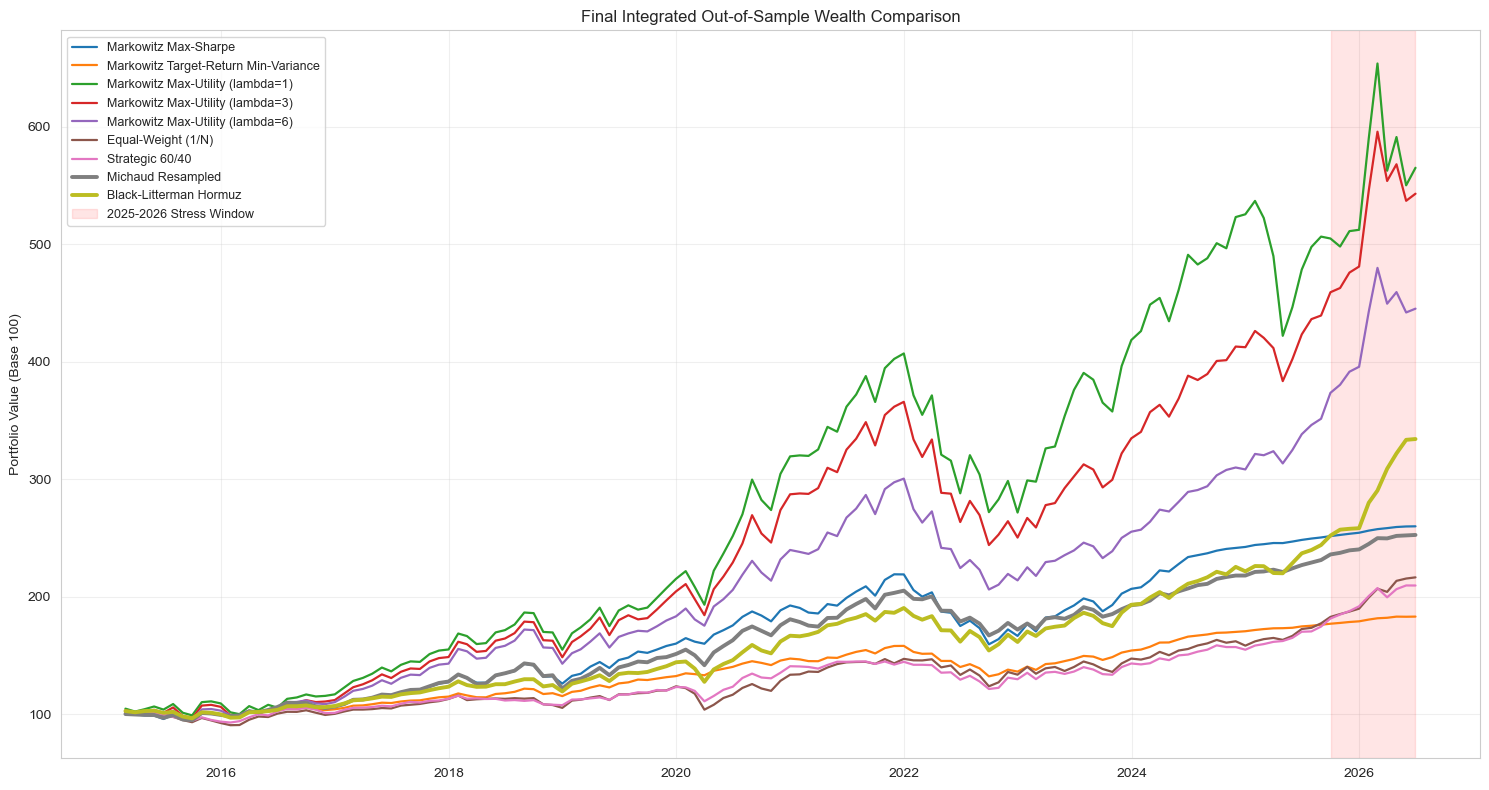


=== FINAL INTEGRATED OOS METRICS ===


,CAGR (%),Ann. Volatility (%),Sharpe Ratio,Max Drawdown (%)
Markowitz Max-Sharpe,8.73,9.83,0.68,-27.20
Markowitz Target-Return Min-Variance,5.44,5.14,0.67,-16.39
Markowitz Max-Utility (lambda=1),16.38,19.52,0.74,-33.27
Markowitz Max-Utility (lambda=3),15.98,16.68,0.84,-33.32
Markowitz Max-Utility (lambda=6),13.98,13.88,0.86,-31.41
Equal-Weight (1/N),7.00,9.48,0.53,-16.05
Strategic 60/40,6.70,8.02,0.59,-16.16
Michaud Resampled,8.46,9.41,0.69,-18.58
Black-Litterman Hormuz,11.15,10.04,0.91,-18.97


In [58]:

comparison_returns = oos_returns.copy()
if 'bl_ret_s' in globals():
    bl_simple_returns = np.exp(bl_ret_s) - 1
    comparison_returns = comparison_returns.join(bl_simple_returns.rename('Black-Litterman Hormuz'), how='outer')

comparison_returns = comparison_returns.dropna(how='all')
comparison_wealth = (1 + comparison_returns.fillna(0)).cumprod() * 100

plt.figure(figsize=(15, 8))
for col in comparison_wealth.columns:
    linewidth = 2.8 if col in ['Michaud Resampled', 'Black-Litterman Hormuz'] else 1.6
    plt.plot(comparison_wealth.index, comparison_wealth[col], label=col, linewidth=linewidth)
plt.axvspan('2025-10-01', '2026-06-30', color='red', alpha=0.10, label='2025-2026 Stress Window')
plt.title('Final Integrated Out-of-Sample Wealth Comparison')
plt.ylabel('Portfolio Value (Base 100)')
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

final_metrics = calculate_performance_metrics(comparison_returns.dropna(axis=1, how='all').fillna(0), rf_rate=0.02)
print("\n=== FINAL INTEGRATED OOS METRICS ===")
display(final_metrics)


### 7.1 Risk-Adjusted Interpretation of the Final Results

The final wealth curve should not be interpreted only through terminal wealth. The Max-Utility portfolios, especially low-risk-aversion specifications, earn high CAGR because they accept substantially higher volatility and deeper drawdowns. Black-Litterman has a lower CAGR than the most aggressive Max-Utility models, but its Sharpe ratio is the highest in the final table:

$$SR=\frac{R_p-r_f}{\sigma_p}.$$

Therefore, the key question is not whether Black-Litterman maximizes raw terminal value, but whether it delivers a better return per unit of risk and a more controlled drawdown profile. The following diagnostics visualize this tradeoff directly.


In [59]:
metrics_numeric = final_metrics.copy()
for col in metrics_numeric.columns:
    metrics_numeric[col] = pd.to_numeric(metrics_numeric[col], errors='coerce')

ordered_strategies = metrics_numeric.sort_values('Sharpe Ratio', ascending=False).index
metrics_numeric.loc[ordered_strategies]


,CAGR (%),Ann. Volatility (%),Sharpe Ratio,Max Drawdown (%)
Black-Litterman Hormuz,11.15,10.04,0.91,-18.97
Markowitz Max-Utility (lambda=6),13.98,13.88,0.86,-31.41
Markowitz Max-Utility (lambda=3),15.98,16.68,0.84,-33.32
Markowitz Max-Utility (lambda=1),16.38,19.52,0.74,-33.27
Michaud Resampled,8.46,9.41,0.69,-18.58
Markowitz Max-Sharpe,8.73,9.83,0.68,-27.20
Markowitz Target-Return Min-Variance,5.44,5.14,0.67,-16.39
Strategic 60/40,6.70,8.02,0.59,-16.16
Equal-Weight (1/N),7.00,9.48,0.53,-16.05


This risk-return map places each strategy in the plane $$(\sigma_{ann}, CAGR).$$ The bubble size is proportional to the absolute maximum drawdown, so a large bubble signals a deeper capital loss. A strategy located higher and to the left is more attractive, while a large bubble warns that the return was achieved with severe downside risk.


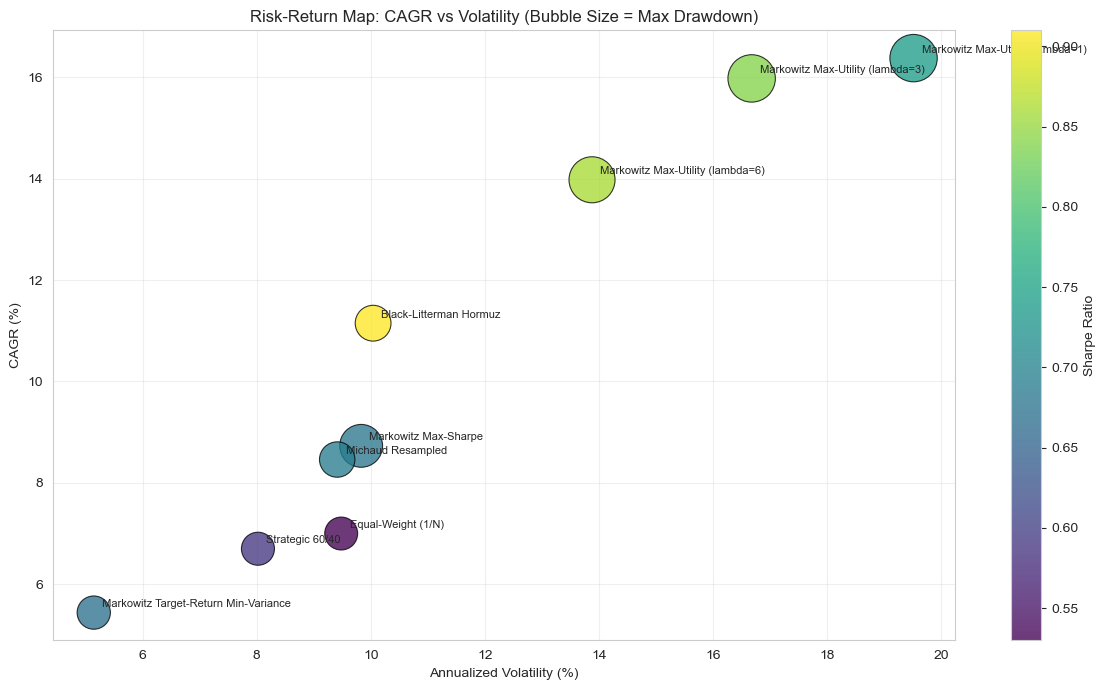

In [60]:
plot_df = metrics_numeric.dropna(subset=['CAGR (%)', 'Ann. Volatility (%)', 'Sharpe Ratio', 'Max Drawdown (%)']).copy()
plot_df['Drawdown Size'] = plot_df['Max Drawdown (%)'].abs()

fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(
    plot_df['Ann. Volatility (%)'],
    plot_df['CAGR (%)'],
    s=plot_df['Drawdown Size'] * 35,
    c=plot_df['Sharpe Ratio'],
    cmap='viridis',
    alpha=0.78,
    edgecolor='black',
    linewidth=0.8,
)

for strategy, row in plot_df.iterrows():
    ax.annotate(
        strategy,
        (row['Ann. Volatility (%)'], row['CAGR (%)']),
        xytext=(6, 4),
        textcoords='offset points',
        fontsize=8,
    )

ax.set_xlabel('Annualized Volatility (%)')
ax.set_ylabel('CAGR (%)')
ax.set_title('Risk-Return Map: CAGR vs Volatility (Bubble Size = Max Drawdown)')
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Sharpe Ratio')
plt.tight_layout()
plt.show()


The next chart compares Sharpe ratio and maximum drawdown side by side. This is the central diagnostic for the Black-Litterman result: a strategy can have lower CAGR than an aggressive Max-Utility portfolio but still be preferable if it produces a higher Sharpe ratio and avoids very large drawdowns.



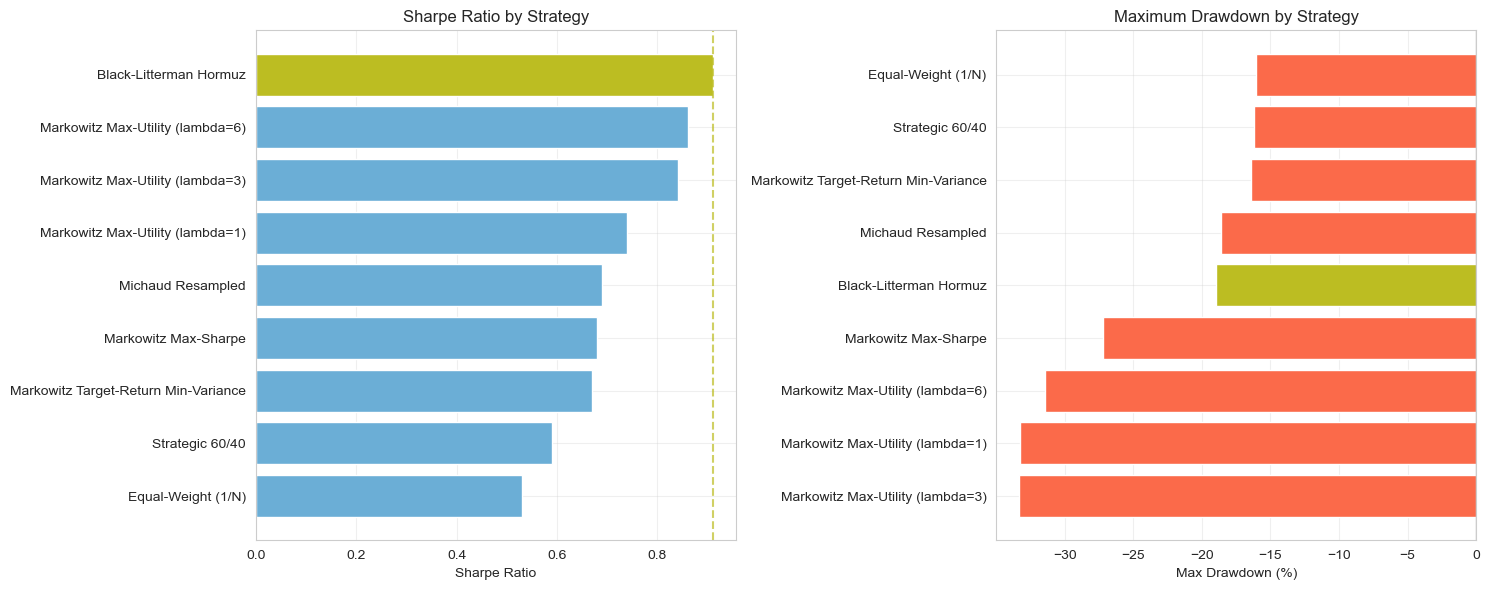

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sharpe_sorted = metrics_numeric['Sharpe Ratio'].sort_values(ascending=True)
colors_sharpe = ['#bcbd22' if idx == 'Black-Litterman Hormuz' else '#6baed6' for idx in sharpe_sorted.index]
axes[0].barh(sharpe_sorted.index, sharpe_sorted.values, color=colors_sharpe)
axes[0].set_title('Sharpe Ratio by Strategy')
axes[0].set_xlabel('Sharpe Ratio')
axes[0].axvline(sharpe_sorted.max(), color='#bcbd22', linestyle='--', alpha=0.7)

mdd_sorted = metrics_numeric['Max Drawdown (%)'].sort_values(ascending=True)
colors_mdd = ['#bcbd22' if idx == 'Black-Litterman Hormuz' else '#fb6a4a' for idx in mdd_sorted.index]
axes[1].barh(mdd_sorted.index, mdd_sorted.values, color=colors_mdd)
axes[1].set_title('Maximum Drawdown by Strategy')
axes[1].set_xlabel('Max Drawdown (%)')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()


The drawdown paths show when losses occurred and how persistent they were. This complements the final maximum drawdown number by showing whether a strategy suffered one isolated loss or repeated periods of capital impairment. In this project, the Black-Litterman curve should be compared especially with the Max-Utility portfolios, whose higher CAGR comes with much deeper drawdowns.



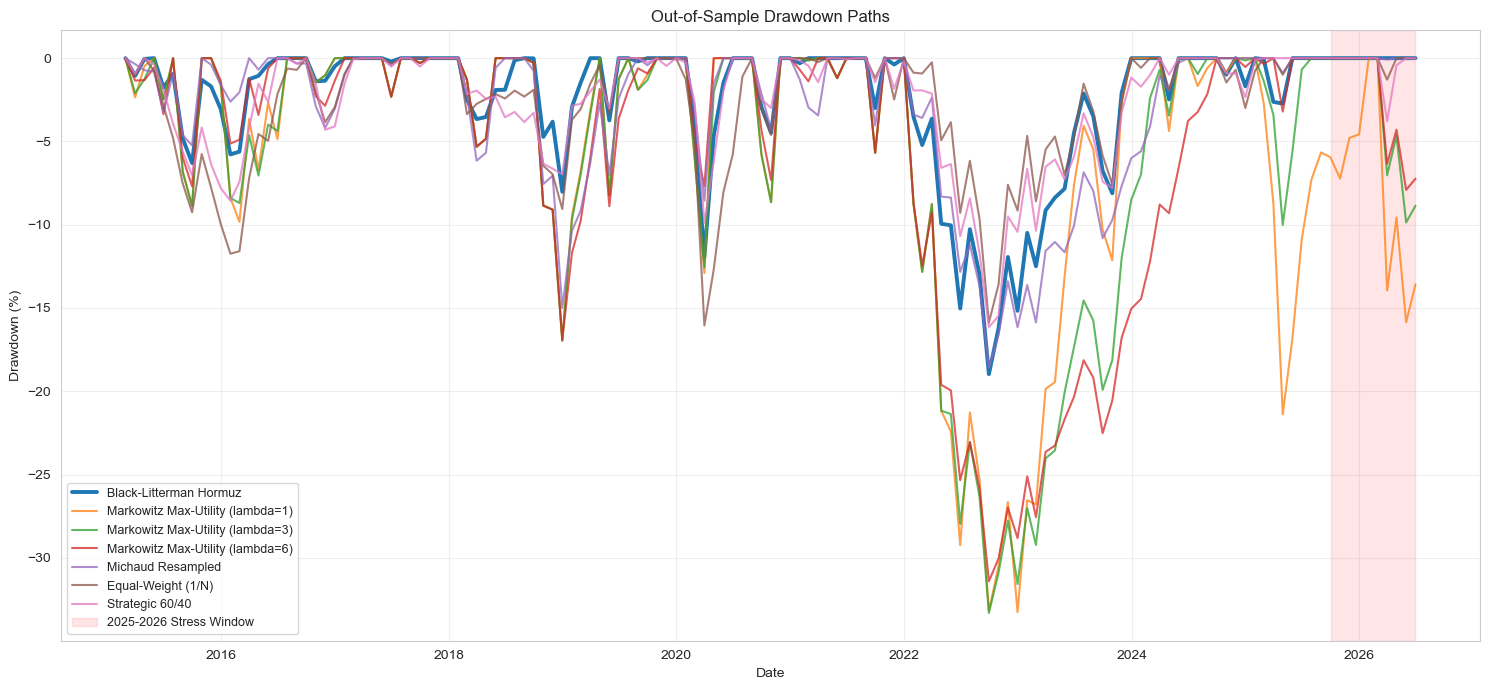

In [62]:
comparison_returns_aligned = comparison_returns.dropna(axis=1, how='all').fillna(0)
comparison_drawdowns = (1 + comparison_returns_aligned).cumprod()
comparison_drawdowns = comparison_drawdowns / comparison_drawdowns.cummax() - 1

highlight = ['Black-Litterman Hormuz', 'Markowitz Max-Utility (lambda=1)', 'Markowitz Max-Utility (lambda=3)',
             'Markowitz Max-Utility (lambda=6)', 'Michaud Resampled', 'Equal-Weight (1/N)', 'Strategic 60/40']
plot_cols = [col for col in highlight if col in comparison_drawdowns.columns]

fig, ax = plt.subplots(figsize=(15, 7))
for col in plot_cols:
    lw = 2.8 if col == 'Black-Litterman Hormuz' else 1.5
    alpha = 1.0 if col == 'Black-Litterman Hormuz' else 0.75
    ax.plot(comparison_drawdowns.index, comparison_drawdowns[col] * 100, label=col, linewidth=lw, alpha=alpha)

ax.axvspan('2025-10-01', '2026-06-30', color='red', alpha=0.10, label='2025-2026 Stress Window')
ax.set_title('Out-of-Sample Drawdown Paths')
ax.set_ylabel('Drawdown (%)')
ax.set_xlabel('Date')
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


This final diagnostic separates reward from risk. The left panel ranks strategies by CAGR, while the right panel ranks them by Sharpe ratio. A strategy that ranks lower by CAGR but higher by Sharpe is not underperforming in a risk-adjusted sense; it is delivering a more efficient risk-return tradeoff.



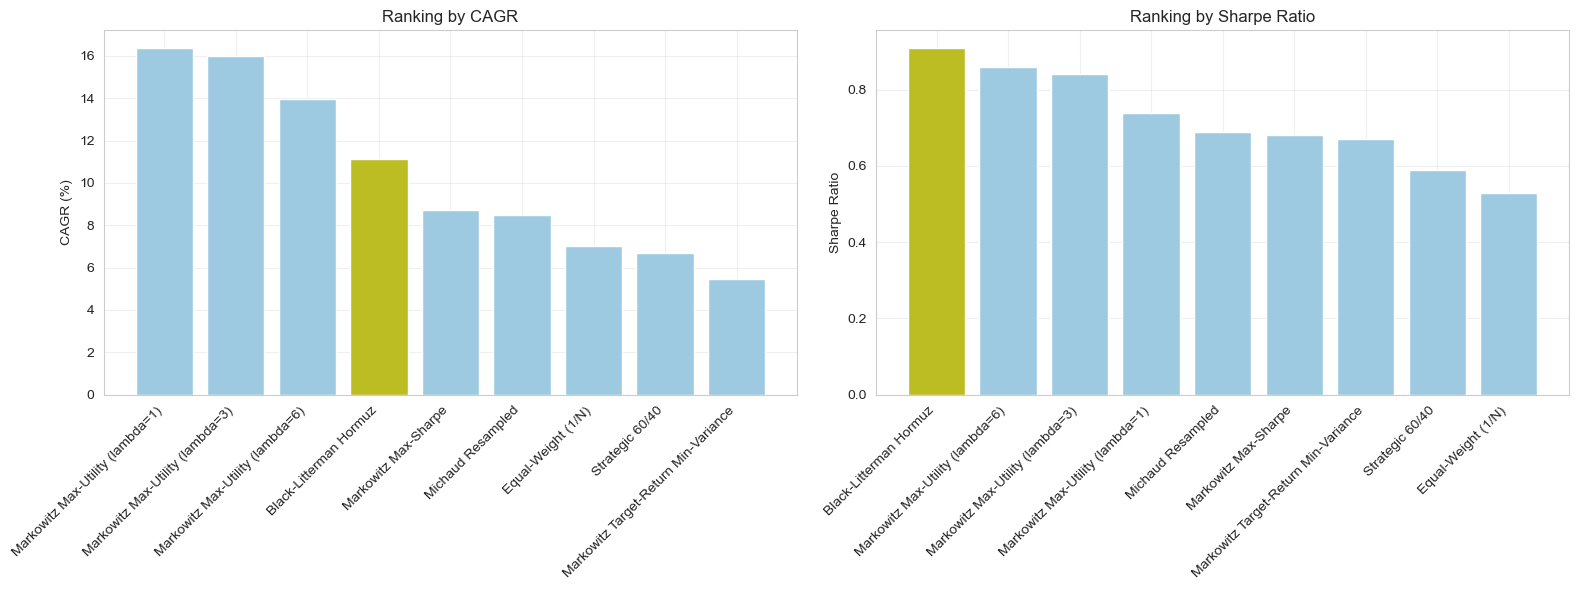

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cagr_sorted = metrics_numeric['CAGR (%)'].sort_values(ascending=False)
colors_cagr = ['#bcbd22' if idx == 'Black-Litterman Hormuz' else '#9ecae1' for idx in cagr_sorted.index]
axes[0].bar(range(len(cagr_sorted)), cagr_sorted.values, color=colors_cagr)
axes[0].set_xticks(range(len(cagr_sorted)))
axes[0].set_xticklabels(cagr_sorted.index, rotation=45, ha='right')
axes[0].set_title('Ranking by CAGR')
axes[0].set_ylabel('CAGR (%)')

sharpe_ranked = metrics_numeric['Sharpe Ratio'].sort_values(ascending=False)
colors_rank_sharpe = ['#bcbd22' if idx == 'Black-Litterman Hormuz' else '#9ecae1' for idx in sharpe_ranked.index]
axes[1].bar(range(len(sharpe_ranked)), sharpe_ranked.values, color=colors_rank_sharpe)
axes[1].set_xticks(range(len(sharpe_ranked)))
axes[1].set_xticklabels(sharpe_ranked.index, rotation=45, ha='right')
axes[1].set_title('Ranking by Sharpe Ratio')
axes[1].set_ylabel('Sharpe Ratio')

plt.tight_layout()
plt.show()


Interpretation. Black-Litterman does not have to outperform the most aggressive Markowitz Max-Utility portfolio in terminal wealth. In the reported metrics, the Max-Utility portfolios produce higher CAGR but also much larger drawdowns, around 31--33%. Black-Litterman has a lower CAGR than Max-Utility but the highest Sharpe ratio and a drawdown close to Michaud and the naive benchmarks. This supports the interpretation that Black-Litterman delivers the best risk-adjusted tradeoff rather than the highest raw return.



## 8. Comprehensive Performance Evaluation: Equity Lines, Underwater Plots & KPI Matrix

This section delivers the final quantitative verdict on all strategies. 
Comparative compounding performance is visualized using **Cumulative Wealth curves (Equity Line)**, 
while downside patterns are examined via **Underwater Plots** to inspect drawdown depth and recovery 
duration during major shock periods (including the 2025–2026 Hormuz stress window). 
Finally, a **comprehensive KPI matrix** contrasts the realized annualized Sharpe and Sortino ratios, 
Maximum Drawdown, the Calmar index, and the annualized portfolio Turnover, testing whether robust 
statistical smoothing and Bayesian tactical overlays deliver real alpha against a naive $1/N$ benchmark.

All series are expressed as **simple returns** and converted to a base-100 wealth index:
$$W_t = 100 \prod_{s=1}^{t}(1 + R_s)$$

The KPI matrix uses **monthly** log-return series throughout, annualized by $\\times 12$ 
(returns) and $\\times \\sqrt{12}$ (volatility), consistent with the rest of the notebook.

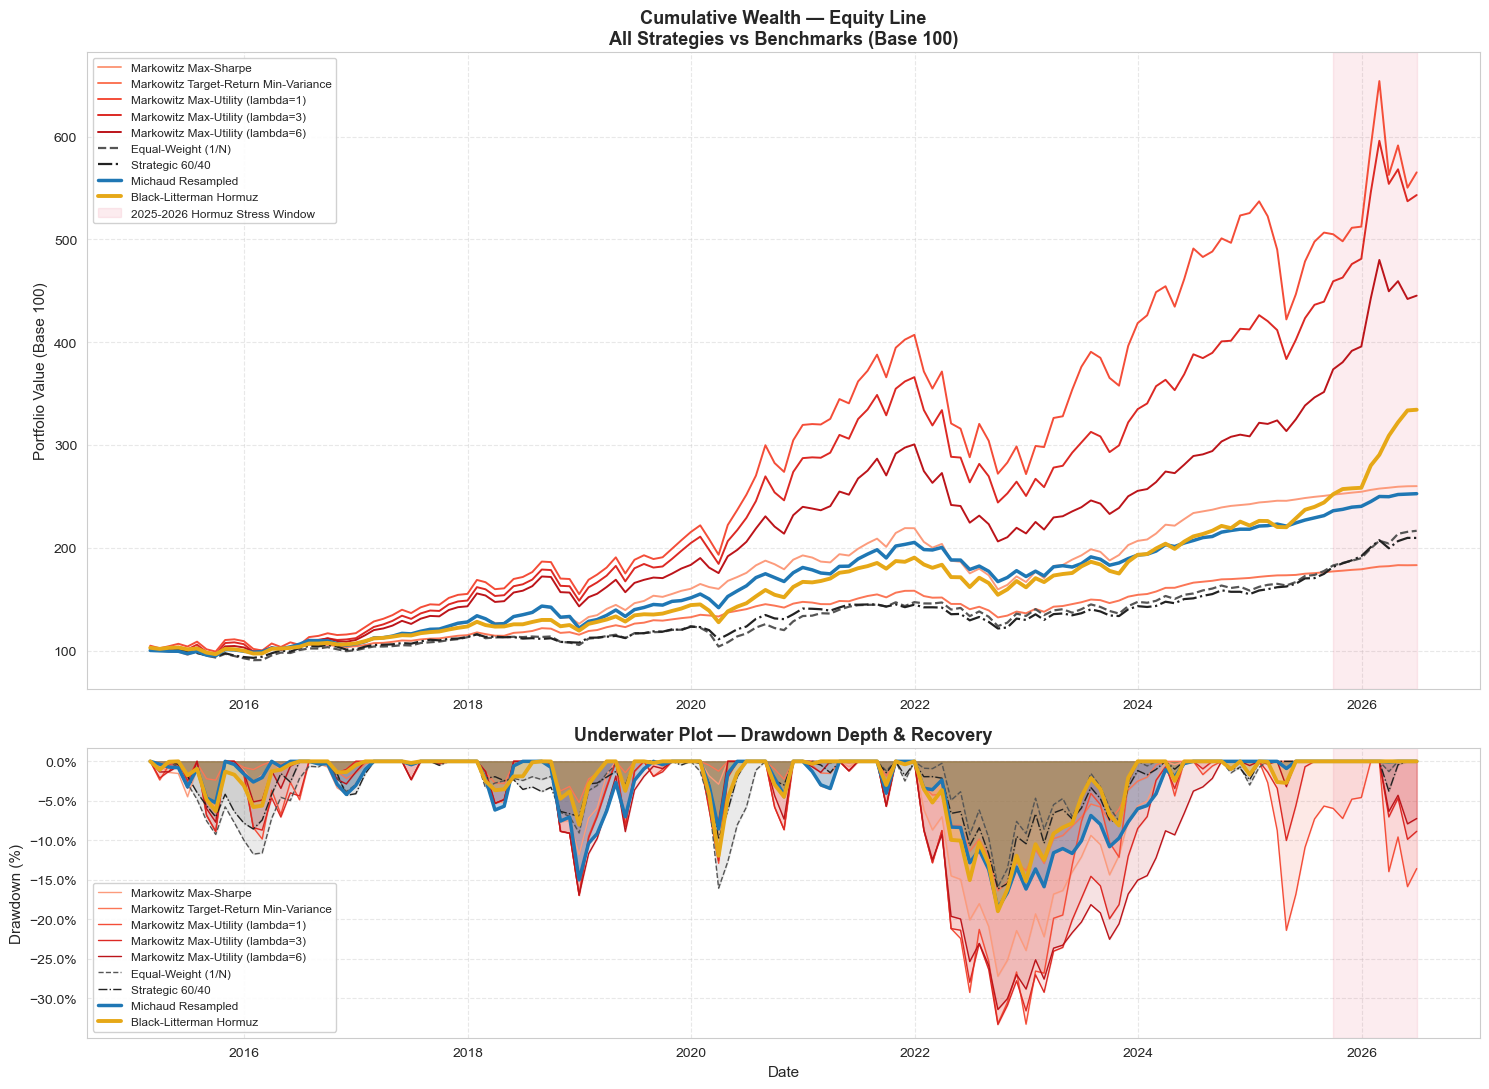


          COMPREHENSIVE KPI MATRIX — ALL STRATEGIES
  Risk-free rate: 2.0%  |  Annualization: ×12 / ×√12
  Sortino target return: 0.0%  |  Frequency: monthly


,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Ann. Turnover
Markowitz Max-Sharpe,0.699,1.112,-27.20%,0.326,209.9%
Markowitz Target-Return Min-Variance,0.670,1.059,-16.39%,0.332,172.8%
Markowitz Max-Utility (lambda=1),0.777,1.257,-33.27%,0.516,n/a
Markowitz Max-Utility (lambda=3),0.857,1.400,-33.32%,0.489,n/a
Markowitz Max-Utility (lambda=6),0.873,1.418,-31.41%,0.449,n/a
Equal-Weight (1/N),0.552,0.853,-16.05%,0.451,0.0%
Strategic 60/40,0.601,1.012,-16.16%,0.422,0.0%
Michaud Resampled,0.700,1.100,-18.58%,0.462,524.8%
Black-Litterman Hormuz,0.908,1.546,-18.97%,0.586,42.5%


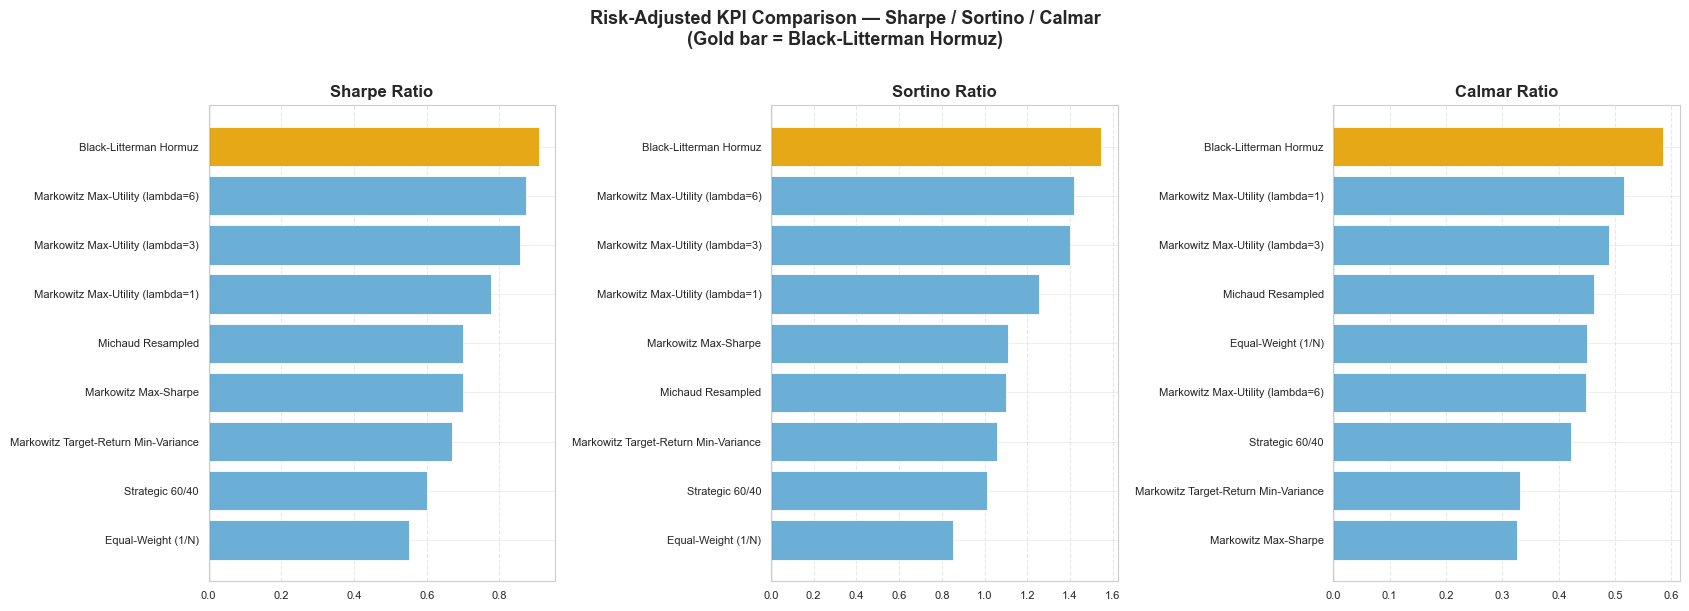

In [64]:
import matplotlib.ticker as mtick

# =========================================================
# STEP 1 — Assemble unified return table
# All series expressed as simple monthly returns, base-100
# =========================================================

# Start from comparison_returns already built in Section 7
strategy_returns = comparison_returns.dropna(axis=1, how='all').copy()

# Fill any residual NaN with 0 (days before a strategy is live)
strategy_returns = strategy_returns.fillna(0)

# =========================================================
# STEP 2 — Cumulative Wealth (Equity Line)
# =========================================================
cum_wealth = (1 + strategy_returns).cumprod() * 100

# =========================================================
# STEP 3 — Drawdowns (Underwater series)
# =========================================================
running_max = cum_wealth.cummax()
drawdowns   = (cum_wealth / running_max) - 1

# =========================================================
# PLOT A — Equity Line + Underwater Plot
# =========================================================

# Style map: BL and Michaud are highlighted
highlight_cols = ['Black-Litterman Hormuz', 'Michaud Resampled']

def line_style(col):
    if col == 'Black-Litterman Hormuz': return '#e6a817', 2.8, '-'
    if col == 'Michaud Resampled':      return '#1f77b4', 2.5, '-'
    if col == 'Equal-Weight (1/N)':     return '#555555', 1.6, '--'
    if col == 'Strategic 60/40':        return '#222222', 1.6, '-.'
    return None, 1.4, '-'   # Markowitz variants

cmap = plt.cm.Reds(np.linspace(0.35, 0.80,
       max(1, sum(1 for c in strategy_returns.columns
                  if c not in highlight_cols
                  and c not in ['Equal-Weight (1/N)', 'Strategic 60/40']))))
markowitz_cols = [c for c in strategy_returns.columns
                  if c not in highlight_cols + ['Equal-Weight (1/N)', 'Strategic 60/40']]
color_map = {col: cmap[i] for i, col in enumerate(markowitz_cols)}

fig, axes = plt.subplots(2, 1, figsize=(15, 11),
                          gridspec_kw={'height_ratios': [2.2, 1]})

# --- Subplot 1: Equity Line ---
for col in cum_wealth.columns:
    fixed_color, lw, ls = line_style(col)
    color = fixed_color if fixed_color else color_map.get(col, 'grey')
    axes[0].plot(cum_wealth.index, cum_wealth[col],
                 label=col, linewidth=lw, linestyle=ls, color=color)

axes[0].axvspan('2025-10-01', '2026-06-30',
                color='crimson', alpha=0.08, label='2025-2026 Hormuz Stress Window')
axes[0].set_title('Cumulative Wealth — Equity Line\n'
                  'All Strategies vs Benchmarks (Base 100)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Portfolio Value (Base 100)', fontsize=11)
axes[0].legend(loc='upper left', fontsize=8.5, framealpha=0.9)
axes[0].grid(True, linestyle='--', alpha=0.45)
axes[0].yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f'))

# --- Subplot 2: Underwater Plot ---
for col in drawdowns.columns:
    fixed_color, lw, ls = line_style(col)
    color = fixed_color if fixed_color else color_map.get(col, 'grey')
    alpha_fill = 0.30 if col in highlight_cols else 0.12
    axes[1].fill_between(drawdowns.index, drawdowns[col], 0,
                         alpha=alpha_fill, color=color)
    axes[1].plot(drawdowns.index, drawdowns[col],
                 linewidth=lw if col in highlight_cols else 1.0,
                 linestyle=ls, color=color, label=col)

axes[1].axvspan('2025-10-01', '2026-06-30',
                color='crimson', alpha=0.08)
axes[1].set_title('Underwater Plot — Drawdown Depth & Recovery',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Drawdown (%)', fontsize=11)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].legend(loc='lower left', fontsize=8.5, framealpha=0.9)
axes[1].grid(True, linestyle='--', alpha=0.45)

plt.tight_layout()
plt.show()

# =========================================================
# STEP 4 — Comprehensive KPI Matrix
# Annualized Sharpe, Sortino, Max Drawdown, Calmar, Turnover
# Uses MONTHLY simple returns throughout (×12 / ×√12)
# =========================================================

MONTHS_ANN = 12
RF_ANNUAL  = 0.02   # consistent with calculate_performance_metrics (rf_rate=0.02)
rf_monthly = RF_ANNUAL / MONTHS_ANN
TARGET_RET = 0.0    # Sortino target: zero excess return

kpi_matrix = pd.DataFrame(index=strategy_returns.columns)

# --- Annualized return and vol ---
ann_ret = strategy_returns.mean() * MONTHS_ANN
ann_vol = strategy_returns.std()  * np.sqrt(MONTHS_ANN)

# 1. Sharpe Ratio (rf annualizzato)
kpi_matrix['Sharpe Ratio'] = ((ann_ret - RF_ANNUAL) / ann_vol).round(3)

# 2. Sortino Ratio — downside variance rigorosa (target = 0)
downside_diff = np.minimum(strategy_returns - TARGET_RET, 0)
downside_vol  = np.sqrt((downside_diff ** 2).mean()) * np.sqrt(MONTHS_ANN)
kpi_matrix['Sortino Ratio'] = ((ann_ret - RF_ANNUAL) / downside_vol).round(3)

# 3. Maximum Drawdown
wealth_idx = (1 + strategy_returns).cumprod()
peak       = wealth_idx.cummax()
mdd_series = ((wealth_idx - peak) / peak).min()
kpi_matrix['Max Drawdown'] = mdd_series

# 4. Calmar Ratio
kpi_matrix['Calmar Ratio'] = (ann_ret / mdd_series.abs()).round(3)

# 5. Annualized Turnover
# Weight histories available per strategy — matched by name
def annualized_turnover(w_df: pd.DataFrame) -> float:
    """Mean monthly absolute weight change × 12 (one-way turnover, annualized)."""
    return w_df.astype(float).diff().abs().sum(axis=1).mean() * MONTHS_ANN

weight_registry = {}

# Populate registry with weight DataFrames built earlier in the notebook
if 'markowitz_weights_history' in globals():
    weight_registry['Markowitz Max-Sharpe'] = markowitz_weights_history
if 'target_mv_weights_history' in globals():
    weight_registry['Markowitz Target-Return Min-Variance'] = target_mv_weights_history
if 'michaud_historical_weights' in globals():
    weight_registry['Michaud Resampled'] = michaud_historical_weights
if 'bl_w_df' in globals():
    weight_registry['Black-Litterman Hormuz'] = bl_w_df

# Equal-weight: constant weights → turnover = 0 by construction
n_assets = strategy_returns.shape[1]
ew_const  = pd.DataFrame(
    np.ones((len(strategy_returns), len(strategy_returns.columns))) / len(strategy_returns.columns),
    index=strategy_returns.index, columns=strategy_returns.columns
)
weight_registry['Equal-Weight (1/N)']  = ew_const
weight_registry['Strategic 60/40']     = ew_const  # static → ~0 turnover

turnover_col = []
for strat in kpi_matrix.index:
    # Try exact match first, then partial match
    matched = weight_registry.get(strat)
    if matched is None:
        for key in weight_registry:
            if key.lower() in strat.lower() or strat.lower() in key.lower():
                matched = weight_registry[key]
                break
    if matched is not None:
        to = annualized_turnover(matched)
        turnover_col.append(f"{to*100:.1f}%")
    else:
        turnover_col.append('n/a')

kpi_matrix['Ann. Turnover'] = turnover_col

# --- Format for display ---
kpi_matrix['Max Drawdown'] = kpi_matrix['Max Drawdown'].apply(lambda x: f"{x*100:.2f}%")

print()
print('=' * 65)
print('          COMPREHENSIVE KPI MATRIX — ALL STRATEGIES')
print('=' * 65)
print(f'  Risk-free rate: {RF_ANNUAL*100:.1f}%  |  Annualization: ×12 / ×√12')
print(f'  Sortino target return: {TARGET_RET*100:.1f}%  |  Frequency: monthly')
print('=' * 65)
display(kpi_matrix)

# =========================================================
# PLOT B — KPI Bar Chart: Sharpe vs Sortino side-by-side
# =========================================================
kpi_num = kpi_matrix[['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio']].copy()
for col in kpi_num.columns:
    kpi_num[col] = pd.to_numeric(kpi_num[col], errors='coerce')
kpi_num = kpi_num.sort_values('Sharpe Ratio', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(17, 6))

def bar_colors(index, highlight='Black-Litterman Hormuz',
               h_color='#e6a817', default='#6baed6'):
    return [h_color if s == highlight else default for s in index]

for ax, metric in zip(axes, ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio']):
    vals = kpi_num[metric].sort_values(ascending=True)
    cols = bar_colors(vals.index)
    ax.barh(vals.index, vals.values, color=cols, edgecolor='white', linewidth=0.6)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.axvline(0, color='black', lw=0.8)
    ax.grid(True, axis='x', linestyle='--', alpha=0.45)
    ax.tick_params(labelsize=8)

fig.suptitle('Risk-Adjusted KPI Comparison — Sharpe / Sortino / Calmar\n'
             '(Gold bar = Black-Litterman Hormuz)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Dynamic Asset Allocation — Weight Composition Over Time

This section visualizes how each model allocates capital across assets at every rebalancing date. 
Each panel is a **stacked area chart** where the vertical slice at any date $t$ shows the full 
portfolio composition. Reading across time reveals how aggressively each optimizer rotates between 
asset classes in response to changing return and covariance estimates.

Assets are grouped into **six macro classes** (Equity DM, Equity EM, Government Bonds, 
Credit & Inflation, Real Assets, REIT & Cash) using a consistent color palette across all panels, 
so that cross-model comparisons are immediate. The red band marks the 2025–2026 Hormuz stress window.

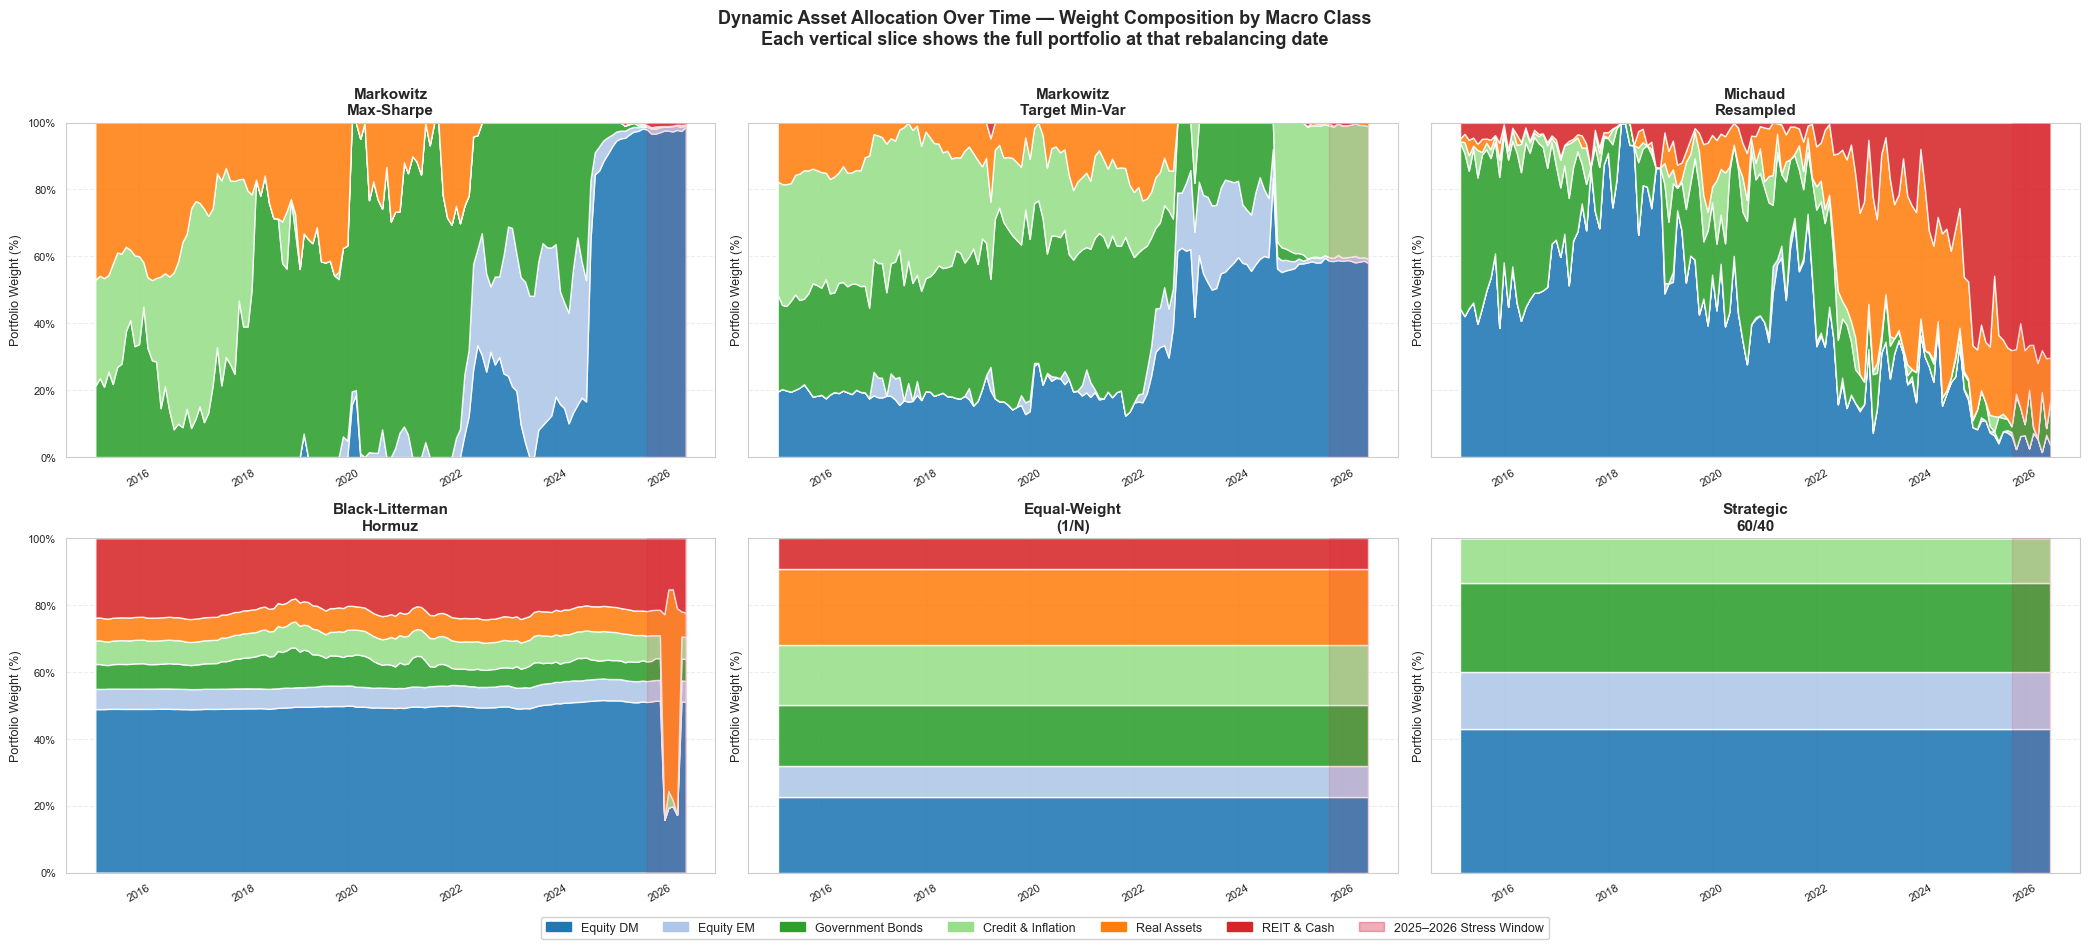

In [65]:
# =========================================================
# Asset Allocation Over Time — one panel per model
# Variables used (all defined earlier in the notebook):
#   markowitz_weights_history  (Max-Sharpe)
#   target_mv_weights_history  (Target-Return Min-Var)
#   michaud_historical_weights (Michaud Resampled)
#   bl_w_df                    (Black-Litterman Hormuz)
#   w_ew, w_6040, all_tickers  (static benchmarks)
# =========================================================

import matplotlib.patches as mpatches

# ── Macro-class grouping (consistent across panels) ──────────
MACRO = {
    'Equity DM':         ['SPY', 'QQQ', 'VGK', 'EWJ', 'VPL'],
    'Equity EM':         ['EEM', 'VWO'],
    'Government Bonds':  ['SHY', 'IEF', 'TLT', 'IGOV'],
    'Credit & Inflation':['LQD', 'HYG', 'EMB', 'TIP'],
    'Real Assets':       ['GLD', 'SLV', 'DBC', 'XLE', 'USO'],
    'REIT & Cash':       ['VNQ', 'BIL'],
}
MACRO_COLORS = {
    'Equity DM':          '#1f77b4',
    'Equity EM':          '#aec7e8',
    'Government Bonds':   '#2ca02c',
    'Credit & Inflation': '#98df8a',
    'Real Assets':        '#ff7f0e',
    'REIT & Cash':        '#d62728',
}

def to_macro(w_df: pd.DataFrame, universe: list) -> pd.DataFrame:
    """Aggregate per-asset weights into macro classes. w_df columns = universe."""
    w = w_df.copy().astype(float)
    # Align columns to universe (fill missing with 0)
    w = w.reindex(columns=universe, fill_value=0.0)
    out = pd.DataFrame(index=w.index)
    for cls, tks in MACRO.items():
        cols = [t for t in tks if t in w.columns]
        out[cls] = w[cols].sum(axis=1) if cols else 0.0
    return out

def static_to_macro(w_arr: np.ndarray, universe: list,
                     index: pd.DatetimeIndex) -> pd.DataFrame:
    """Convert a static weight array to a time-indexed macro DataFrame."""
    w_df = pd.DataFrame(
        np.tile(w_arr, (len(index), 1)),
        index=index, columns=universe
    )
    return to_macro(w_df, universe)

# ── Build macro DataFrames ────────────────────────────────────
oos_idx = markowitz_weights_history.index   # common OOS index

models = {}

if 'markowitz_weights_history' in dir():
    models['Markowitz\nMax-Sharpe'] = to_macro(
        markowitz_weights_history, list(all_tickers))

if 'target_mv_weights_history' in dir():
    models['Markowitz\nTarget Min-Var'] = to_macro(
        target_mv_weights_history, list(all_tickers))

if 'michaud_historical_weights' in dir():
    models['Michaud\nResampled'] = to_macro(
        michaud_historical_weights, list(all_tickers))

if 'bl_w_df' in dir():
    # bl_w_df may use a different (but overlapping) index — align
    bl_macro = to_macro(bl_w_df, list(bl_w_df.columns))
    models['Black-Litterman\nHormuz'] = bl_macro

# Static benchmarks on the OOS index
models['Equal-Weight\n(1/N)'] = static_to_macro(w_ew,   list(all_tickers), oos_idx)
models['Strategic\n60/40']    = static_to_macro(w_6040, list(all_tickers), oos_idx)

n_models = len(models)

# ── Layout: 3 columns, 2 rows (or 2+2+2) ─────────────────────
ncols = 3
nrows = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(7 * ncols, 4.5 * nrows),
                          sharey=True)
axes_flat = axes.flatten() if n_models > 1 else [axes]

STRESS_START = '2025-10-01'
STRESS_END   = '2026-06-30'

for ax, (title, macro_df) in zip(axes_flat, models.items()):
    # Ensure columns in consistent MACRO order
    plot_df = macro_df[[c for c in MACRO.keys() if c in macro_df.columns]]

    # Clip tiny negatives from float arithmetic
    plot_df = plot_df.clip(lower=0)
    # Renormalize rows to 1 (handles rounding errors)
    row_sum = plot_df.sum(axis=1).replace(0, 1)
    plot_df = plot_df.div(row_sum, axis=0)

    colors  = [MACRO_COLORS[c] for c in plot_df.columns]

    ax.stackplot(plot_df.index,
                 plot_df.T.values * 100,
                 colors=colors, alpha=0.88)

    # Stress window band
    ax.axvspan(STRESS_START, STRESS_END,
               color='crimson', alpha=0.12, zorder=5)

    ax.set_title(title, fontsize=11, fontweight='bold', pad=6)
    ax.set_ylim(0, 100)
    ax.set_ylabel('Portfolio Weight (%)', fontsize=9)
    ax.yaxis.set_major_formatter(
        plt.matplotlib.ticker.FormatStrFormatter('%.0f%%'))
    ax.tick_params(axis='x', labelrotation=30, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(True, axis='y', linestyle='--', alpha=0.35)

# Hide unused axes
for ax in axes_flat[n_models:]:
    ax.set_visible(False)

# ── Shared legend ─────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=MACRO_COLORS[cls], label=cls)
    for cls in MACRO.keys()
]
legend_handles.append(
    mpatches.Patch(color='crimson', alpha=0.35,
                   label='2025–2026 Stress Window'))

fig.legend(handles=legend_handles,
           loc='lower center',
           ncol=len(legend_handles),
           fontsize=9,
           framealpha=0.9,
           bbox_to_anchor=(0.5, -0.03))

fig.suptitle('Dynamic Asset Allocation Over Time — Weight Composition by Macro Class\n'
             'Each vertical slice shows the full portfolio at that rebalancing date',
             fontsize=13, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()
